In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import xgboost
from sklearn.impute import KNNImputer
import tensorflow as tf
from tensorflow.keras import layers, Model
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error



2025-01-24 08:01:00.018517: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
dataset1 = pd.read_csv('Cycle 1.csv')
dataset2 = pd.read_csv('Cycle 2.csv')
dataset3 = pd.read_csv('Cycle 3.csv')
dataset4 = pd.read_csv('Cycle 4.csv')
dataset5 = pd.read_csv('Cycle 5.csv')
dataset6 = pd.read_csv('Cycle 6.csv')

In [3]:
pd.set_option('display.max_columns', None)
datasets = [dataset1, dataset2, dataset3, dataset4, dataset5,dataset6]

In [4]:
dataset1

,"Time in Oil, days","Feed 1 Sulfur, ppm","Feed 1 specific density, g/cm3","Feed 1 Visc Index,[]","Feed 1 Cloud Point Index, []","Feed 1 to R01, BPH",Feed 1 to R02,"(Feed1+Feed2) Sulfur, ppm","(Feed 1+Feed2) specific density, g/cm3","(Feed 1 + Feed 2), Cloud Point Index","Feed 2 to R01, BPH","Feed 2 to R02, BPH","Feed 3 Sulfur, ppm",Feed 3 specific density,Feed 3 Cloud Point Index,"Feed 3 to R01, BPH","Feed 3 to R02, BPH","Distillate Sulfur, ppm","Distillate Cloud Index, []","Total Hydrogen Into the unit, KSCFH",Total Hydrogen out of Unit,Cycle,"Distillate Yield, vol%","Napthta Yield, vol%","C4 Yield, vol%","C1 Yield, vol%","C2 Yield, vol%","C3 Yield, vol%","Distillate Gravity, []","Distillate Viscocity Index, []","Distillate Cetane Index, []","R1 Temp, DEGF","R2 Temp, DEGF","H2 Consumption, SCF/BBL"
0,0.0,NaN,NaN,NaN,NaN,802.035343,0.000000,12710.0,0.88065,NaN,0.000000,0.000000,5536.699612,0.922790,0.454981,0.000000,0.000000,3,0.570393,517.961087,219.102794,1,0.966060,0.000000,0.006359,0.002787,0.003590,0.007508,0.869875,19.590032,49.744103,617.221969,611.602260,372.624093
1,1.0,NaN,NaN,NaN,NaN,916.494917,0.000000,7270.0,0.87500,2.036026,0.000000,0.000000,5536.699612,0.922790,0.428164,0.000000,0.000000,1.7,0.570393,501.564273,191.977524,1,0.946205,0.036740,0.011141,0.003121,0.005413,0.014754,0.865100,18.971711,49.777800,623.464972,626.685960,337.794973
2,2.0,1537.0,0.8712,NaN,1.609784,959.991381,37.583472,7270.0,0.87635,1.731521,0.000000,0.000000,5377.500000,0.922790,0.428164,0.000000,0.000000,1.2,0.570393,492.354818,183.467336,1,0.946609,0.047264,0.013050,0.003035,0.005527,0.015533,0.864200,18.647355,49.671066,621.028296,626.142149,312.402506
3,3.0,NaN,NaN,NaN,NaN,945.174365,89.658873,1830.0,0.87340,1.877611,0.000000,0.000000,5377.500000,0.922790,0.428164,14.826906,0.000000,1.5,0.776546,503.403877,179.551149,1,0.969100,0.037137,0.010413,0.002525,0.004590,0.012724,0.863600,18.805500,50.161617,616.489531,627.632180,308.529940
4,4.0,NaN,NaN,NaN,NaN,841.118141,162.255215,7270.0,0.83955,1.731521,0.000000,0.000000,5377.500000,0.922790,0.454981,118.915738,0.000000,2.7,0.776546,545.073059,140.727238,1,0.976521,0.031757,0.009716,0.002352,0.004322,0.011945,0.867200,18.054455,46.816681,622.706754,625.964032,360.280372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,669.0,NaN,NaN,NaN,NaN,612.906673,286.880306,2280.0,0.88330,1.731521,58.806003,27.525045,5371.000000,0.928800,0.342666,287.987501,99.999866,9.9,0.913109,540.369130,184.938565,1,0.992079,0.000000,0.005463,0.001849,0.002489,0.005079,0.887700,16.780577,35.861312,697.291607,694.258379,258.662928
661,670.0,NaN,NaN,NaN,NaN,697.921790,282.505325,2270.0,0.88110,1.596797,52.889040,21.408467,5371.000000,0.929300,0.299312,208.004938,99.999939,9.2,0.751789,536.117974,173.061566,1,0.996256,0.000000,0.005505,0.001753,0.002359,0.004815,0.884800,16.246777,35.663792,685.531965,675.357236,266.419111
662,671.0,NaN,NaN,NaN,NaN,765.922206,249.398138,2270.0,0.87790,1.357982,33.965129,11.059661,5371.000000,0.929933,0.284997,158.452069,100.001926,8,0.764067,527.854327,173.537978,1,1.000745,0.000000,0.005685,0.001672,0.002239,0.004582,0.883200,16.799202,37.774060,672.236214,668.207133,268.663296
663,672.0,1121.0,0.8722,19.542428,1.357982,817.659421,266.414712,2280.0,0.87440,1.357982,6.144817,2.002141,5371.000000,0.932200,0.165299,99.075160,87.771059,8.5,1.014504,449.416845,172.875756,1,1.011475,0.000000,0.005871,0.001537,0.002044,0.004199,0.877800,17.340767,41.037485,648.906804,635.701618,216.206229


In [5]:
# Define the column names you want to assign
column_names = ['time (days)','feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Loop through the datasets and assign column names
for dataset in datasets:
    dataset.columns = column_names
    dataset['distillate sulfur concentration (ppm)'] = dataset['distillate sulfur concentration (ppm)'].replace('<1.0', np.nan)
    dataset = dataset.replace('#NUM!', np.nan)
    dataset = dataset.replace('#DIV/0!', np.nan)
    dataset = dataset.replace('#VALUE!', np.nan)
    dataset = dataset.astype(float)

In [6]:
for dataset in datasets:
    for column in dataset.columns:
        unique_values = dataset[column].unique()
        if '<1.0' in unique_values:
            print(f"Column {column} in dataset contains '<1.0' values.")
        dataset[column] = dataset[column].replace('<1.0', np.nan)
        dataset[column] = pd.to_numeric(dataset[column], errors='coerce')

In [7]:
dataset = pd.concat(datasets[0:], axis=0, ignore_index=True)
dataset

,time (days),feed 1 sulfur concentration (ppm),feed 1 specific density (g/cm3),feed 1 viscosity index,feed 1 cloud point index,feed 1 to reactor 1 flowrate (BPH),feed 1 to reactor 2 flowrate (BPH),feed 1 and 2 sulfur concentration (ppm),feed 1 and 2 specific density (g/cm3),feed 1 and 2 cloud point index,feed 2 to reactor 1 flowrate (BPH),feed 2 to reactor 2 flowrate (BPH),feed 3 sulfur concentration (ppm),feed 3 specific density (g/cm3),feed 3 cloud point index,feed 3 to reactor 1 flowrate (BPH),feed 3 to reactor 2 flowrate (BPH),distillate sulfur concentration (ppm),distillate cloud point index,total Hydrogen in (KSCFH),total Hydrogen out (KSCFH),Cycle,distillate yield (vol%),naphtha yield (vol%),C4 yield (vol%),C1 yield (vol%),C2 yield (vol%),C3 yield (vol%),distillate gravity,distillate viscosity index,distillate cetane index,reactor 1 temperature (°F),reactor 2 temperature (°F),Hydrogen Consumption (SCF/BBL)
0,0.0,NaN,NaN,NaN,NaN,802.035343,0.000000,12710.0,0.88065,NaN,0.000000,0.0,5536.699612,0.92279,0.454981,0.000000,0.000000,3.0,0.570393,517.961087,219.102794,1.00,0.966060,0.000000,0.006359,0.002787,0.003590,0.007508,0.869875,19.590032,49.744103,617.221969,611.602260,372.624093
1,1.0,NaN,NaN,NaN,NaN,916.494917,0.000000,7270.0,0.87500,2.036026,0.000000,0.0,5536.699612,0.92279,0.428164,0.000000,0.000000,1.7,0.570393,501.564273,191.977524,1.00,0.946205,0.036740,0.011141,0.003121,0.005413,0.014754,0.865100,18.971711,49.777800,623.464972,626.685960,337.794973
2,2.0,1537.0,0.8712,NaN,1.609784,959.991381,37.583472,7270.0,0.87635,1.731521,0.000000,0.0,5377.500000,0.92279,0.428164,0.000000,0.000000,1.2,0.570393,492.354818,183.467336,1.00,0.946609,0.047264,0.013050,0.003035,0.005527,0.015533,0.864200,18.647355,49.671066,621.028296,626.142149,312.402506
3,3.0,NaN,NaN,NaN,NaN,945.174365,89.658873,1830.0,0.87340,1.877611,0.000000,0.0,5377.500000,0.92279,0.428164,14.826906,0.000000,1.5,0.776546,503.403877,179.551149,1.00,0.969100,0.037137,0.010413,0.002525,0.004590,0.012724,0.863600,18.805500,50.161617,616.489531,627.632180,308.529940
4,4.0,NaN,NaN,NaN,NaN,841.118141,162.255215,7270.0,0.83955,1.731521,0.000000,0.0,5377.500000,0.92279,0.454981,118.915738,0.000000,2.7,0.776546,545.073059,140.727238,1.00,0.976521,0.031757,0.009716,0.002352,0.004322,0.011945,0.867200,18.054455,46.816681,622.706754,625.964032,360.280372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3305,653.0,NaN,0.8668,NaN,3.589454,839.492045,0.000000,2600.0,0.86830,3.338595,8.163400,0.0,6850.000000,0.92910,0.367668,0.000000,363.783268,11.8,0.599236,663.673651,180.523274,1.77,0.923440,0.090933,0.018813,0.002733,0.005671,0.017457,0.881600,17.719198,39.491947,704.184467,640.684420,398.827926
3306,654.0,2860.0,NaN,NaN,2.551292,760.441304,0.000000,2500.0,0.86800,3.026631,6.531023,0.0,7580.000000,0.93330,0.440674,0.000000,375.974714,13.3,0.530678,657.528693,190.396294,1.77,0.939162,0.082347,0.015947,0.003436,0.006319,0.017796,0.881500,17.547088,39.358191,691.246507,636.042582,408.749439
3307,655.0,NaN,NaN,NaN,NaN,742.885017,0.000000,2700.0,0.86760,2.618365,6.042656,0.0,6900.000000,0.93190,0.473786,0.000000,378.817413,12.7,0.557106,678.364349,190.188292,1.77,0.941726,0.081485,0.015357,0.003301,0.006051,0.017062,0.880500,17.552846,39.671718,690.309656,635.492502,432.892110
3308,656.0,3220.0,0.8660,20.116267,3.026177,745.999306,0.000000,2600.0,0.86690,2.477376,6.641064,0.0,6470.000000,0.92760,0.479901,0.000000,383.781049,12.2,0.570809,684.576057,193.660540,1.77,0.940233,0.082321,0.015840,0.003527,0.006430,0.017982,0.879100,17.438506,39.859148,694.032603,634.468248,431.985863


In [8]:
# List of yield columns
yield_columns = ['distillate yield (vol%)', 'naphtha yield (vol%)', 'C4 yield (vol%)', 
                 'C1 yield (vol%)', 'C2 yield (vol%)', 'C3 yield (vol%)']

# Calculate the sum of yield columns for each row
yield_sum = dataset[yield_columns].sum(axis=1)

# Normalize yield columns to sum to 1
dataset[yield_columns] = dataset[yield_columns].div(yield_sum, axis=0)


In [9]:
dataset

,time (days),feed 1 sulfur concentration (ppm),feed 1 specific density (g/cm3),feed 1 viscosity index,feed 1 cloud point index,feed 1 to reactor 1 flowrate (BPH),feed 1 to reactor 2 flowrate (BPH),feed 1 and 2 sulfur concentration (ppm),feed 1 and 2 specific density (g/cm3),feed 1 and 2 cloud point index,feed 2 to reactor 1 flowrate (BPH),feed 2 to reactor 2 flowrate (BPH),feed 3 sulfur concentration (ppm),feed 3 specific density (g/cm3),feed 3 cloud point index,feed 3 to reactor 1 flowrate (BPH),feed 3 to reactor 2 flowrate (BPH),distillate sulfur concentration (ppm),distillate cloud point index,total Hydrogen in (KSCFH),total Hydrogen out (KSCFH),Cycle,distillate yield (vol%),naphtha yield (vol%),C4 yield (vol%),C1 yield (vol%),C2 yield (vol%),C3 yield (vol%),distillate gravity,distillate viscosity index,distillate cetane index,reactor 1 temperature (°F),reactor 2 temperature (°F),Hydrogen Consumption (SCF/BBL)
0,0.0,NaN,NaN,NaN,NaN,802.035343,0.000000,12710.0,0.88065,NaN,0.000000,0.0,5536.699612,0.92279,0.454981,0.000000,0.000000,3.0,0.570393,517.961087,219.102794,1.00,0.979476,0.000000,0.006447,0.002825,0.003639,0.007612,0.869875,19.590032,49.744103,617.221969,611.602260,372.624093
1,1.0,NaN,NaN,NaN,NaN,916.494917,0.000000,7270.0,0.87500,2.036026,0.000000,0.0,5536.699612,0.92279,0.428164,0.000000,0.000000,1.7,0.570393,501.564273,191.977524,1.00,0.930047,0.036112,0.010950,0.003068,0.005321,0.014502,0.865100,18.971711,49.777800,623.464972,626.685960,337.794973
2,2.0,1537.0,0.8712,NaN,1.609784,959.991381,37.583472,7270.0,0.87635,1.731521,0.000000,0.0,5377.500000,0.92279,0.428164,0.000000,0.000000,1.2,0.570393,492.354818,183.467336,1.00,0.918131,0.045842,0.012657,0.002944,0.005360,0.015066,0.864200,18.647355,49.671066,621.028296,626.142149,312.402506
3,3.0,NaN,NaN,NaN,NaN,945.174365,89.658873,1830.0,0.87340,1.877611,0.000000,0.0,5377.500000,0.92279,0.428164,14.826906,0.000000,1.5,0.776546,503.403877,179.551149,1.00,0.934983,0.035829,0.010047,0.002436,0.004429,0.012276,0.863600,18.805500,50.161617,616.489531,627.632180,308.529940
4,4.0,NaN,NaN,NaN,NaN,841.118141,162.255215,7270.0,0.83955,1.731521,0.000000,0.0,5377.500000,0.92279,0.454981,118.915738,0.000000,2.7,0.776546,545.073059,140.727238,1.00,0.942032,0.030635,0.009373,0.002269,0.004170,0.011523,0.867200,18.054455,46.816681,622.706754,625.964032,360.280372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3305,653.0,NaN,0.8668,NaN,3.589454,839.492045,0.000000,2600.0,0.86830,3.338595,8.163400,0.0,6850.000000,0.92910,0.367668,0.000000,363.783268,11.8,0.599236,663.673651,180.523274,1.77,0.871953,0.085863,0.017764,0.002581,0.005355,0.016484,0.881600,17.719198,39.491947,704.184467,640.684420,398.827926
3306,654.0,2860.0,NaN,NaN,2.551292,760.441304,0.000000,2500.0,0.86800,3.026631,6.531023,0.0,7580.000000,0.93330,0.440674,0.000000,375.974714,13.3,0.530678,657.528693,190.396294,1.77,0.881836,0.077321,0.014974,0.003226,0.005933,0.016710,0.881500,17.547088,39.358191,691.246507,636.042582,408.749439
3307,655.0,NaN,NaN,NaN,NaN,742.885017,0.000000,2700.0,0.86760,2.618365,6.042656,0.0,6900.000000,0.93190,0.473786,0.000000,378.817413,12.7,0.557106,678.364349,190.188292,1.77,0.884265,0.076513,0.014420,0.003100,0.005682,0.016021,0.880500,17.552846,39.671718,690.309656,635.492502,432.892110
3308,656.0,3220.0,0.8660,20.116267,3.026177,745.999306,0.000000,2600.0,0.86690,2.477376,6.641064,0.0,6470.000000,0.92760,0.479901,0.000000,383.781049,12.2,0.570809,684.576057,193.660540,1.77,0.881745,0.077200,0.014855,0.003308,0.006030,0.016864,0.879100,17.438506,39.859148,694.032603,634.468248,431.985863


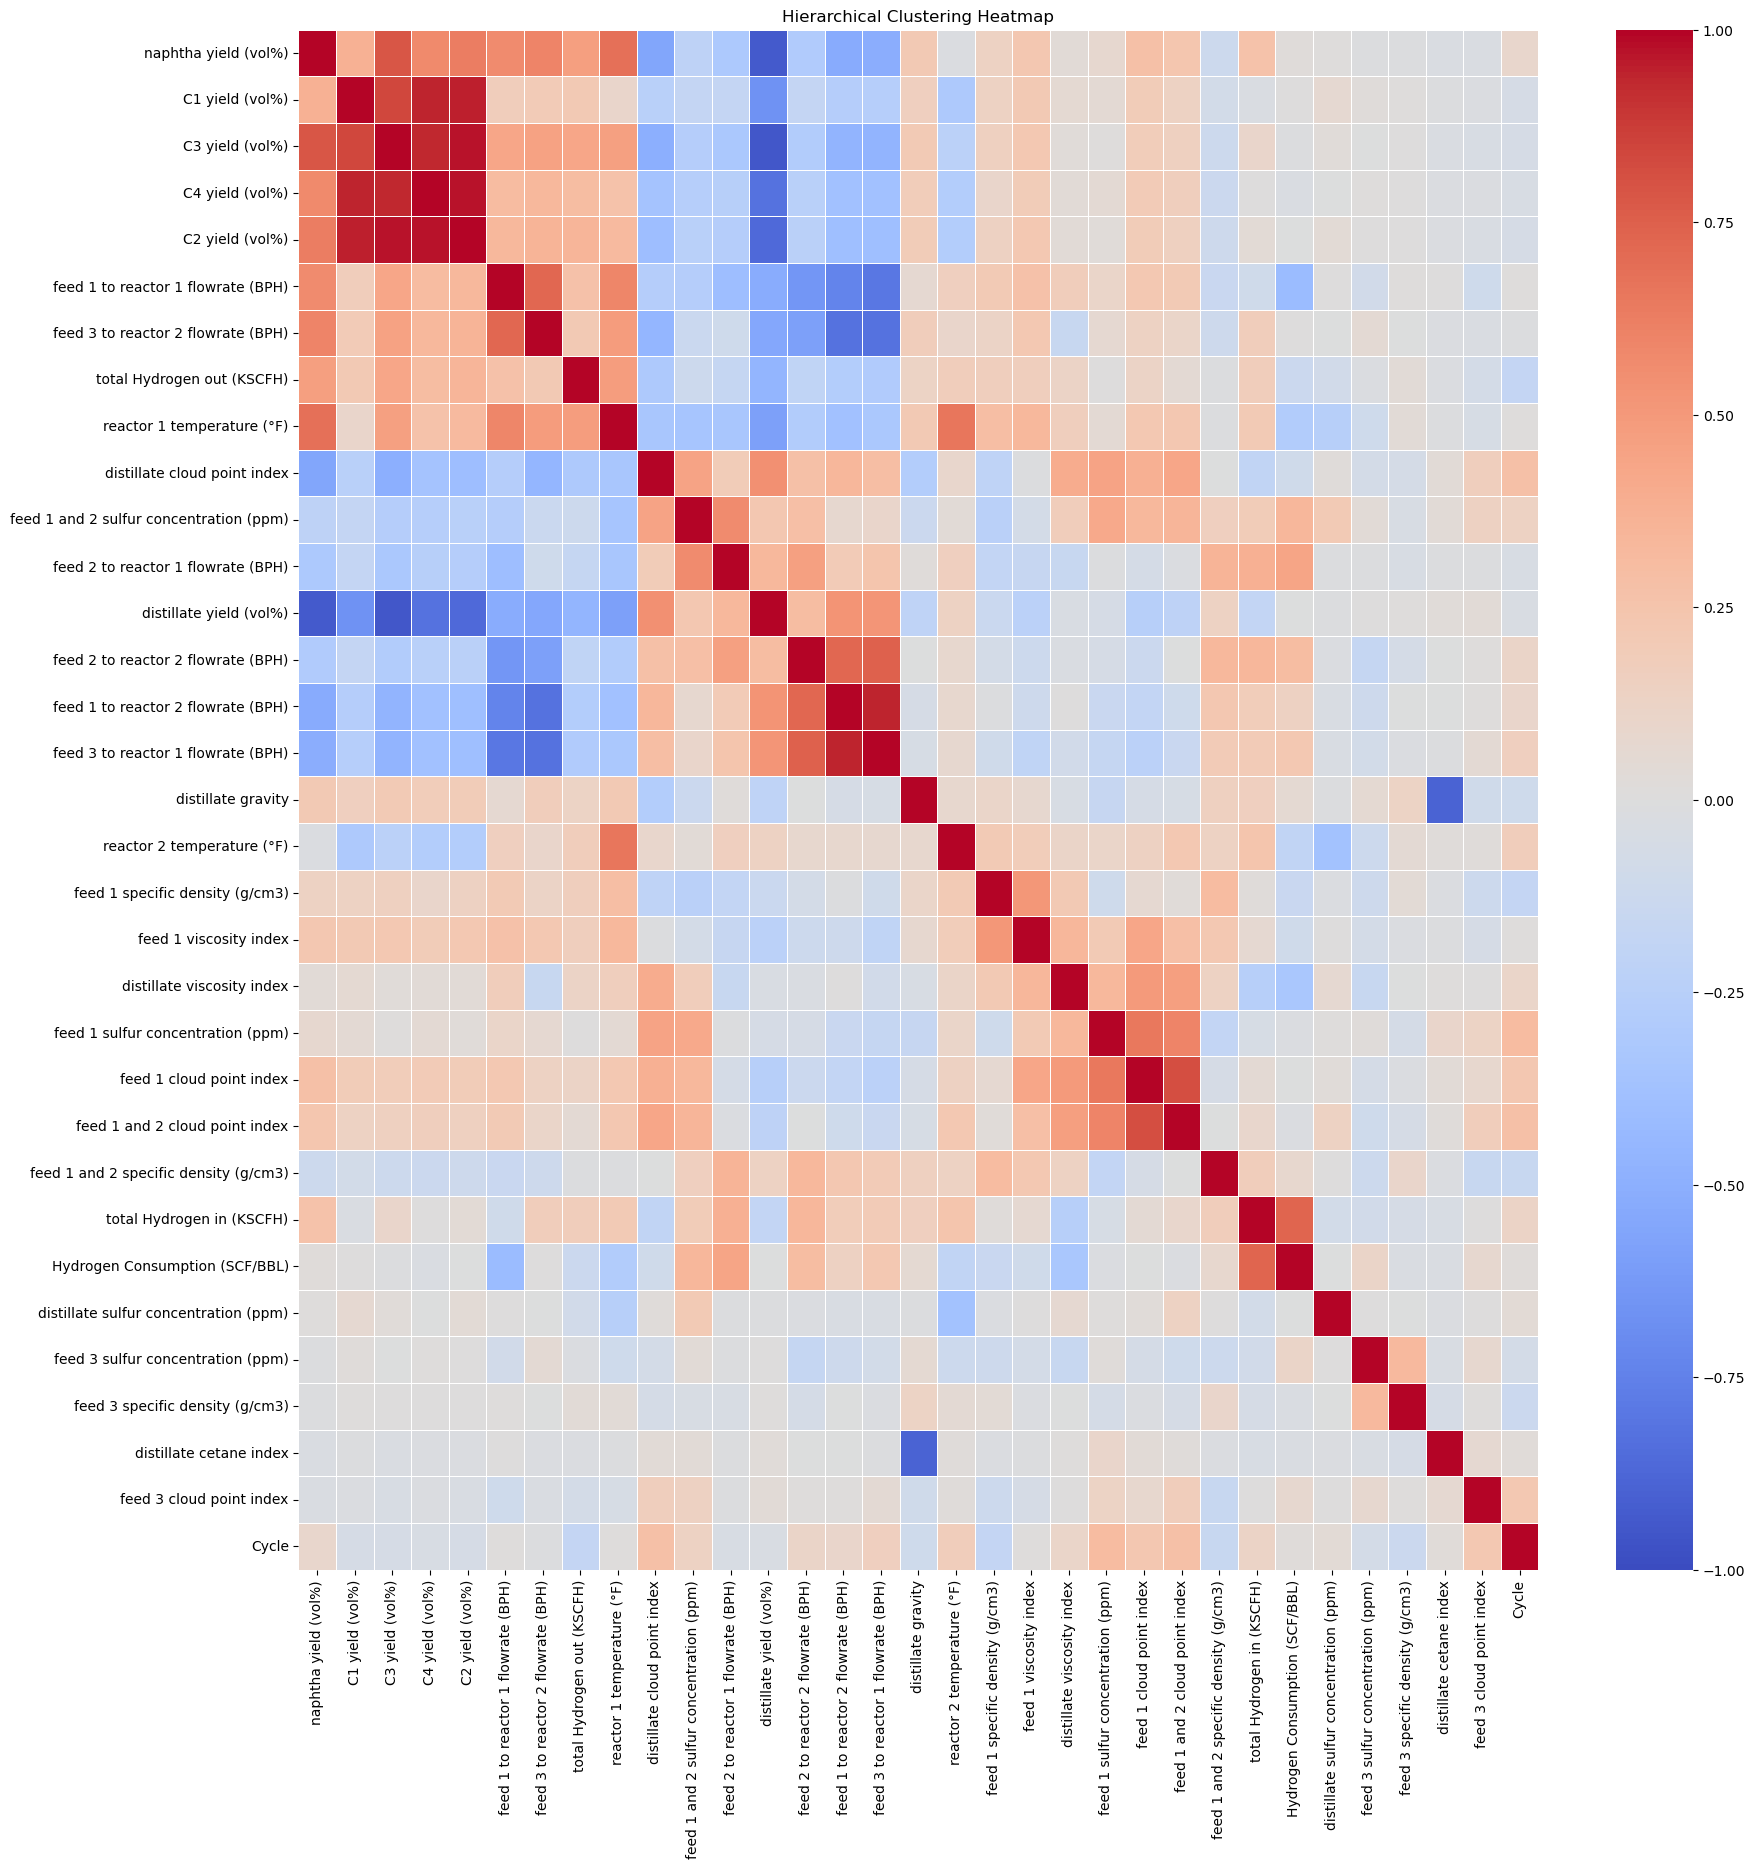

In [34]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
# Select a subset of features
selected_features = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']
  # Replace with your selected feature names

# Calculate the correlation matrix for the selected features
corr_matrix = dataset[selected_features].corr(method='pearson')

# Apply hierarchical clustering
linkage_matrix = linkage(corr_matrix, method='average')
dendro = dendrogram(linkage_matrix, labels=corr_matrix.columns, no_plot=True)

# Reorder the correlation matrix according to the clustering
ordered_features = dendro['ivl']
ordered_corr_matrix = corr_matrix.loc[ordered_features, ordered_features]

# Create a heatmap using seaborn
fig, ax = plt.subplots(figsize=(20, 20))  # Adjust the figure size as needed
sns.heatmap(ordered_corr_matrix, vmin=-1, vmax=1, annot=False, cmap="coolwarm", ax=ax, linewidths=0.5)

plt.title('Hierarchical Clustering Heatmap')
plt.show()

# Split the dataset to different modes of operation

In [14]:
# Define mode1 and mode2 based on the time (days)
mode1 = dataset[dataset['time (days)'] <= 60]
mode2 = dataset[dataset['time (days)'] > 60]

In [15]:
mode1 = mode1.reset_index(drop=True)
mode2 = mode2.reset_index(drop=True)

In [16]:
print("Number of measurements in Mode 1", len(mode1))
print("Number of measurements in Mode 2", len(mode2))


Number of measurements in Mode 1 323
Number of measurements in Mode 2 2973


# Imputation

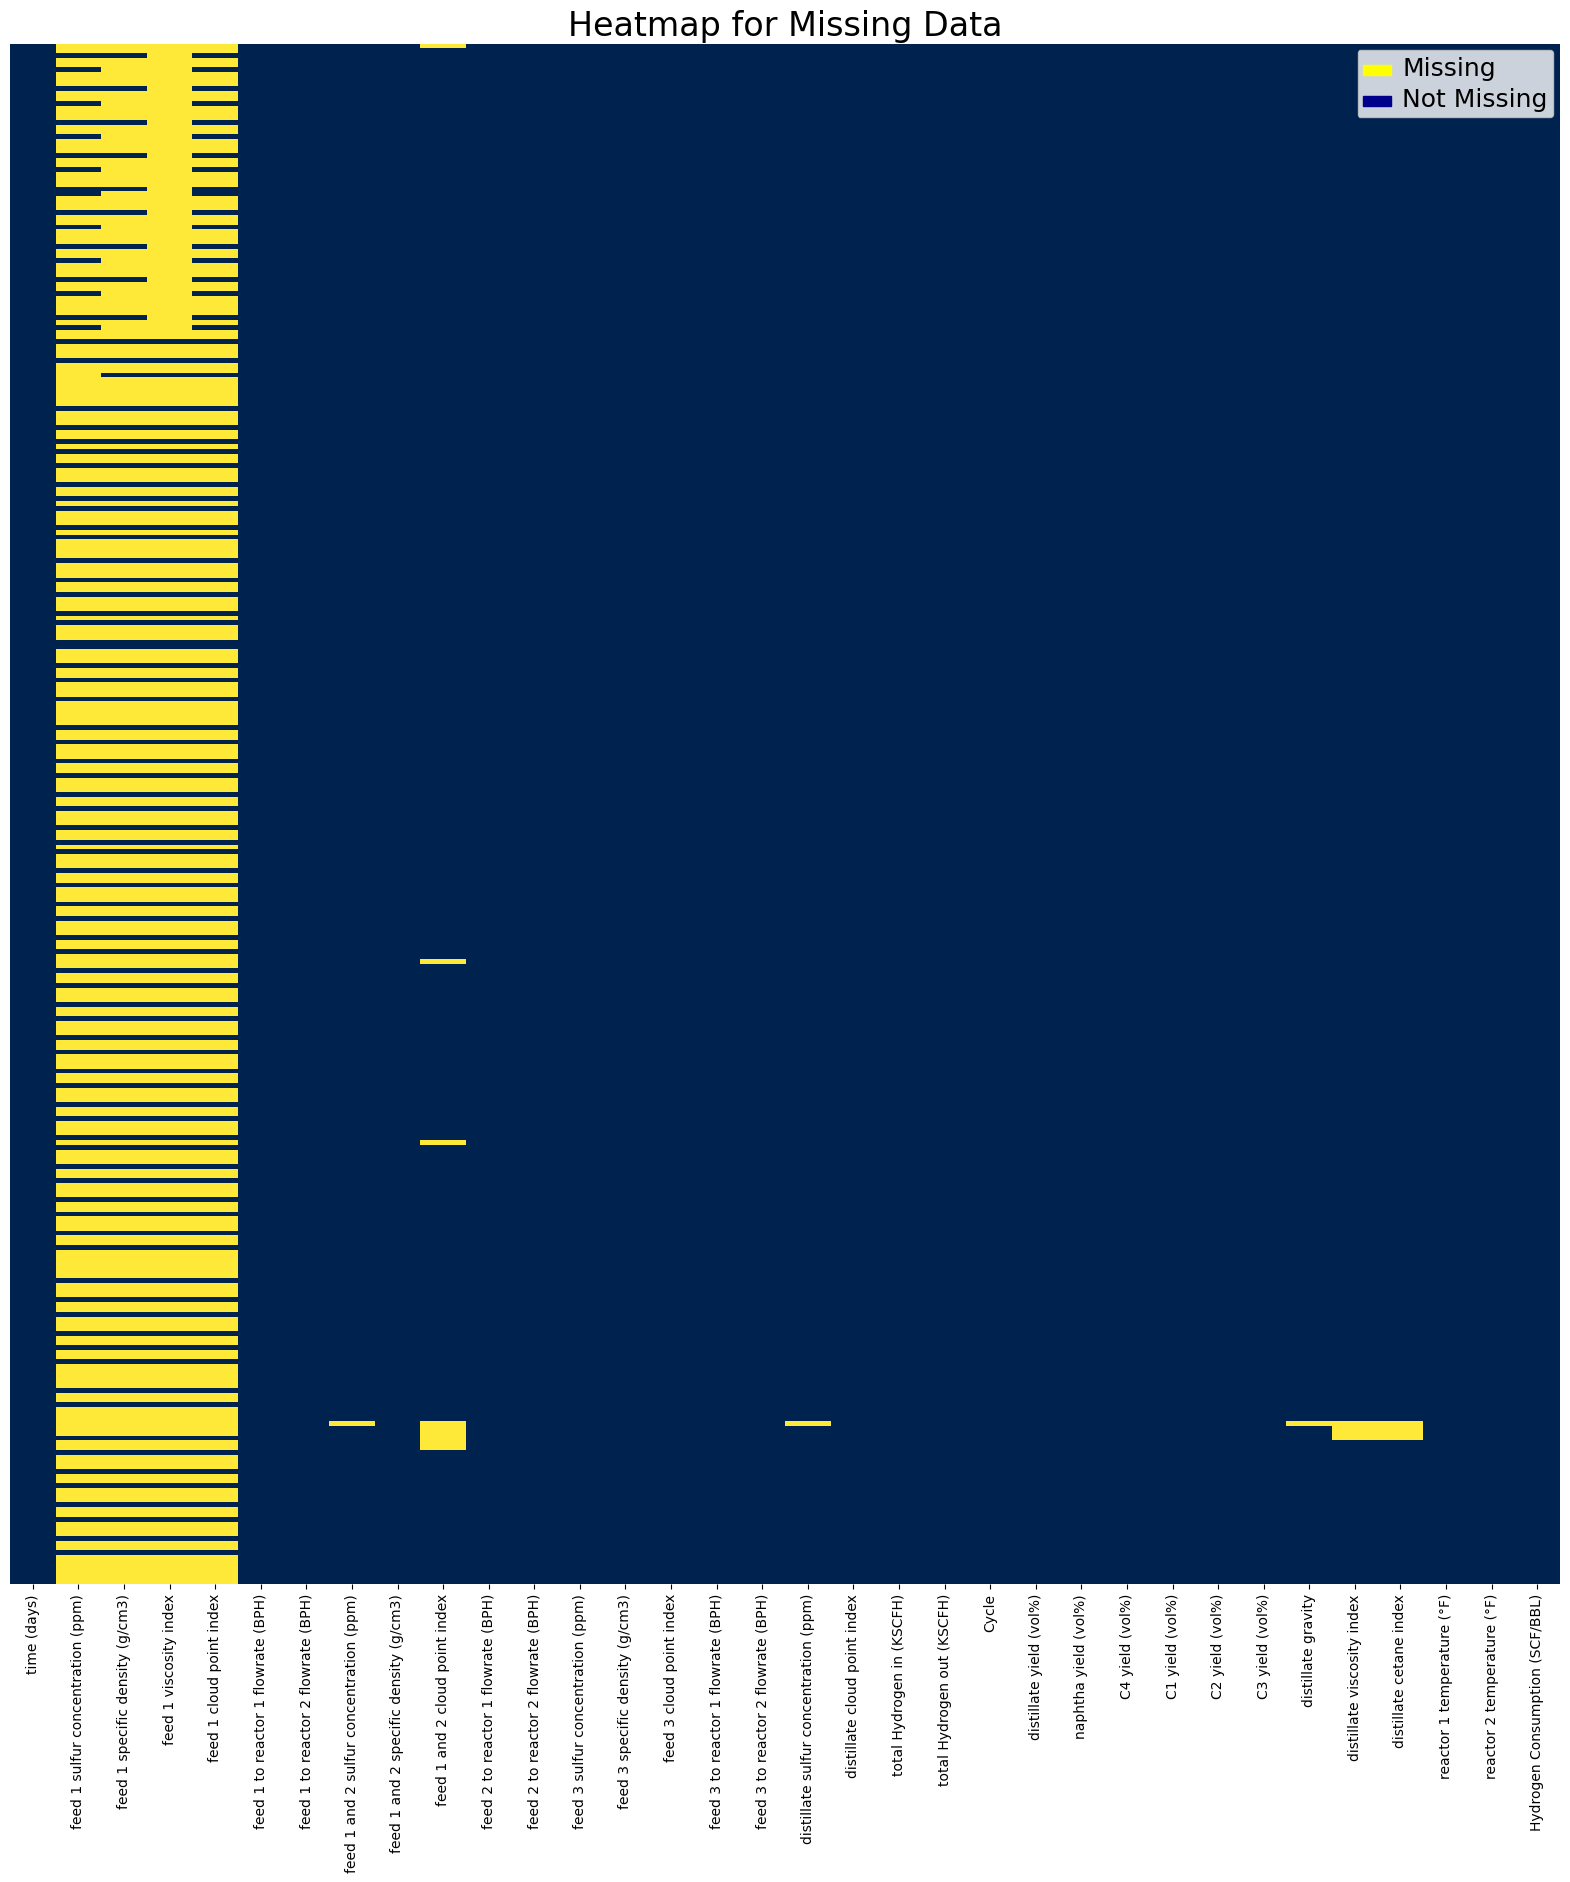

In [21]:
plt.figure(figsize=(20, 20))  # Adjust the figure size as needed
ax = sns.heatmap(mode1.isnull(), yticklabels=False, cbar=False, cmap='cividis')

# Create custom color patches for the legend
import matplotlib.patches as mpatches
missing_patch = mpatches.Patch(color='yellow', label='Missing')
not_missing_patch = mpatches.Patch(color='darkblue', label='Not Missing')

# Add legend to the plot with increased font size
legend = plt.legend(handles=[missing_patch, not_missing_patch], loc='upper right')
plt.setp(legend.get_texts(), fontsize=18)  # Increase legend text size
plt.setp(legend.get_title(), fontsize=20)  # Increase legend title size

plt.title('Heatmap for Missing Data', fontsize=24)
plt.show()


## Choosing an imputation algorithm based on CCA

# linear regression

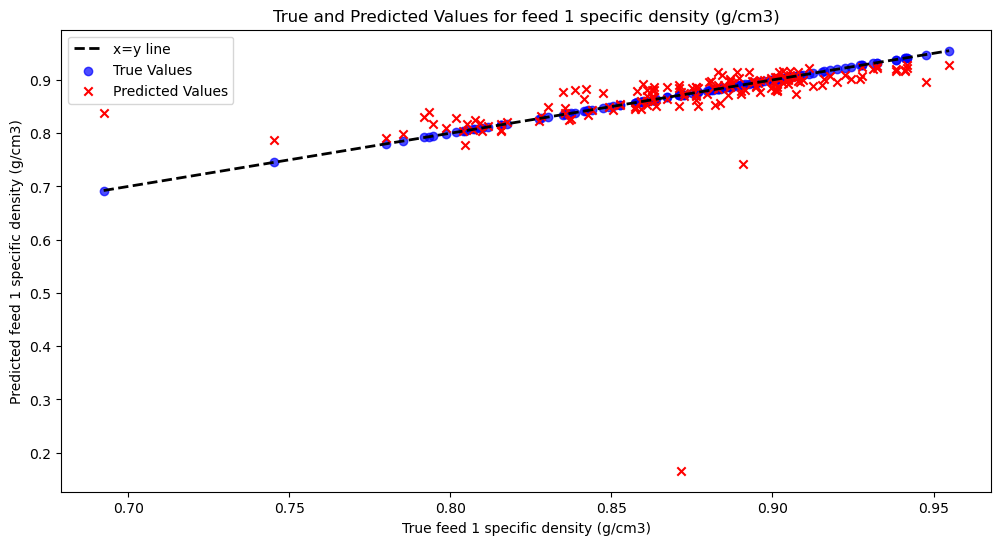

feed 1 specific density (g/cm3) Metrics:
MAE: 0.01909250922836543
MSE: 0.003678606090310409
RMSE: 0.060651513503872344
R2: -1.1155597612175447




In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']

# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Linear Regression model
    model = LinearRegression()

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### gradient boosting

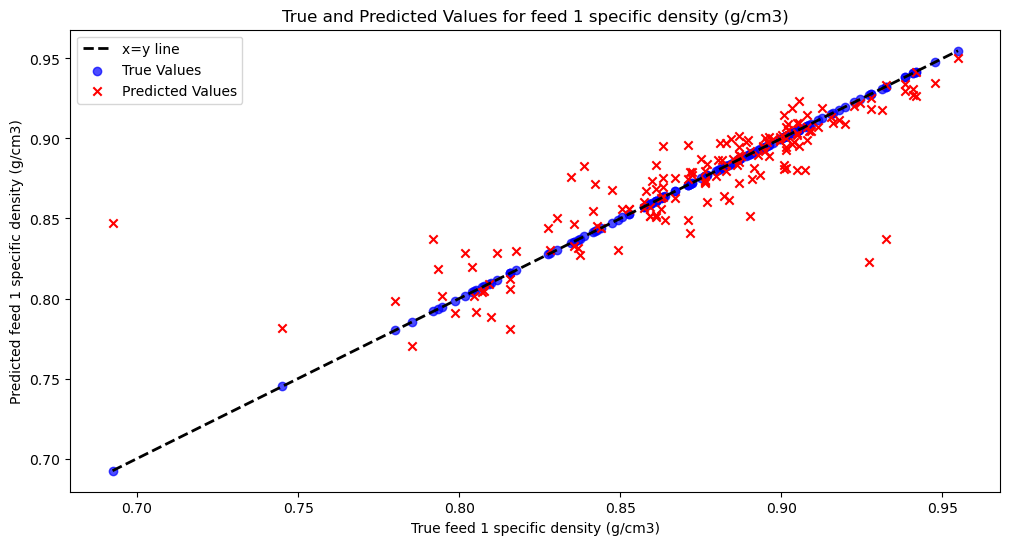

feed 1 specific density (g/cm3) Metrics:
MAE: 0.012097709283679627
MSE: 0.00046117050714250925
RMSE: 0.02147488084117137
R2: 0.7347816689205082




In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']

# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Gradient Boosting Regression model
    model = GradientBoostingRegressor(n_estimators=100, random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### Descision tree

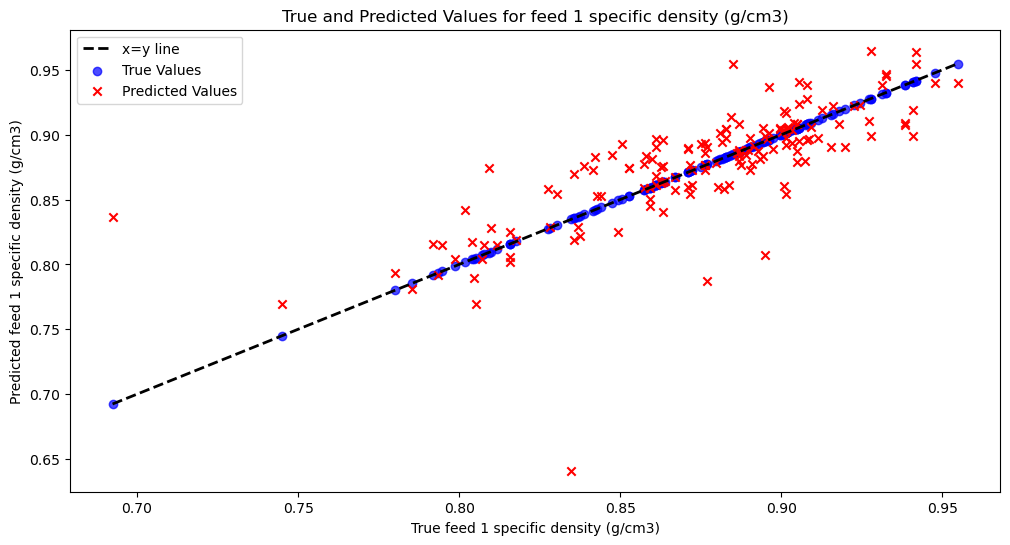

feed 1 specific density (g/cm3) Metrics:
MAE: 0.01807372570487736
MSE: 0.0008571687049636656
RMSE: 0.029277443620706806
R2: 0.5070438159789307




In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']

# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Decision Tree Regression model
    model = DecisionTreeRegressor(random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### Random Forest

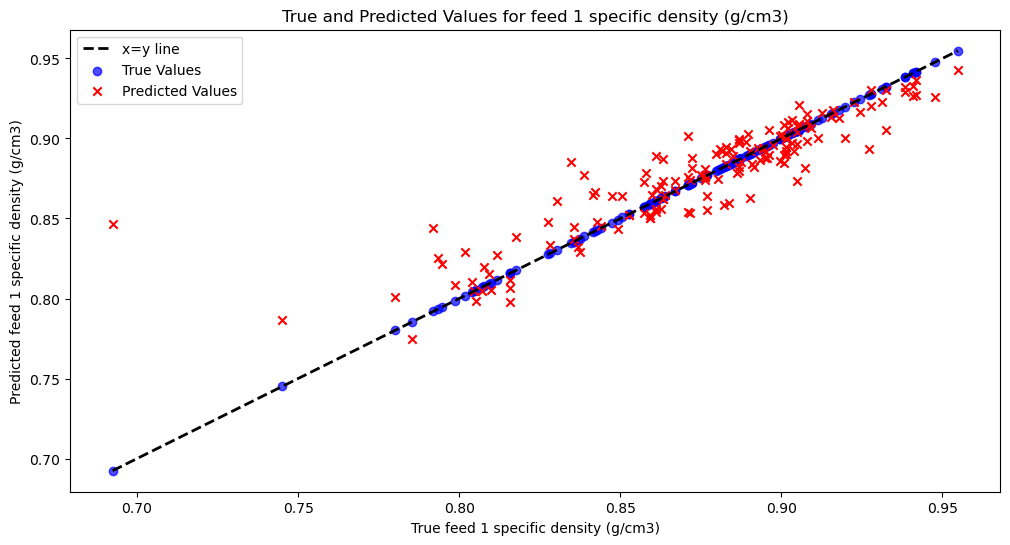

feed 1 specific density (g/cm3) Metrics:
MAE: 0.011353514062295856
MSE: 0.0003533053753000203
RMSE: 0.01879641921484037
R2: 0.7968147126773458




In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']


# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Random Forest Regression model
    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### Support Vector Regression

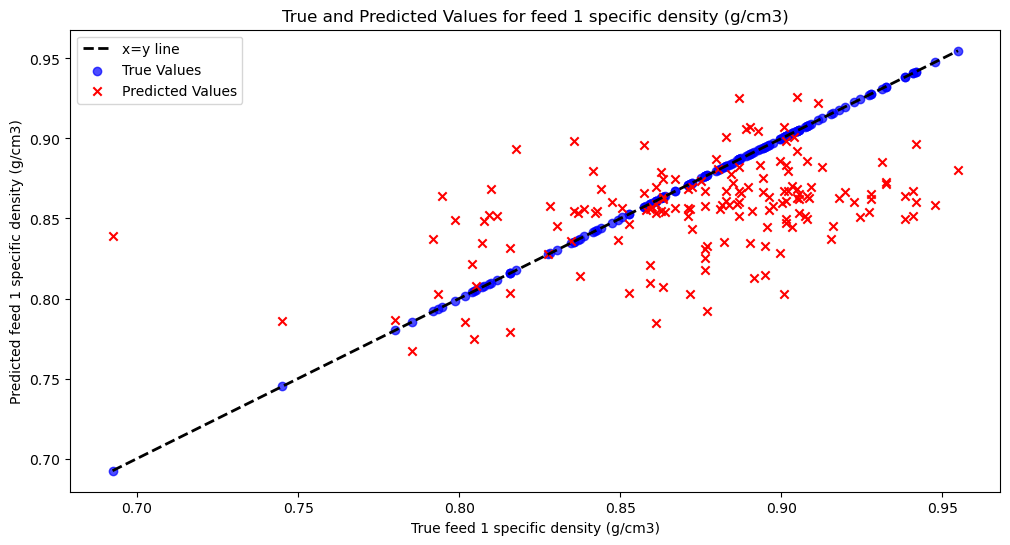

feed 1 specific density (g/cm3) Metrics:
MAE: 0.03445624694476198
MSE: 0.0018628034848313384
RMSE: 0.04316020719171003
R2: -0.07129494129458602




In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']



# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the SVR model
    model = SVR(kernel='rbf')

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### Ridge Regression

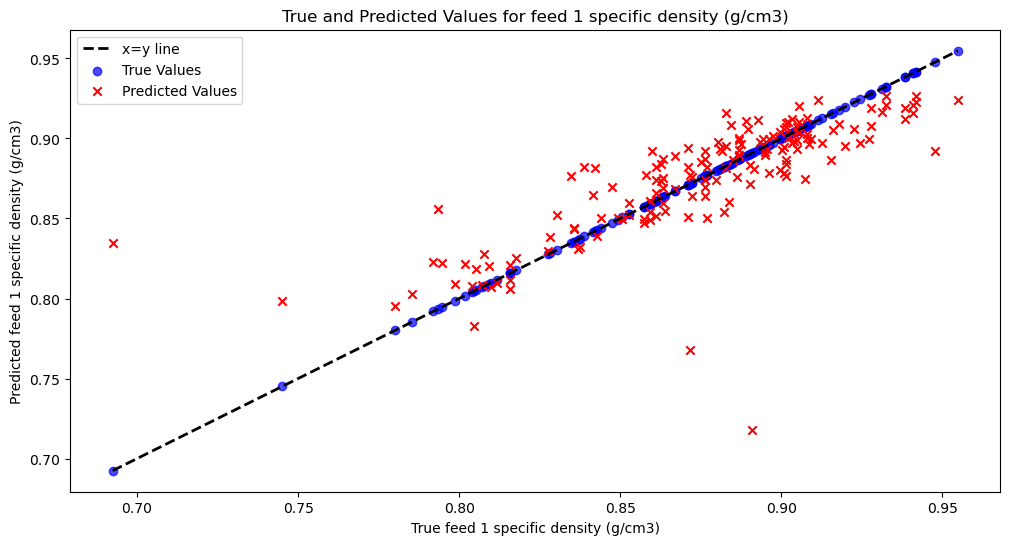

feed 1 specific density (g/cm3) Metrics:
MAE: 0.015769379719264124
MSE: 0.00067868088903354
RMSE: 0.026051504544527558
R2: 0.6096918386209839




In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']

# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Ridge Regression model
    model = Ridge(alpha=0.1)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### Lasso Regression

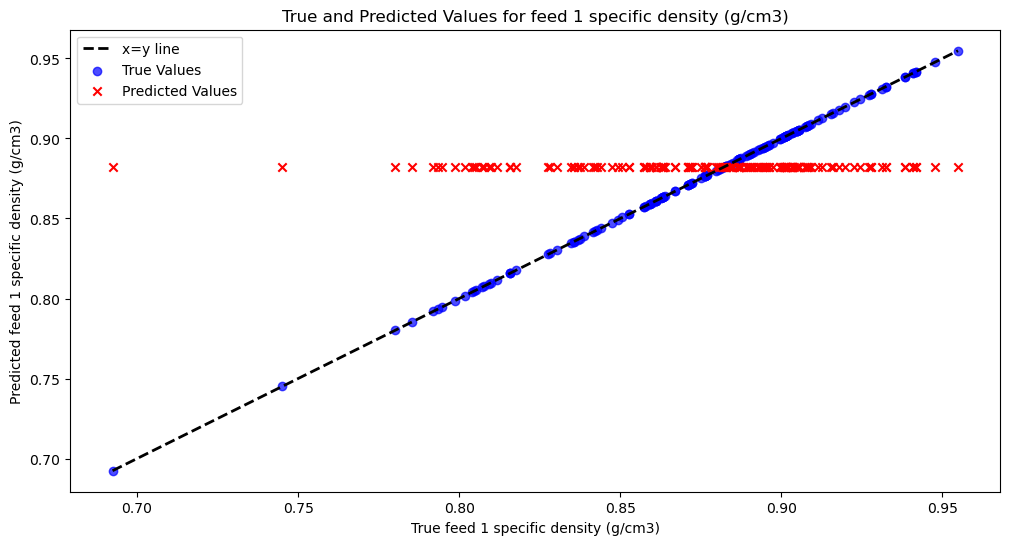

feed 1 specific density (g/cm3) Metrics:
MAE: 0.031495922713370324
MSE: 0.0017940922944290343
RMSE: 0.042356726672737995
R2: -0.03177925899759804




In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']
# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Lasso Regression model
    model = Lasso(alpha=0.05)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


### KNN Regression

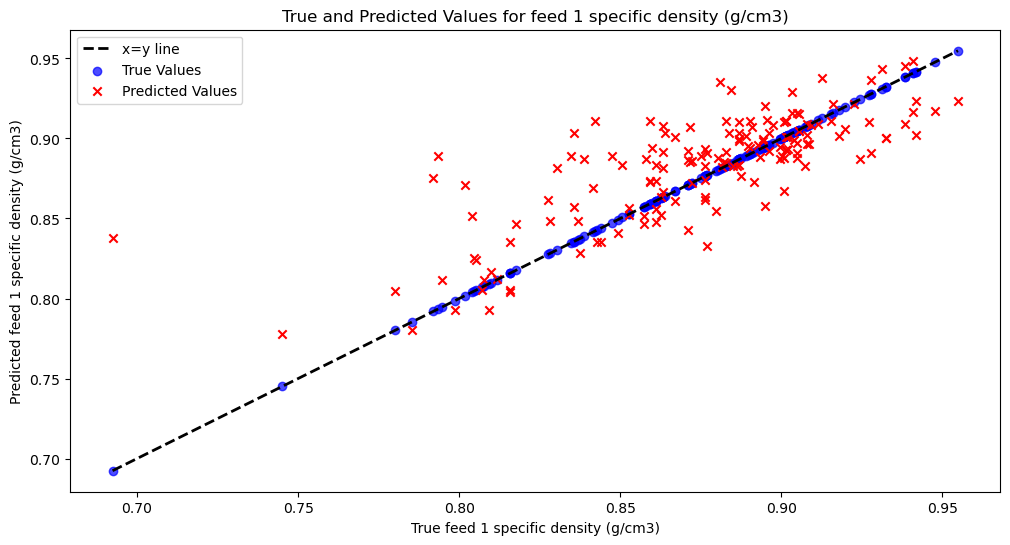

feed 1 specific density (g/cm3) Metrics:
MAE: 0.01909743873989887
MSE: 0.0007496255759950412
RMSE: 0.027379291006069555
R2: 0.5688916764608483




In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# Load the dataset
data = dataset.values
feature_names = dataset.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Choose the target features
selected_target_feature_names = ['feed 1 specific density (g/cm3)']

# Fill missing values for selected target features
data_without_na_target = dataset.dropna(subset=selected_target_feature_names).values

# Impute missing values for remaining features using KNN
imputer = KNNImputer()
data_without_na = imputer.fit_transform(data_without_na_target)

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_without_na)

# Initialize a dictionary to store predictions and metrics for each target feature
predictions_dict = {}
metrics_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the KNN Regression model
    model = KNeighborsRegressor(n_neighbors=3)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = predictions

    # Plot the results and calculate metrics for the selected target feature
    plt.figure(figsize=(12, 6))
    
    # Plot x=y line
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    
    # Scatter plot for true values
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    
    # Scatter plot for predicted values
    plt.scatter(y_test, predictions, label='Predicted Values', color='red', marker='x')
    
    plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression}")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store metrics in the dictionary
    metrics_dict[selected_feature_for_regression] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{selected_feature_for_regression} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("\n")


## Selecting Random Forest as regression model for iterative imputation 

In [39]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

def iterativeforest(misdata):
    # Make a copy of the data
    data = misdata.copy()


    # Set up the imputer with a different estimator
    imp = IterativeImputer(
        estimator=RandomForestRegressor(
            n_estimators=50,  # Adjust the parameters as needed
            random_state=1
        ),
        missing_values=np.nan,
        max_iter=10,
        initial_strategy='mean',
        imputation_order='ascending',
        verbose=2,
        random_state=1
    )

    # Impute missing values without modifying the original DataFrame
    imputed_data = imp.fit_transform(data)

    # Create a new DataFrame with the imputed values
    imputed_df = pd.DataFrame(imputed_data, columns=data.columns)

    return imputed_df


[IterativeImputer] Completing matrix with shape (2973, 34)
[IterativeImputer] Ending imputation round 1/1, elapsed time 142.17
[IterativeImputer] Change: 2456.257206943313, scaled tolerance: 9.94 
[IterativeImputer] Completing matrix with shape (2973, 34)


/Users/arianrezaei/anaconda3/envs/cat/lib/python3.10/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 1/2, elapsed time 140.33
[IterativeImputer] Change: 2456.257206943313, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 2/2, elapsed time 288.55
[IterativeImputer] Change: 1460.9829914694303, scaled tolerance: 9.94 
[IterativeImputer] Completing matrix with shape (2973, 34)


/Users/arianrezaei/anaconda3/envs/cat/lib/python3.10/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 1/3, elapsed time 128.95
[IterativeImputer] Change: 2456.257206943313, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 2/3, elapsed time 295.31
[IterativeImputer] Change: 1460.9829914694303, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 3/3, elapsed time 441.24
[IterativeImputer] Change: 575.3876451352598, scaled tolerance: 9.94 


...

/Users/arianrezaei/anaconda3/envs/cat/lib/python3.10/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Completing matrix with shape (2973, 34)
[IterativeImputer] Ending imputation round 1/9, elapsed time 93.67
[IterativeImputer] Change: 2456.257206943313, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 2/9, elapsed time 198.79
[IterativeImputer] Change: 1460.9829914694303, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 3/9, elapsed time 299.38
[IterativeImputer] Change: 575.3876451352598, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 4/9, elapsed time 401.68
[IterativeImputer] Change: 814.53696920478, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 5/9, elapsed time 502.72
[IterativeImputer] Change: 1248.6898088339, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 6/9, elapsed time 603.55
[IterativeImputer] Change: 558.351075144361, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 7/9, elapsed time 710.32
[IterativeImputer] Change: 560.7201415567201, scal

/Users/arianrezaei/anaconda3/envs/cat/lib/python3.10/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Completing matrix with shape (2973, 34)
[IterativeImputer] Ending imputation round 1/10, elapsed time 92.05
[IterativeImputer] Change: 2456.257206943313, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 2/10, elapsed time 191.92
[IterativeImputer] Change: 1460.9829914694303, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 3/10, elapsed time 292.09
[IterativeImputer] Change: 575.3876451352598, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 4/10, elapsed time 392.52
[IterativeImputer] Change: 814.53696920478, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 5/10, elapsed time 495.65
[IterativeImputer] Change: 1248.6898088339, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 6/10, elapsed time 601.45
[IterativeImputer] Change: 558.351075144361, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 7/10, elapsed time 701.41
[IterativeImputer] Change: 560.720141556720

/Users/arianrezaei/anaconda3/envs/cat/lib/python3.10/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


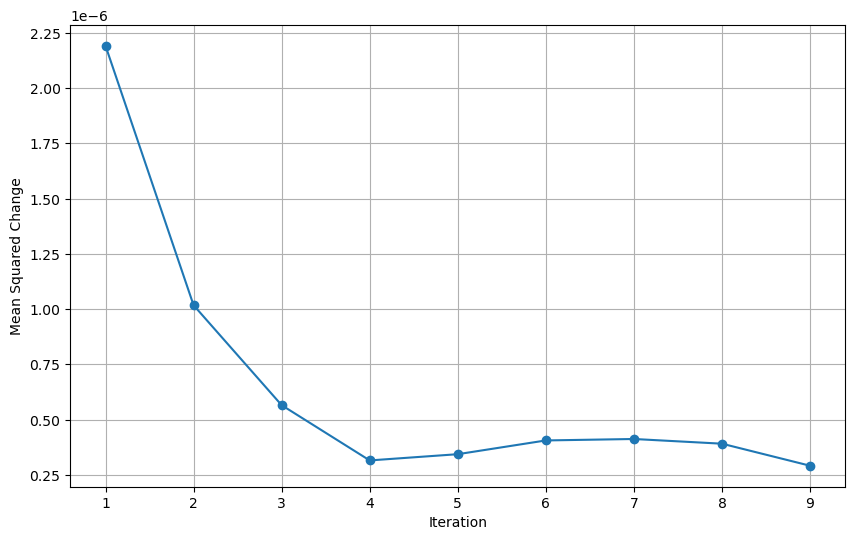

In [32]:
def iterativeforest_with_visualization_single_feature(misdata, feature_name):
    # Make a copy of the data
    data = misdata.copy()
    
    # Check if the feature exists
    if feature_name not in data.columns:
        raise ValueError(f"The feature '{feature_name}' does not exist in the dataset.")
    
    # Initialize the imputer
    imp = IterativeImputer(
        estimator=RandomForestRegressor(
            n_estimators=50,  # Adjust the parameters as needed
            random_state=1
        ),
        missing_values=np.nan,
        max_iter=10,
        initial_strategy='mean',
        imputation_order='ascending',
        verbose=2,
        random_state=1
    )
    
    # Track the progress of imputations
    tracked_imputations = []
    for iteration in range(1, imp.max_iter + 1):
        imp.max_iter = iteration
        imputed_data = imp.fit_transform(data)
        tracked_imputations.append(imputed_data.copy())
    
    # Extract the column of interest for MSC calculation
    feature_idx = data.columns.get_loc(feature_name)
    metrics = [np.nanmean((tracked_imputations[i][:, feature_idx] - tracked_imputations[i-1][:, feature_idx]) ** 2)
               for i in range(1, len(tracked_imputations))]
    
    # Plot the convergence of imputed values for the single feature
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(metrics) + 1), metrics, marker='o')
    #plt.title(f'Convergence of Imputed Values for {feature_name} Across Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Mean Squared Change')
    plt.grid()
    plt.show()
    
    # Return the final imputed DataFrame
    final_imputed_df = pd.DataFrame(tracked_imputations[-1], columns=misdata.columns)
    return final_imputed_df

imputed_data = iterativeforest_with_visualization_single_feature(mode2, 'feed 1 specific density (g/cm3)')


In [40]:
mode1filled = iterativeforest(mode1)
mode2filled = iterativeforest(mode2)

[IterativeImputer] Completing matrix with shape (2973, 34)
[IterativeImputer] Ending imputation round 1/10, elapsed time 121.23
[IterativeImputer] Change: 2456.257206943313, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 2/10, elapsed time 253.06
[IterativeImputer] Change: 1460.9829914694303, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 3/10, elapsed time 390.65
[IterativeImputer] Change: 575.3876451352598, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 4/10, elapsed time 525.62
[IterativeImputer] Change: 814.53696920478, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 5/10, elapsed time 657.84
[IterativeImputer] Change: 1248.6898088339, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 6/10, elapsed time 790.79
[IterativeImputer] Change: 558.351075144361, scaled tolerance: 9.94 
[IterativeImputer] Ending imputation round 7/10, elapsed time 920.88
[IterativeImputer] Change: 560.72014155672

/Users/arianrezaei/anaconda3/envs/cat/lib/python3.10/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


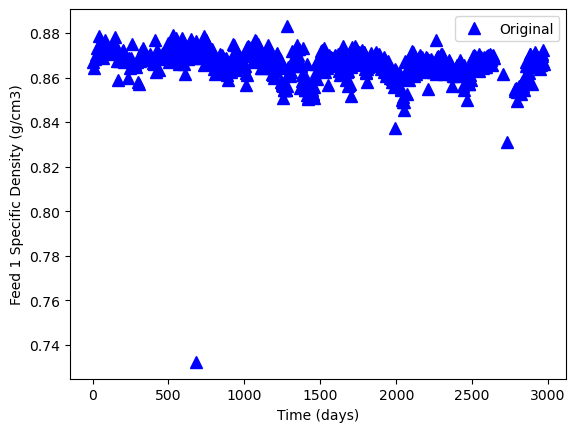

In [45]:
plt.plot(mode2.index, mode2['feed 1 specific density (g/cm3)'], '^', markersize=8, color='blue', label='Original', alpha=1)

plt.xlabel('Time (days)')
plt.ylabel('Feed 1 Specific Density (g/cm3)')
#plt.title('Feed 1 Specific Density over Time')
plt.legend()

# Showing the plot
plt.show()


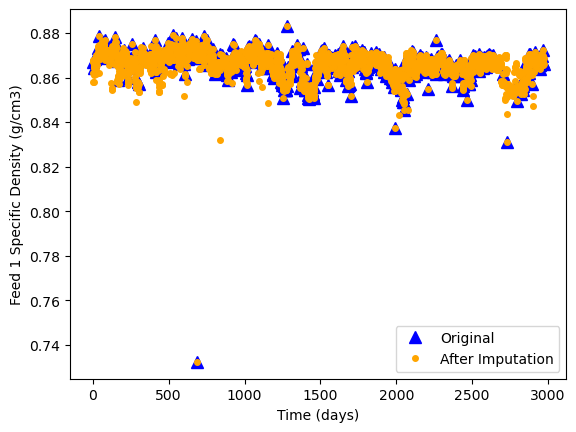

In [46]:
plt.plot(mode2.index, mode2['feed 1 specific density (g/cm3)'], '^', markersize=8, color='blue', label='Original', alpha=1)
plt.plot(mode2filled.index, mode2filled['feed 1 specific density (g/cm3)'], 'o', markersize=4, color='orange', label='After Imputation', alpha=1)

plt.xlabel('Time (days)')
plt.ylabel('Feed 1 Specific Density (g/cm3)')
plt.legend()

# Showing the plot
plt.show()


# Removing outliers

In [41]:
import pandas as pd

def remove_outliers_3sigma(dataframe, features):
    # Make a copy of the dataframe to avoid modifying the original one
    dataframe_copy = dataframe.copy()

    for feature in features:
        # Calculate the mean and standard deviation of the feature
        mean = dataframe_copy[feature].mean()
        std_dev = dataframe_copy[feature].std()

        # Define the upper and lower thresholds using the 3-sigma rule
        upper_threshold = mean + 3 * std_dev
        lower_threshold = mean - 3 * std_dev

        # Remove rows where the feature value is outside the 3-sigma range
        dataframe_copy = dataframe_copy[(dataframe_copy[feature] >= lower_threshold) & (dataframe_copy[feature] <= upper_threshold)]

    return dataframe_copy


# Define features
features = ['feed 1 specific density (g/cm3)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index',
                'reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']


# Remove outliers using the 3-sigma method
mode1_cleaned = remove_outliers_3sigma(mode1filled, features)
mode2_cleaned = remove_outliers_3sigma(mode2filled, features)

# Print the number of rows remaining after cleaning
print(f"Number of rows remaining in mode1_cleaned: {len(mode1_cleaned)}")
print(f"Number of rows remaining in mode2_cleaned: {len(mode2_cleaned)}")



Number of rows remaining in mode2_cleaned: 2872


In [42]:
import pandas as pd
from sklearn.ensemble import IsolationForest

def remove_outliers_isolation_forest(dataframe, features, contamination='auto', random_state=None):
    # Make a copy of the dataframe to avoid modifying the original one
    dataframe_copy = dataframe.copy()
    
    # Convert non-numeric values to NaN
    dataframe_copy[features] = dataframe_copy[features].apply(pd.to_numeric, errors='coerce')


    # Initialize Isolation Forest model
    clf = IsolationForest(contamination=contamination, random_state=random_state)

    # Fit the model to the selected features
    clf.fit(dataframe_copy[features])

    # Predict outliers
    outlier_mask = clf.predict(dataframe_copy[features]) == -1

    # Remove outliers from the dataframe copy
    dataframe_no_outliers = dataframe_copy[~outlier_mask]

    return dataframe_no_outliers

# Define features
features = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)','distillate sulfur concentration (ppm)',
                'distillate cloud point index','total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','Cycle','distillate yield (vol%)','naphtha yield (vol%)','C4 yield (vol%)','C1 yield (vol%)',
                'C2 yield (vol%)','C3 yield (vol%)','distillate gravity','distillate viscosity index','distillate cetane index','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Remove outliers using Isolation Forest with automatic contamination detection
mode1_clean = remove_outliers_isolation_forest(mode1_cleaned, features, contamination='auto', random_state=42)
mode2_clean = remove_outliers_isolation_forest(mode2_cleaned, features, contamination='auto', random_state=42)

# Display the number of rows for each mode
print("Number of rows in Mode 1 after cleaning outliers:", len(mode1_clean))
print("Number of rows in Mode 2 after cleaning outliers:", len(mode2_clean))


Number of rows in Mode 2 after cleaning outliers: 2606


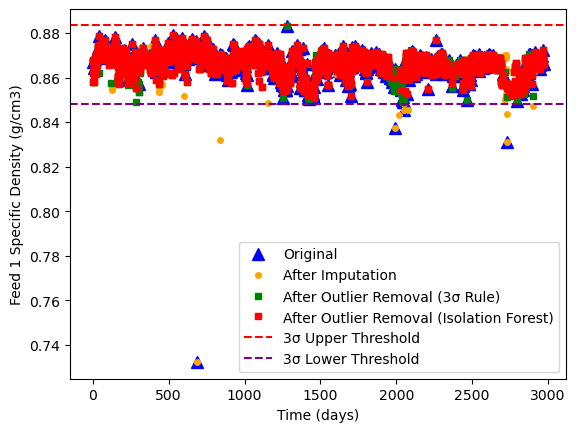

In [44]:
import matplotlib.pyplot as plt

# Calculate the mean and standard deviation for 'feed 1 specific density (g/cm3)' in mode2filled
mean_specific_density = mode2filled['feed 1 specific density (g/cm3)'].mean()
std_dev_specific_density = mode2filled['feed 1 specific density (g/cm3)'].std()

# Calculate 3-sigma thresholds
upper_threshold_specific_density = mean_specific_density + 3 * std_dev_specific_density
lower_threshold_specific_density = mean_specific_density - 3 * std_dev_specific_density

# Plot the data
plt.plot(mode2.index, mode2['feed 1 specific density (g/cm3)'], '^', markersize=8, color='blue', label='Original', alpha=1)
plt.plot(mode2filled.index, mode2filled['feed 1 specific density (g/cm3)'], 'o', markersize=4, color='orange', label='After Imputation', alpha=1)
plt.plot(mode2_cleaned.index, mode2_cleaned['feed 1 specific density (g/cm3)'], 's', markersize=4, color='green', label='After Outlier Removal (3σ Rule)', alpha=1)
plt.plot(mode2_clean.index, mode2_clean['feed 1 specific density (g/cm3)'], 's', markersize=4, color='red', label='After Outlier Removal (Isolation Forest)', alpha=1)

# Add 3-sigma threshold lines
plt.axhline(upper_threshold_specific_density, color='red', linestyle='--', linewidth=1.5, label='3σ Upper Threshold')
plt.axhline(lower_threshold_specific_density, color='purple', linestyle='--', linewidth=1.5, label='3σ Lower Threshold')

# Add labels and title
plt.xlabel('Time (days)')
plt.ylabel('Feed 1 Specific Density (g/cm3)')

# Add legend
plt.legend()

# Show the plot
plt.show()


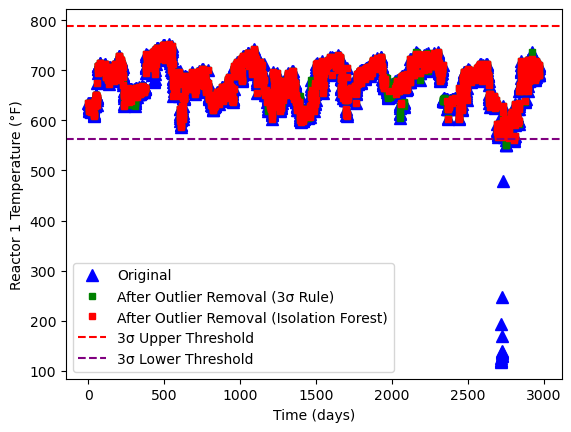

In [49]:
import matplotlib.pyplot as plt

# Calculate the mean and standard deviation for 'reactor 1 temperature (°F)' in mode2_cleaned
mean_reactor1_temp = mode2_cleaned['reactor 1 temperature (°F)'].mean()
std_dev_reactor1_temp = mode2_cleaned['reactor 1 temperature (°F)'].std()

# Calculate 3-sigma thresholds
upper_threshold_reactor1_temp = mean_reactor1_temp + 3 * std_dev_reactor1_temp
lower_threshold_reactor1_temp = mean_reactor1_temp - 3 * std_dev_reactor1_temp

# Plot the data
plt.plot(mode2.index, mode2['reactor 1 temperature (°F)'], '^', markersize=8, color='blue', label='Original', alpha=1)
#plt.plot(mode2filled.index, mode2filled['reactor 1 temperature (°F)'], 'o', markersize=4, color='orange', label='After Imputation', alpha=1)
plt.plot(mode2_cleaned.index, mode2_cleaned['reactor 1 temperature (°F)'], 's', markersize=4, color='green', label='After Outlier Removal (3σ Rule)', alpha=1)
plt.plot(mode2_clean.index, mode2_clean['reactor 1 temperature (°F)'], 's', markersize=4, color='red', label='After Outlier Removal (Isolation Forest)', alpha=1)

# Add 3-sigma threshold lines
plt.axhline(upper_threshold_reactor1_temp, color='red', linestyle='--', linewidth=1.5, label='3σ Upper Threshold')
plt.axhline(lower_threshold_reactor1_temp, color='purple', linestyle='--', linewidth=1.5, label='3σ Lower Threshold')

# Add labels and title
plt.xlabel('Time (days)')
plt.ylabel('Reactor 1 Temperature (°F)')

# Add legend
plt.legend()

# Show the plot
plt.show()



# Modelling

## Mode 1

### Decision Tree 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                   
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]
    
    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=41)

    # Build the Decision Tree Regression model
    model = DecisionTreeRegressor(random_state=41)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### Xgboost 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Load the dataset
data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)',
                'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=41)

    # Build the XGBoost Regression model
    model = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=6, random_state=41)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### Support Vector Regression

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
               ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]
    
    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=41)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=41)

    # Build the SVR model
    model = SVR(kernel='rbf')

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### DNN

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                           
# Prepare the data for training with selected input features
X = data[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
y = data[:, [feature_names.index(feature) for feature in selected_target_feature_names]]

# Normalize the data using MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Split the data into training, validation, and testing sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=41)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=41)

# Build the DNN model
model = keras.Sequential([
    keras.layers.Dense(units=50, activation='tanh', input_dim=X_train.shape[1]),
    keras.layers.Dense(units=50, activation='tanh', input_dim=X_train.shape[1]),
    keras.layers.Dense(units=50, activation='tanh', input_dim=X_train.shape[1]),
    keras.layers.Dense(units=y_scaled.shape[1])  # One output node per target feature
])

model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=1)

# Make predictions on the validation set
val_predictions = model.predict(X_val)

# Plot the results and calculate metrics for the validation set
for i, feature_name in enumerate(selected_target_feature_names):
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val[:, i]), max(y_val[:, i])], [min(y_val[:, i]), max(y_val[:, i])], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val[:, i], y_val[:, i], label=f'Validation Set: True {feature_name}', marker='o', color='blue', alpha=0.7)
    plt.scatter(y_val[:, i], val_predictions[:, i], label=f'Validation Set: Predicted {feature_name}', marker='x', color='red', alpha=0.7)
    '''plt.legend()
    plt.title(f"True and Predicted Values for {feature_name} (Validation Set)")
    plt.xlabel(f'True {feature_name}')
    plt.ylabel(f'Predicted {feature_name}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val[:, i], val_predictions[:, i])
    val_mse = mean_squared_error(y_val[:, i], val_predictions[:, i])
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val[:, i], val_predictions[:, i])

    # Print validation metrics
    print(f"{feature_name} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

# Make predictions on the test set
test_predictions = model.predict(X_test)

# Plot the results and calculate metrics for the test set
for i, feature_name in enumerate(selected_target_feature_names):
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test[:, i]), max(y_test[:, i])], [min(y_test[:, i]), max(y_test[:, i])], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test[:, i], y_test[:, i], label=f'Test Set: True {feature_name}', marker='o', color='blue', alpha=0.7)
    plt.scatter(y_test[:, i], test_predictions[:, i], label=f'Test Set: Predicted {feature_name}', marker='x', color='red', alpha=0.7)
    '''plt.legend()
    plt.title(f"True and Predicted Values for {feature_name} (Test Set)")
    plt.xlabel(f'True {feature_name}')
    plt.ylabel(f'Predicted {feature_name}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test[:, i], test_predictions[:, i])
    test_mse = mean_squared_error(y_test[:, i], test_predictions[:, i])
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test[:, i], test_predictions[:, i])

    # Print test metrics
    print(f"{feature_name} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")

# Plot training loss across epochs
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.title('Training Loss Across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


### Random Forest

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]
    
    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=41)

    # Build the Random Forest Regression model
    model = RandomForestRegressor(n_estimators=1000, random_state=41)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### LightGBM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor

# Load the dataset
data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)',
                'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
               
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=41)

    # Build the LightGBM Regression model
    model = LGBMRegressor(n_estimators=1000, learning_rate=0.1, random_state=41)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### Catboost 

Cross-Validation RMSE for distillate yield (vol%): 0.006852428547241706


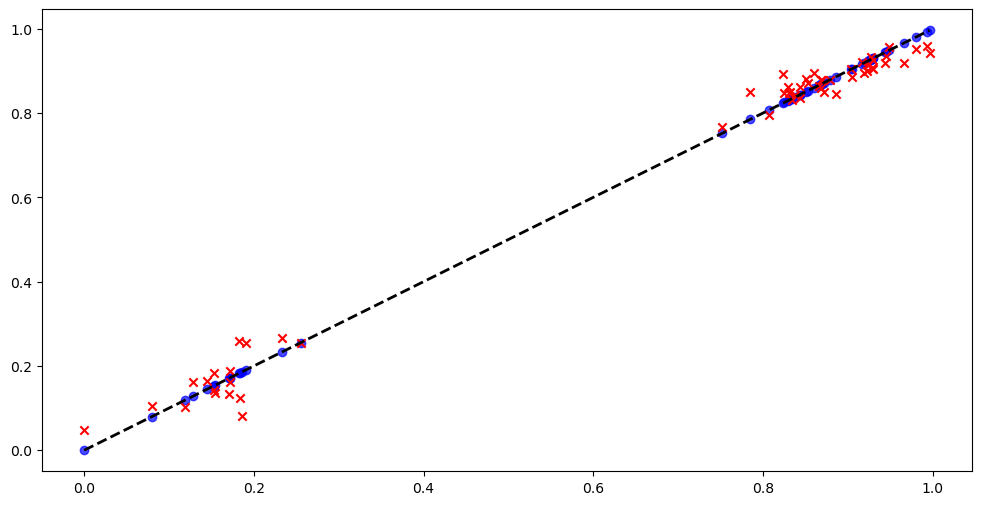

distillate yield (vol%) Validation Metrics:
MAE: 0.024803400002297315
MSE: 0.0010585947853697715
RMSE: 0.03253605362316966
R2: 0.9907187869070381




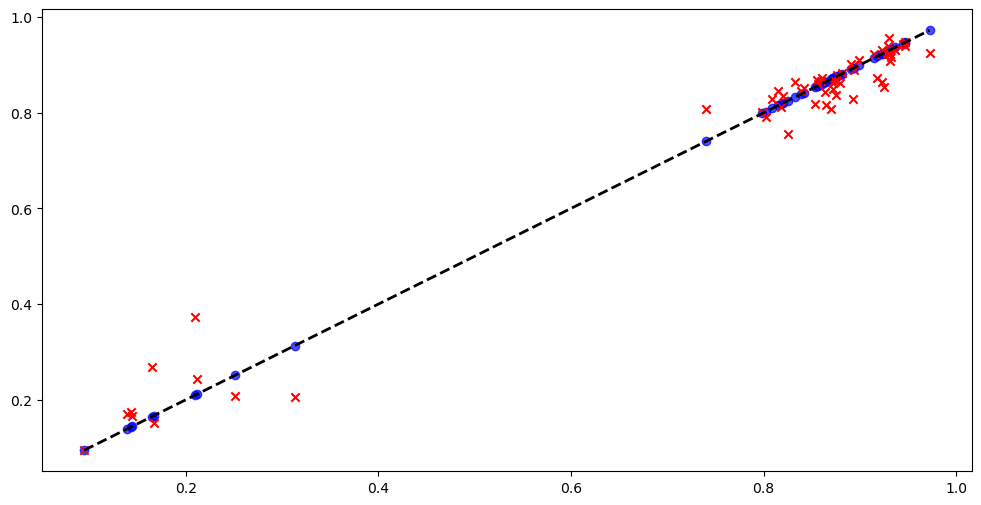

distillate yield (vol%) Test Metrics:
MAE: 0.027246548116616483
MSE: 0.001683360158835036
RMSE: 0.041028772329123324
R2: 0.9765709365145647


Cross-Validation RMSE for naphtha yield (vol%): 0.009059255981140567


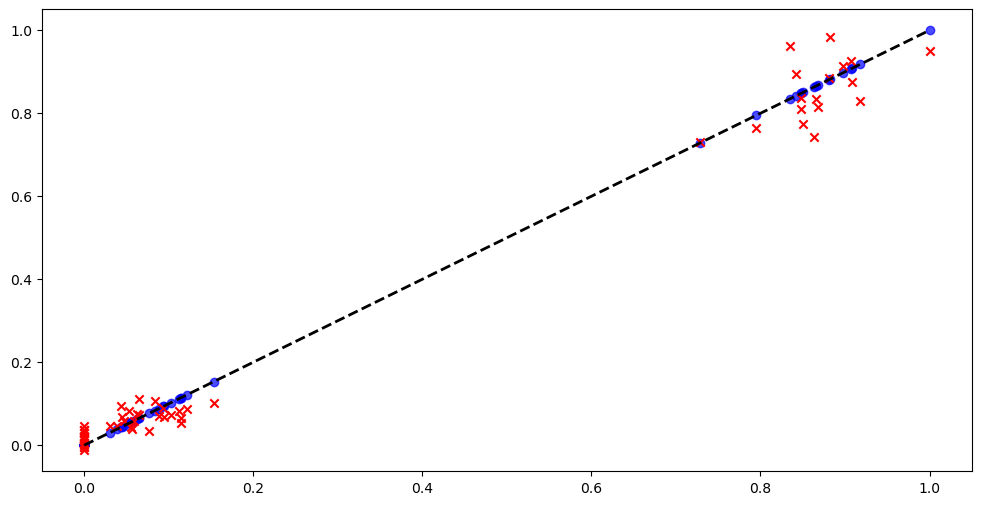

naphtha yield (vol%) Validation Metrics:
MAE: 0.0309052579216873
MSE: 0.0017412232279326325
RMSE: 0.04172796697579014
R2: 0.9879044928463142




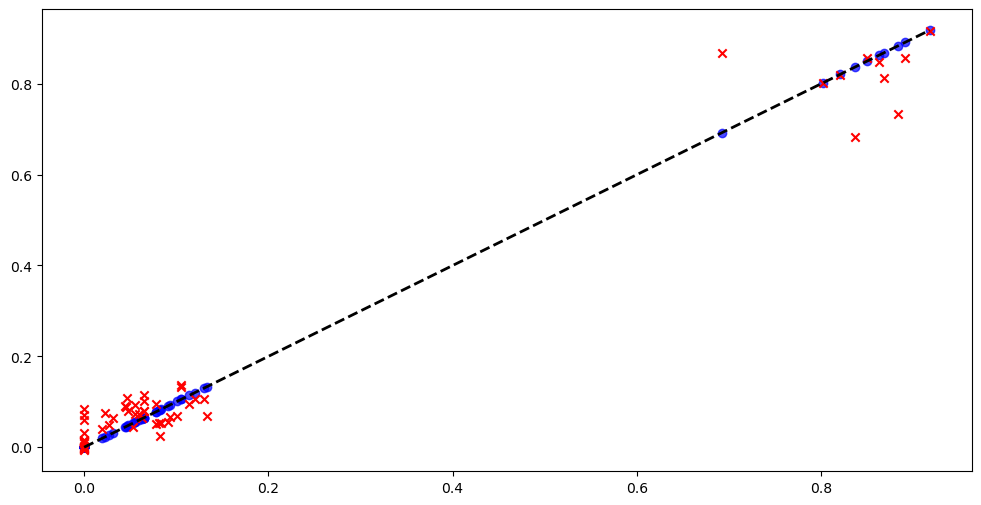

naphtha yield (vol%) Test Metrics:
MAE: 0.032330905312799633
MSE: 0.002321870934010212
RMSE: 0.04818579597775896
R2: 0.9748972238522382


Cross-Validation RMSE for C1 yield (vol%): 0.006456998957132723


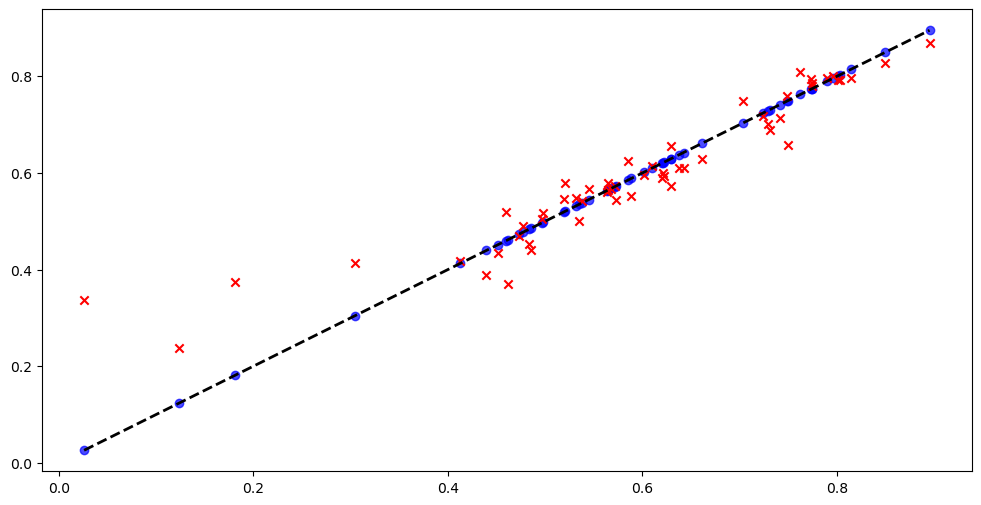

C1 yield (vol%) Validation Metrics:
MAE: 0.036033867555317144
MSE: 0.003757099442060808
RMSE: 0.06129518286179435
R2: 0.8704917549755722




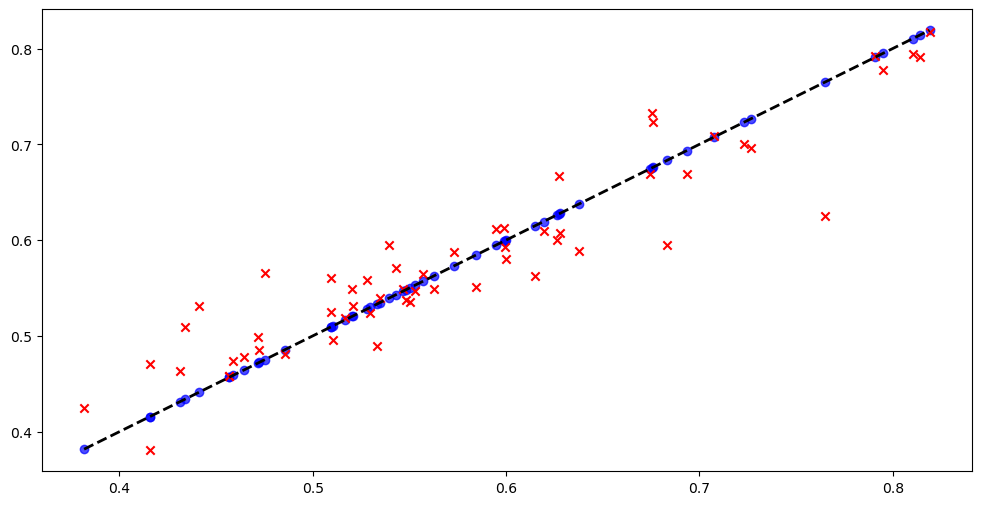

C1 yield (vol%) Test Metrics:
MAE: 0.027924815551055207
MSE: 0.0015165590249705005
RMSE: 0.038943022802172156
R2: 0.8767812120907077


Cross-Validation RMSE for C2 yield (vol%): 0.0053276988938792845


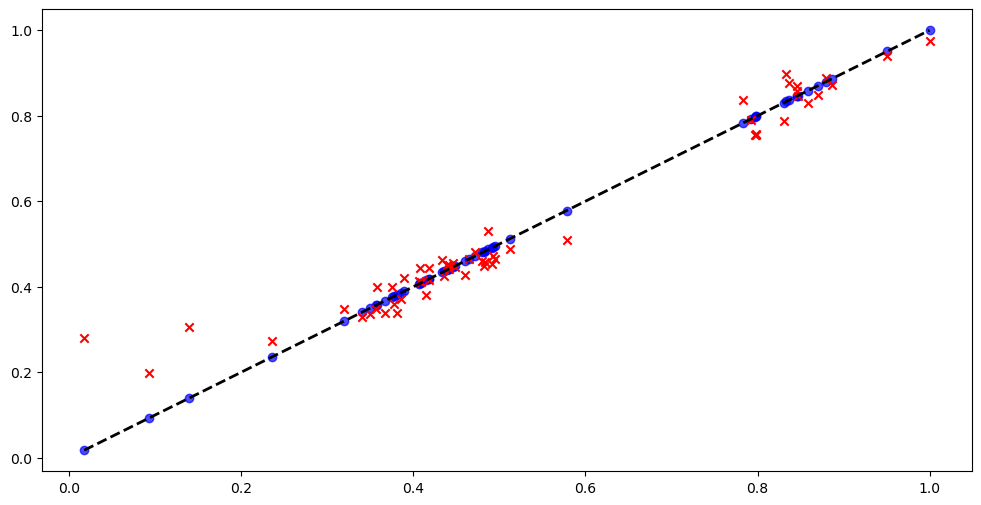

C2 yield (vol%) Validation Metrics:
MAE: 0.03225890824988378
MSE: 0.0026865267753182678
RMSE: 0.05183171592102916
R2: 0.9483245662496784




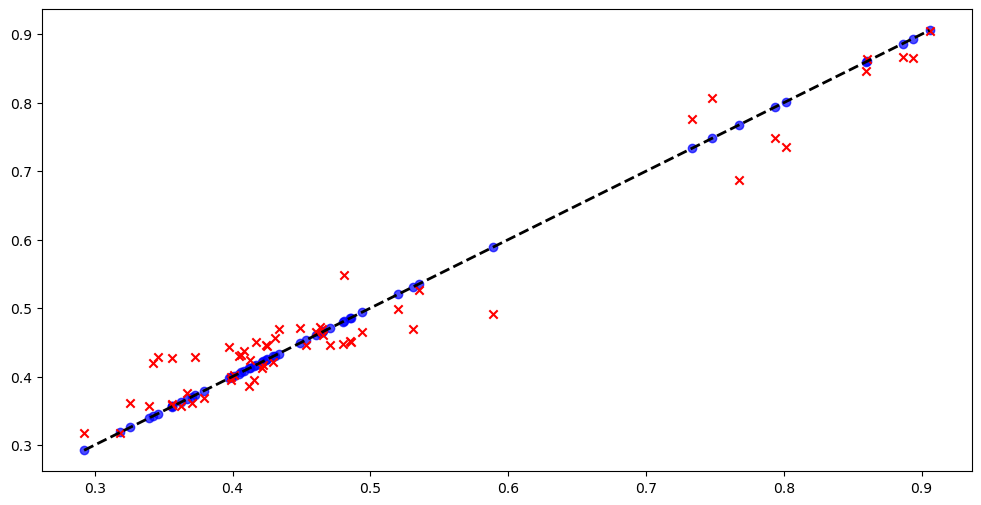

C2 yield (vol%) Test Metrics:
MAE: 0.027233016294228505
MSE: 0.0013254616528457343
RMSE: 0.036406890183669
R2: 0.951042234569181


Cross-Validation RMSE for C3 yield (vol%): 0.005899769389067708


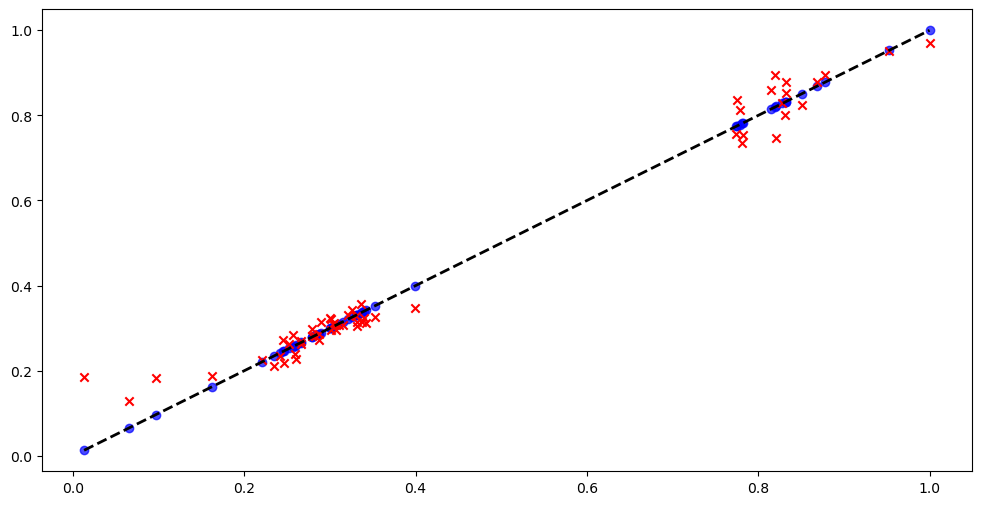

C3 yield (vol%) Validation Metrics:
MAE: 0.026075689067483268
MSE: 0.0014429316774124217
RMSE: 0.03798594052294114
R2: 0.9797165262631757




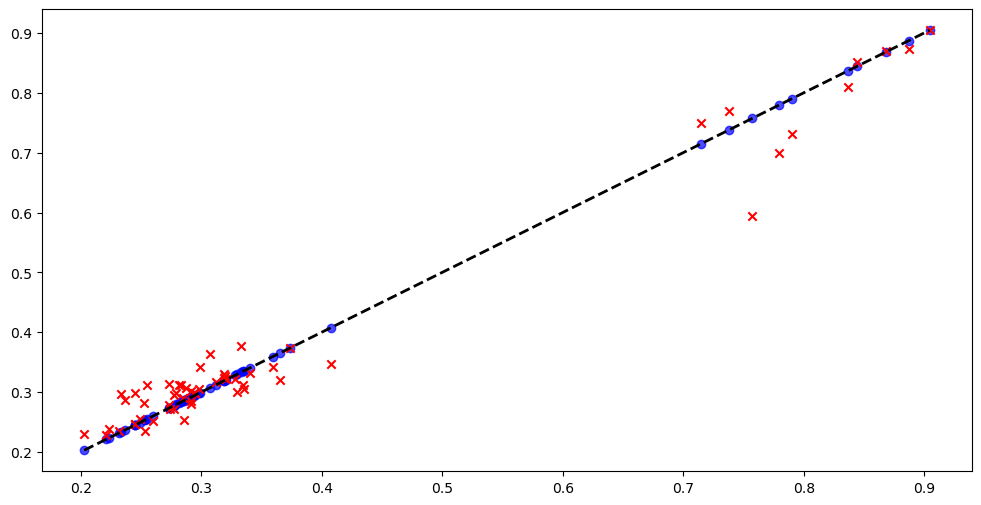

C3 yield (vol%) Test Metrics:
MAE: 0.02417597760256206
MSE: 0.001317307313926586
RMSE: 0.03629472845919344
R2: 0.9679923830838072


Cross-Validation RMSE for C4 yield (vol%): 0.009182142642015579


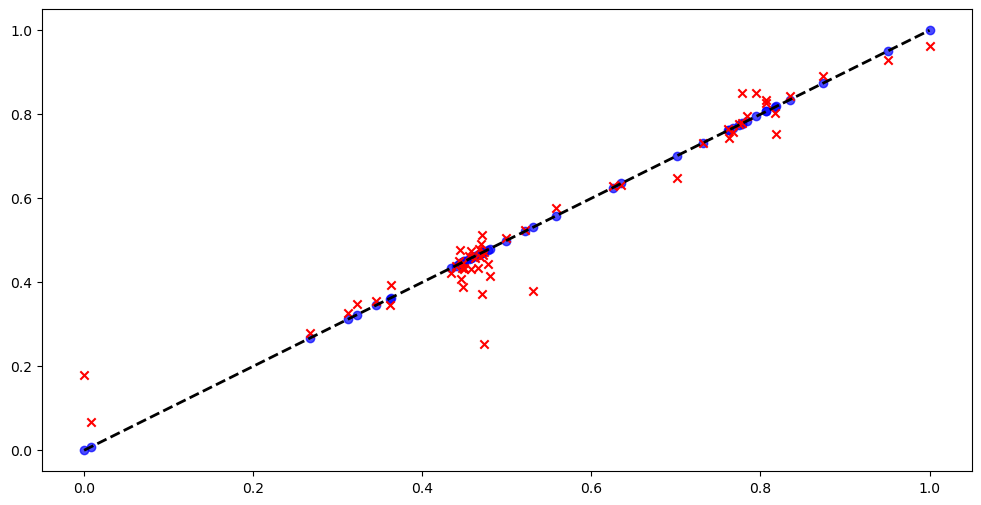

C4 yield (vol%) Validation Metrics:
MAE: 0.031024417611052322
MSE: 0.002728139446158129
RMSE: 0.05223159432908524
R2: 0.9355816159070232




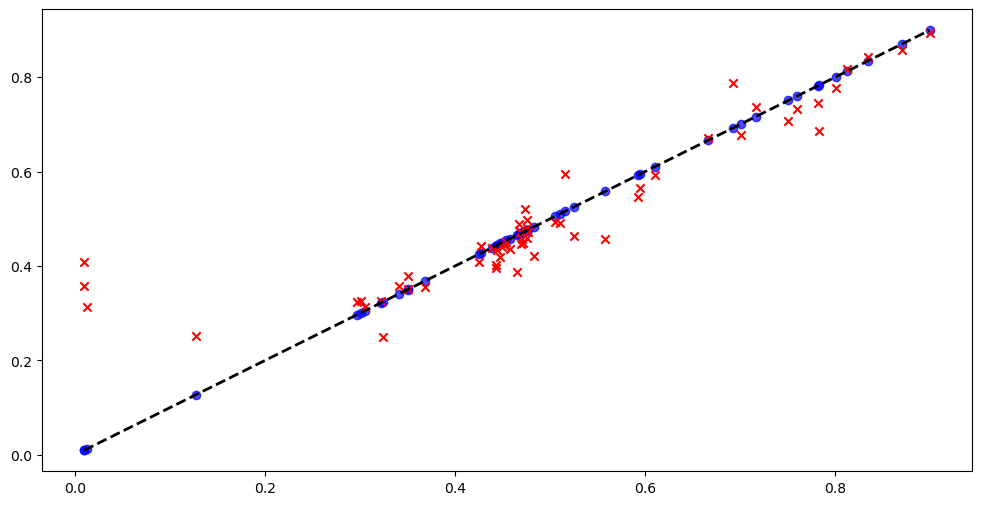

C4 yield (vol%) Test Metrics:
MAE: 0.045955204838734304
MSE: 0.008000115182097206
RMSE: 0.08944336298517183
R2: 0.7931862474252582




In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# Load the dataset
data = mode1_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                   
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=41)

    # Build the CatBoost Regression model
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=41, silent=True)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


## Mode 2

### Decision Tree 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                   
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]
    
    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    # Build the Decision Tree Regression model
    model = DecisionTreeRegressor(random_state=42)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### Xgboost 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Load the dataset
data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    # Build the XGBoost Regression model
    model = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=6, random_state=42)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### Support Vector Regression

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]
    
    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    # Build the SVR model
    model = SVR(kernel='rbf')

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### DNN

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                           
# Prepare the data for training with selected input features
X = data[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
y = data[:, [feature_names.index(feature) for feature in selected_target_feature_names]]

# Normalize the data using MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Split the data into training, validation, and testing sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Build the DNN model
model = keras.Sequential([
    keras.layers.Dense(units=50, activation='tanh', input_dim=X_train.shape[1]),
    keras.layers.Dense(units=50, activation='tanh', input_dim=X_train.shape[1]),
    keras.layers.Dense(units=50, activation='tanh', input_dim=X_train.shape[1]),
    keras.layers.Dense(units=y_scaled.shape[1])  # One output node per target feature
])

model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=1)

# Make predictions on the validation set
val_predictions = model.predict(X_val)

# Plot the results and calculate metrics for the validation set
for i, feature_name in enumerate(selected_target_feature_names):
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val[:, i]), max(y_val[:, i])], [min(y_val[:, i]), max(y_val[:, i])], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val[:, i], y_val[:, i], label=f'Validation Set: True {feature_name}', marker='o', color='blue', alpha=0.7)
    plt.scatter(y_val[:, i], val_predictions[:, i], label=f'Validation Set: Predicted {feature_name}', marker='x', color='red', alpha=0.7)
    '''plt.legend()
    plt.title(f"True and Predicted Values for {feature_name} (Validation Set)")
    plt.xlabel(f'True {feature_name}')
    plt.ylabel(f'Predicted {feature_name}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val[:, i], val_predictions[:, i])
    val_mse = mean_squared_error(y_val[:, i], val_predictions[:, i])
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val[:, i], val_predictions[:, i])

    # Print validation metrics
    print(f"{feature_name} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

# Make predictions on the test set
test_predictions = model.predict(X_test)

# Plot the results and calculate metrics for the test set
for i, feature_name in enumerate(selected_target_feature_names):
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test[:, i]), max(y_test[:, i])], [min(y_test[:, i]), max(y_test[:, i])], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test[:, i], y_test[:, i], label=f'Test Set: True {feature_name}', marker='o', color='blue', alpha=0.7)
    plt.scatter(y_test[:, i], test_predictions[:, i], label=f'Test Set: Predicted {feature_name}', marker='x', color='red', alpha=0.7)
    '''plt.legend()
    plt.title(f"True and Predicted Values for {feature_name} (Test Set)")
    plt.xlabel(f'True {feature_name}')
    plt.ylabel(f'Predicted {feature_name}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test[:, i], test_predictions[:, i])
    test_mse = mean_squared_error(y_test[:, i], test_predictions[:, i])
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test[:, i], test_predictions[:, i])

    # Print test metrics
    print(f"{feature_name} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")

# Plot training loss across epochs
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.title('Training Loss Across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


### Random Forest

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the dataset
data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                                
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]
    
    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    # Build the Random Forest Regression model
    model = RandomForestRegressor(n_estimators=1000, random_state=42)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### LightGBM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor

# Load the dataset
data = mode2_clean.values
feature_names = mode1filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
               
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    # Build the LightGBM Regression model
    model = LGBMRegressor(n_estimators=1000, learning_rate=0.1, random_state=42)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


### Catboost 

Cross-Validation RMSE for distillate yield (vol%): 0.003232439386493916


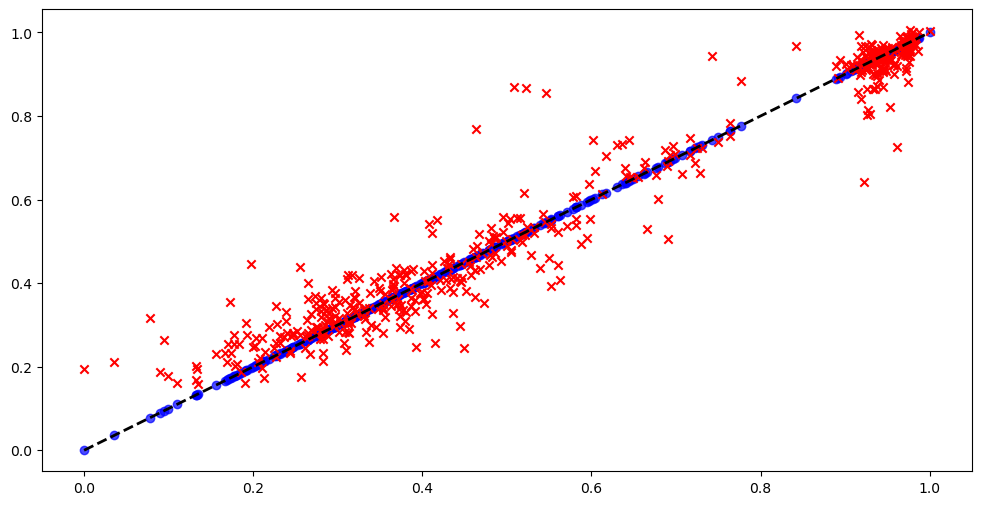

distillate yield (vol%) Validation Metrics:
MAE: 0.040217565011192426
MSE: 0.004043860231630431
RMSE: 0.06359135343449163
R2: 0.9536333678763449




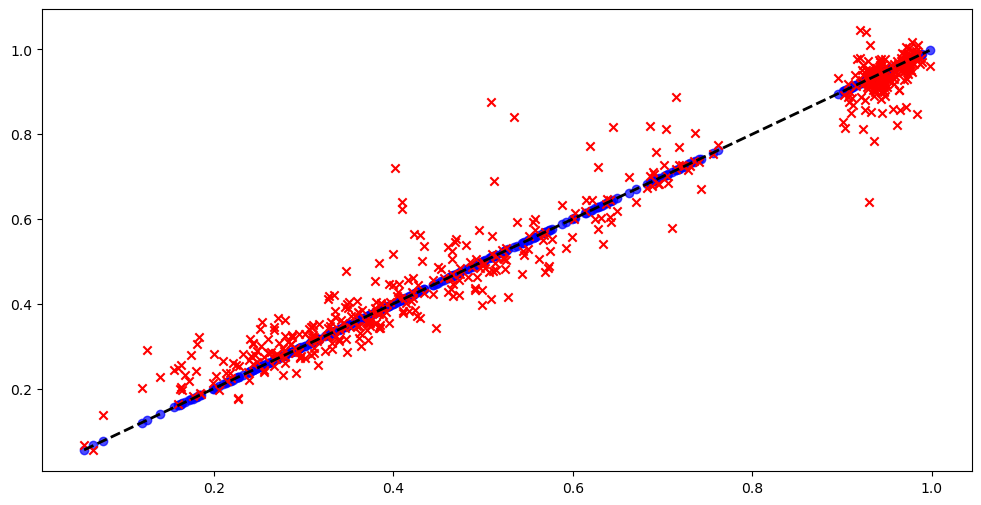

distillate yield (vol%) Test Metrics:
MAE: 0.035285146363261265
MSE: 0.003083697318181235
RMSE: 0.055531048235930455
R2: 0.9632883618569238


Cross-Validation RMSE for naphtha yield (vol%): 0.004348030407563822


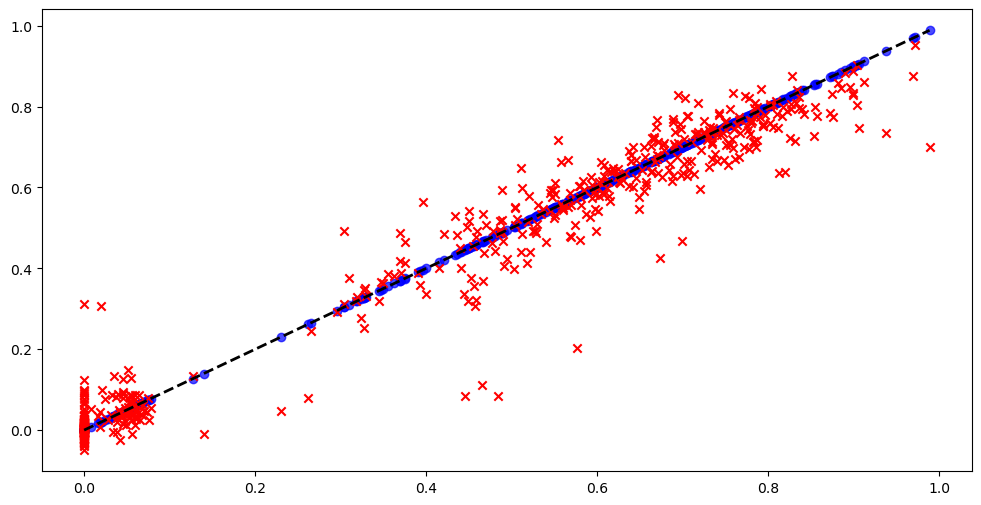

naphtha yield (vol%) Validation Metrics:
MAE: 0.04173034665105453
MSE: 0.004429171390357256
RMSE: 0.06655202018239008
R2: 0.9571384331876093




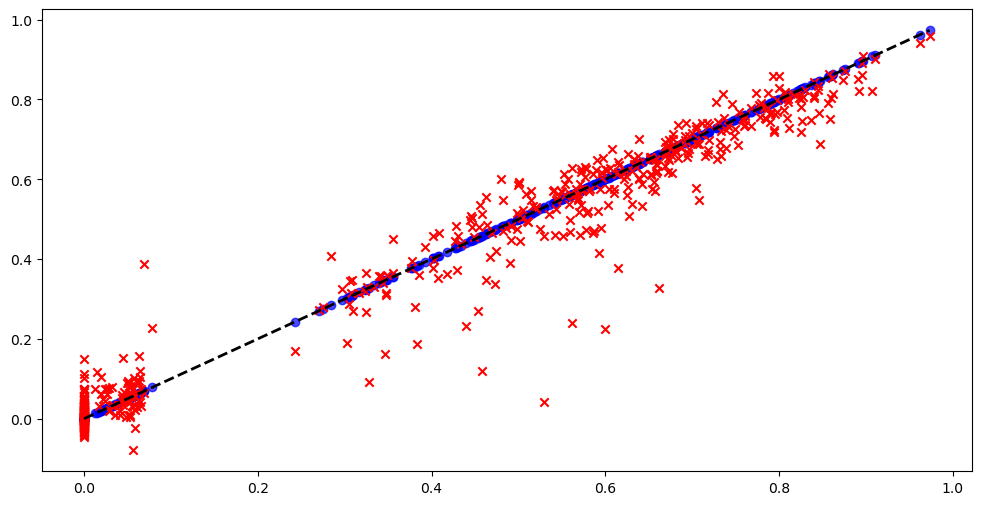

naphtha yield (vol%) Test Metrics:
MAE: 0.03844315979427776
MSE: 0.004044001253180943
RMSE: 0.06359246223555858
R2: 0.9594067812736174


Cross-Validation RMSE for C1 yield (vol%): 0.0009059984934941817


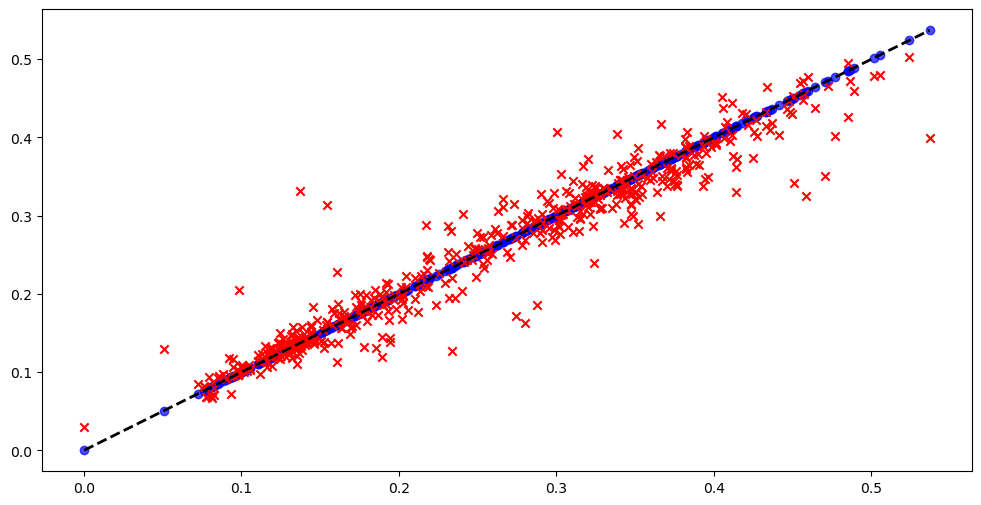

C1 yield (vol%) Validation Metrics:
MAE: 0.017756298490701258
MSE: 0.0008226141391834764
RMSE: 0.02868125065584617
R2: 0.9329346917210175




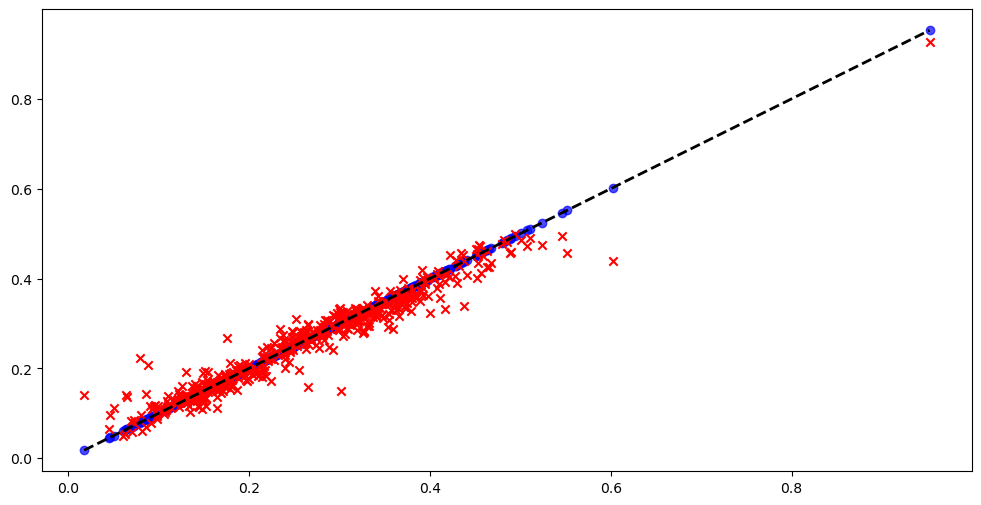

C1 yield (vol%) Test Metrics:
MAE: 0.017321493914682434
MSE: 0.0006980271053959731
RMSE: 0.026420202599449785
R2: 0.9469055223293477


Cross-Validation RMSE for C2 yield (vol%): 0.0014396558682324592


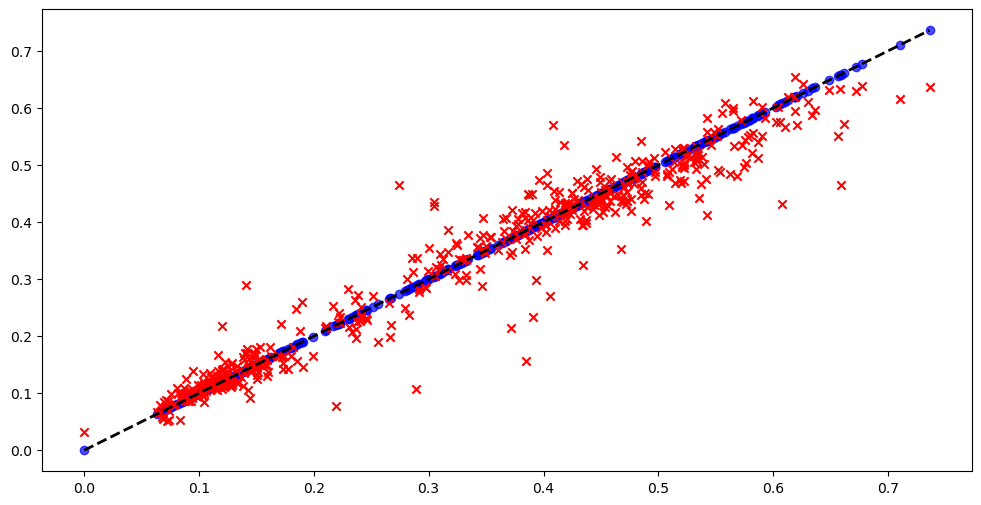

C2 yield (vol%) Validation Metrics:
MAE: 0.02520956422175214
MSE: 0.0015961715645329843
RMSE: 0.03995211589556909
R2: 0.9479957817548016




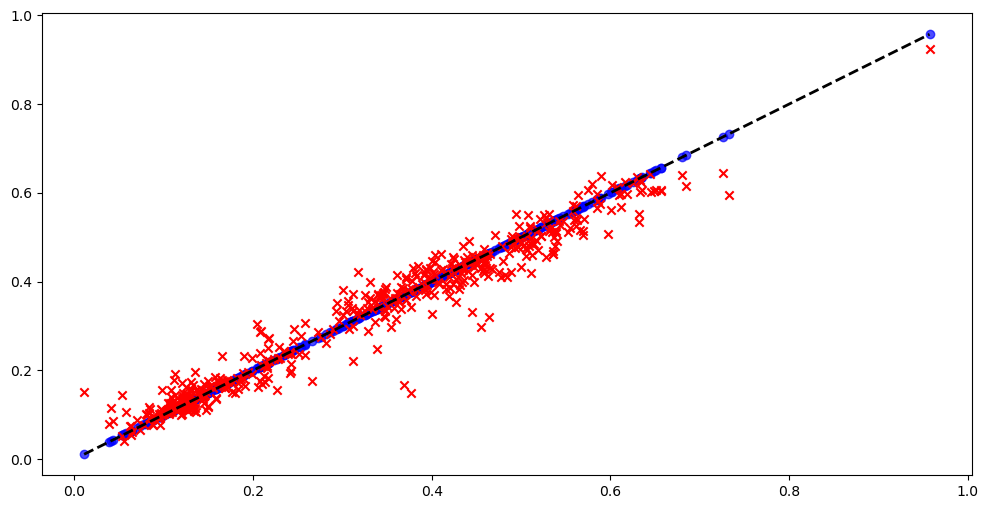

C2 yield (vol%) Test Metrics:
MAE: 0.024242927995526062
MSE: 0.0012870949428549778
RMSE: 0.035876105458298814
R2: 0.9578899451824832


Cross-Validation RMSE for C3 yield (vol%): 0.0021438132280496994


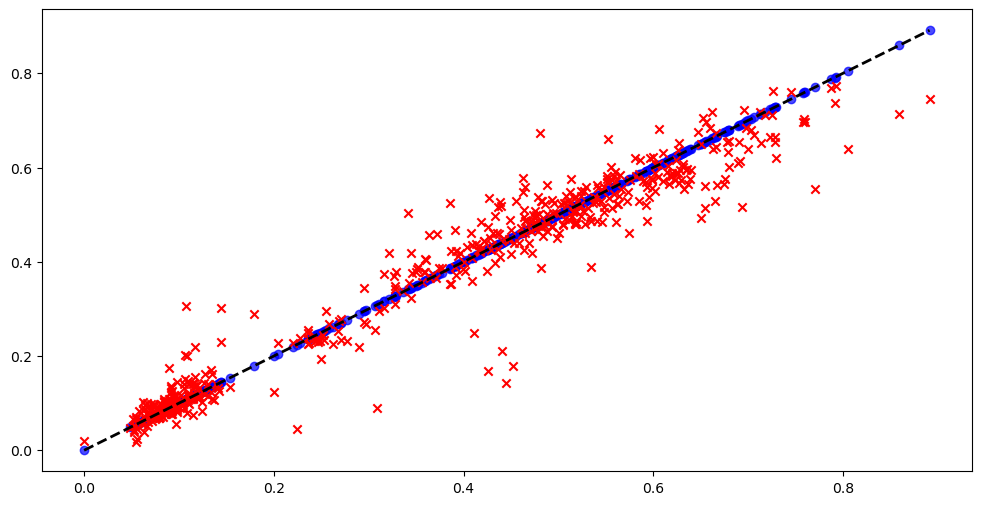

C3 yield (vol%) Validation Metrics:
MAE: 0.03253905743007206
MSE: 0.0026998453522602867
RMSE: 0.05196003610718806
R2: 0.9459375161649819




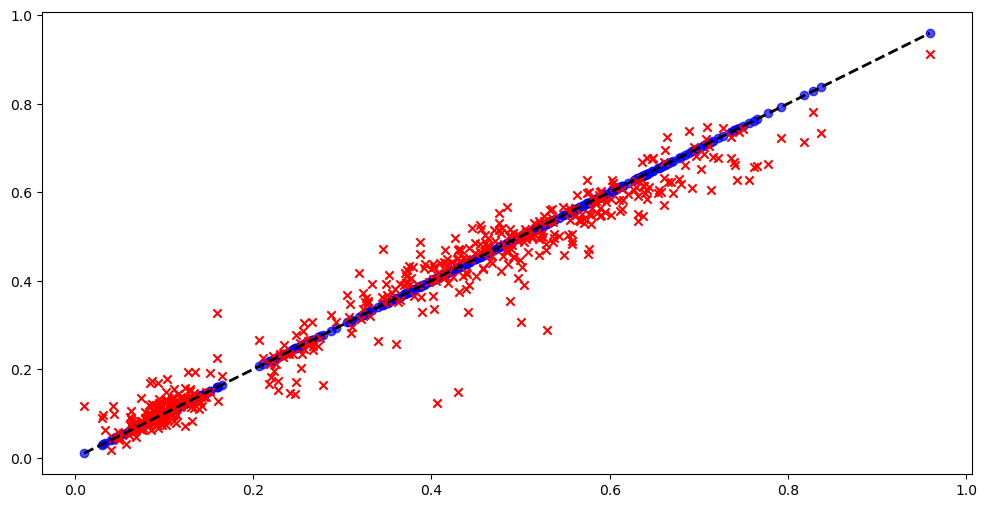

C3 yield (vol%) Test Metrics:
MAE: 0.029992221462726357
MSE: 0.0020352818337571518
RMSE: 0.04511409794905747
R2: 0.9582795768796227


Cross-Validation RMSE for C4 yield (vol%): 0.0023253104986906735


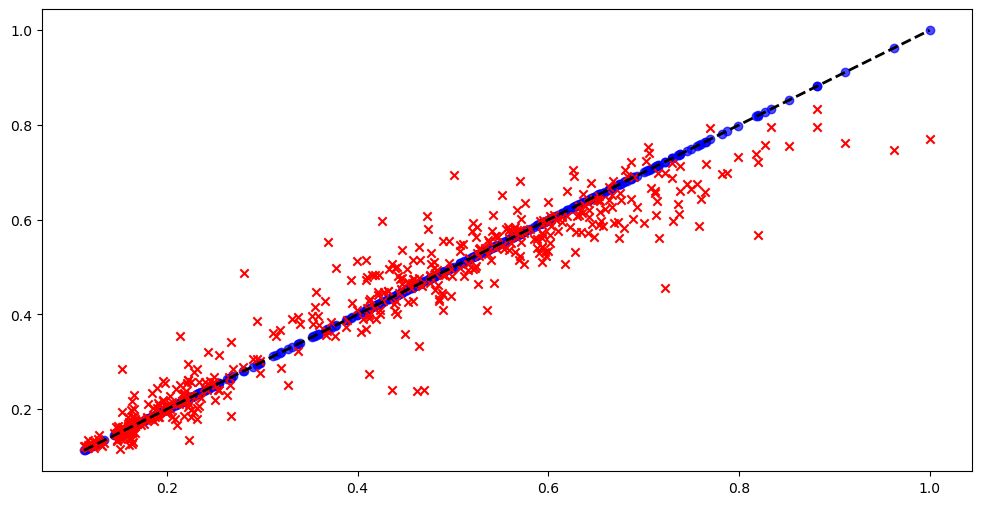

C4 yield (vol%) Validation Metrics:
MAE: 0.03405680884131299
MSE: 0.002875394747520855
RMSE: 0.053622707387084204
R2: 0.9342827389723937




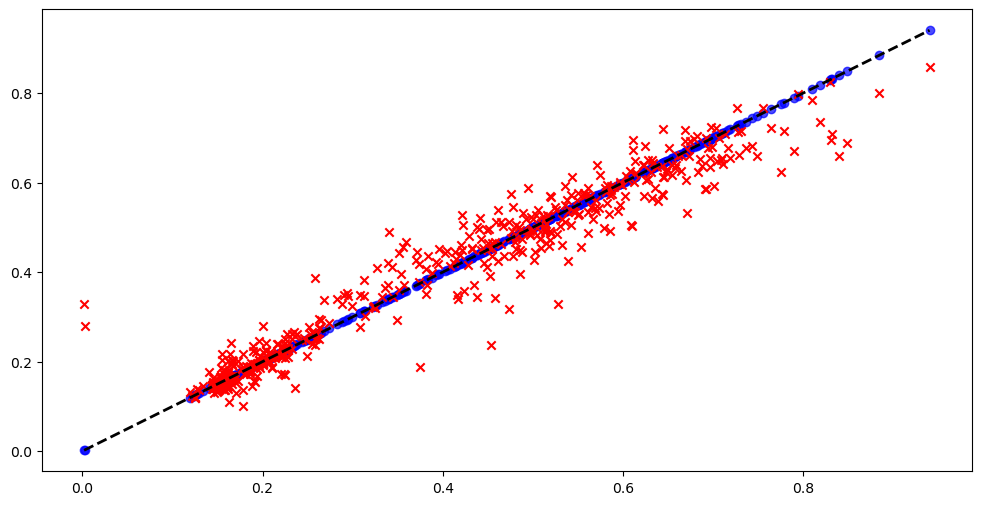

C4 yield (vol%) Test Metrics:
MAE: 0.030608366547153973
MSE: 0.0023032278939686206
RMSE: 0.047991956554912625
R2: 0.944548241305339




In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# Load the dataset
data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                   
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data_normalized[:, [feature_names.index(feature) for feature in selected_input_feature_names]]
    y = data_normalized[:, feature_names.index(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    # Build the CatBoost Regression model
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=42, silent=True)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_val, y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_val, val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(y_test, y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(y_test, test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


# Model Explainability

## Mode 2 Surrogate Catboost Model

Cross-Validation RMSE for distillate yield (vol%): 9.380198848263679e-05


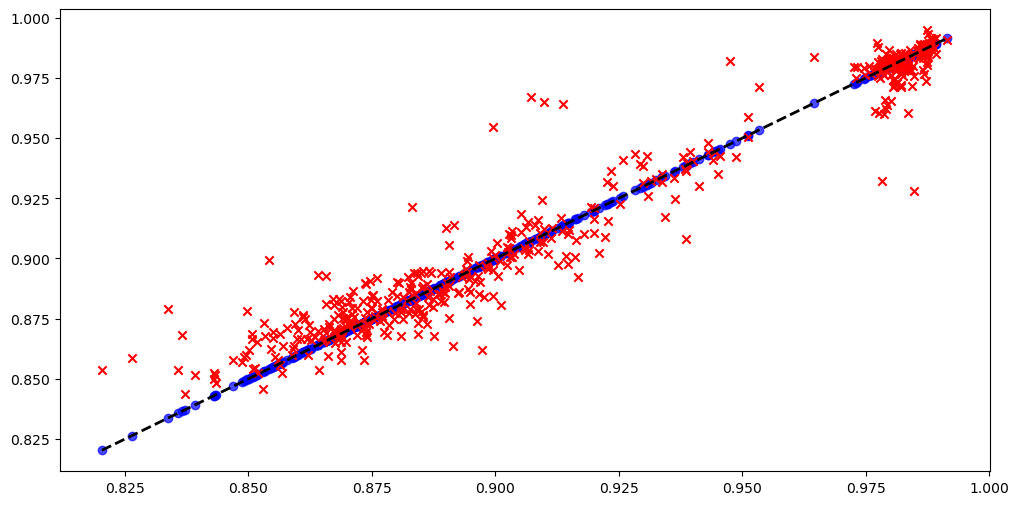

distillate yield (vol%) Validation Metrics:
MAE: 0.006734852095909439
MSE: 0.00011662735785168987
RMSE: 0.01079941469949598
R2: 0.9544007337373146




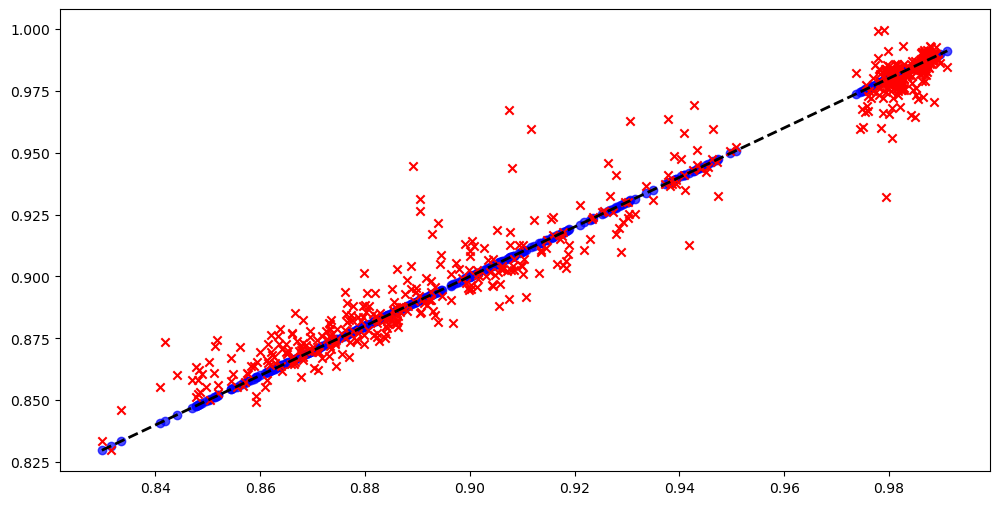

distillate yield (vol%) Test Metrics:
MAE: 0.006048546467628474
MSE: 8.851871980871755e-05
RMSE: 0.00940843875511328
R2: 0.9640652069825315


Cross-Validation RMSE for naphtha yield (vol%): 4.651010367186476e-05


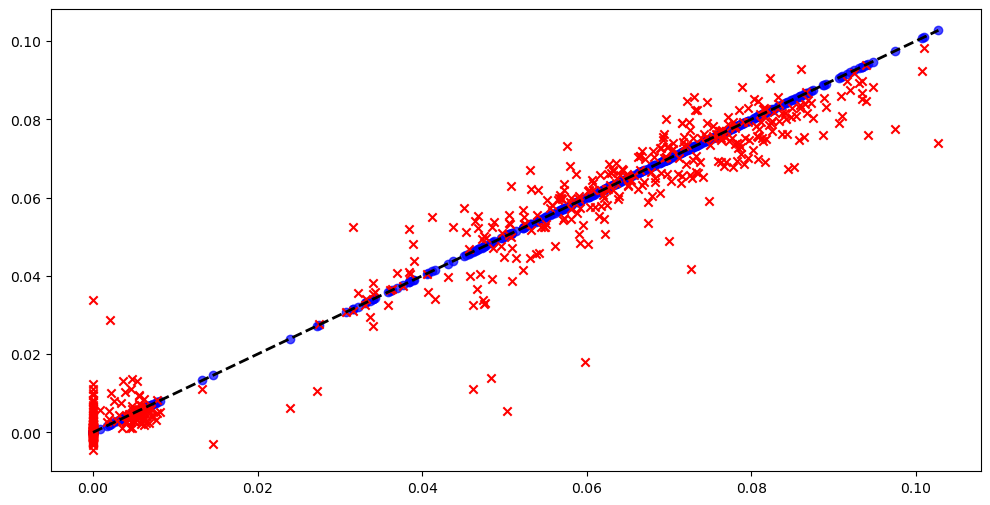

naphtha yield (vol%) Validation Metrics:
MAE: 0.004340381455726959
MSE: 4.858671127190874e-05
RMSE: 0.006970416865002318
R2: 0.9564655554507046




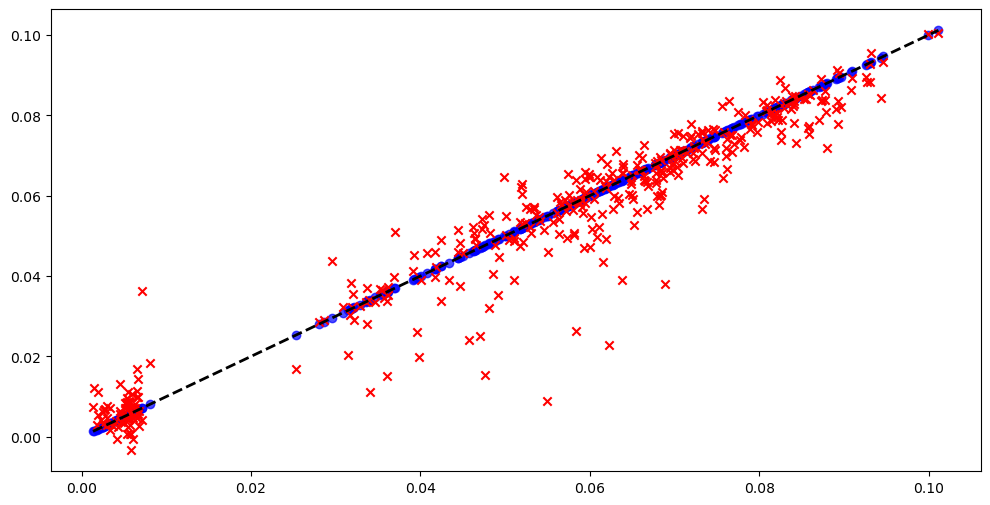

naphtha yield (vol%) Test Metrics:
MAE: 0.0039931253229650914
MSE: 4.243659058944467e-05
RMSE: 0.0065143373100757275
R2: 0.960558571169443


Cross-Validation RMSE for C1 yield (vol%): 6.48029592624665e-08


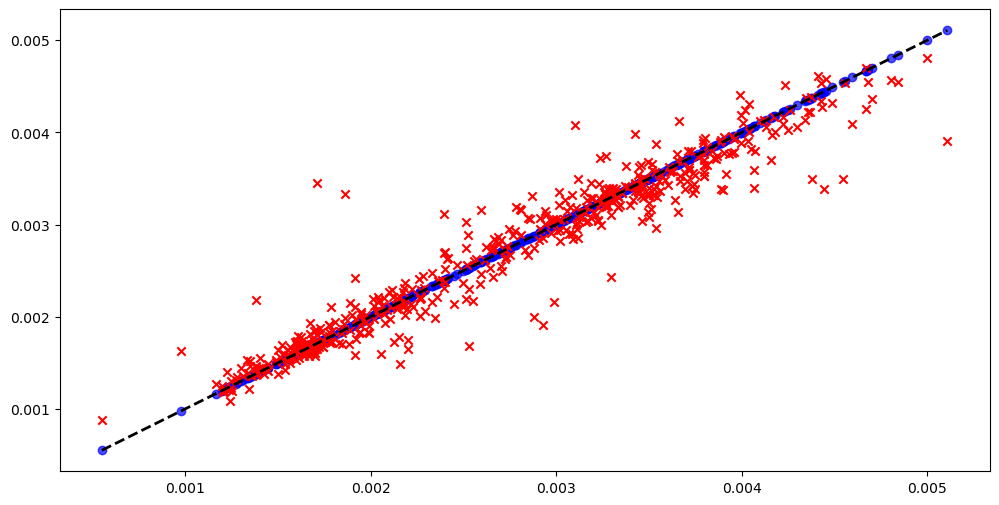

C1 yield (vol%) Validation Metrics:
MAE: 0.00015436808900443248
MSE: 6.166269315991333e-08
RMSE: 0.000248319739770952
R2: 0.9303000445098362




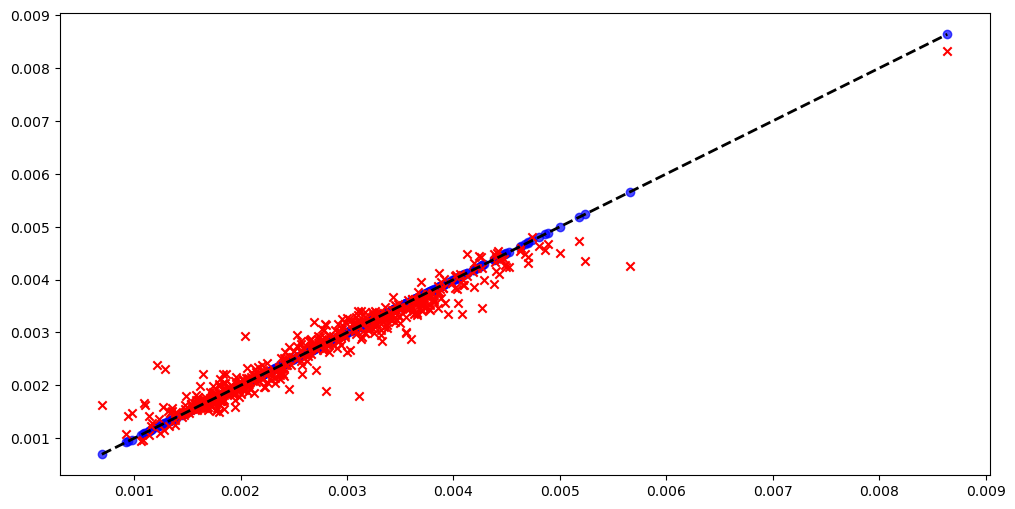

C1 yield (vol%) Test Metrics:
MAE: 0.00014688894635120462
MSE: 5.067292664060223e-08
RMSE: 0.0002251064784509816
R2: 0.9465606324196979


Cross-Validation RMSE for C2 yield (vol%): 2.6206938892279996e-07


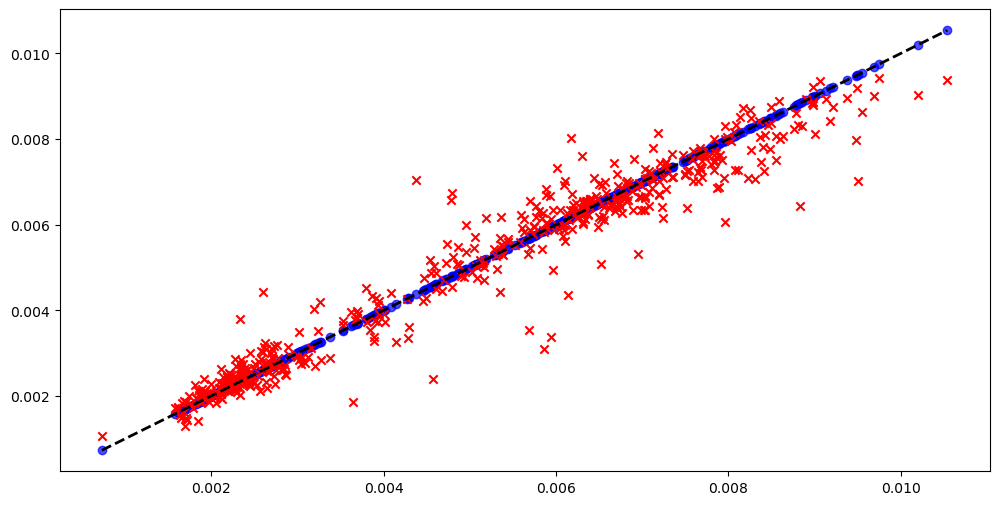

C2 yield (vol%) Validation Metrics:
MAE: 0.0003409737518924484
MSE: 2.8553652179670456e-07
RMSE: 0.0005343561750337546
R2: 0.9476437313289346




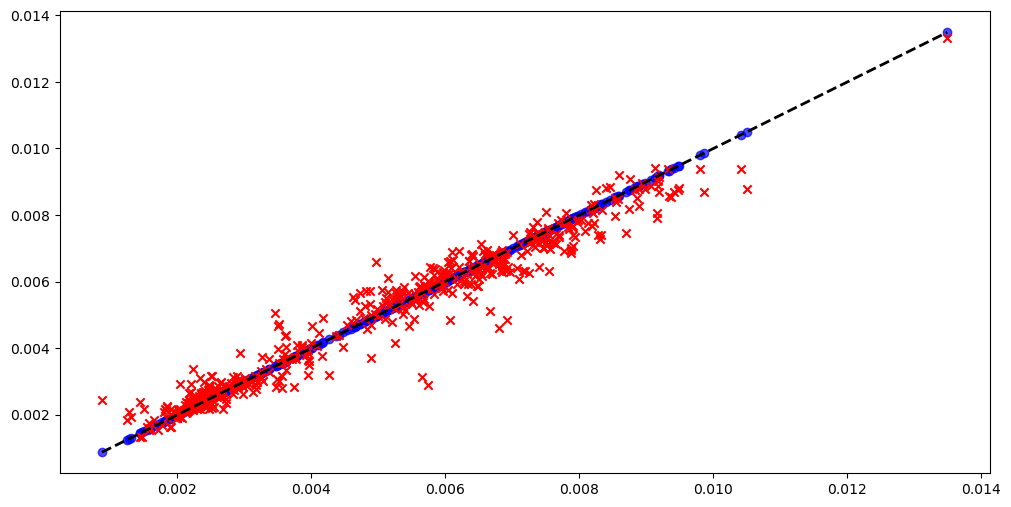

C2 yield (vol%) Test Metrics:
MAE: 0.0003215648284043192
MSE: 2.2932454978395226e-07
RMSE: 0.00047887842902343415
R2: 0.9577745980296422


Cross-Validation RMSE for C3 yield (vol%): 2.667282231466349e-06


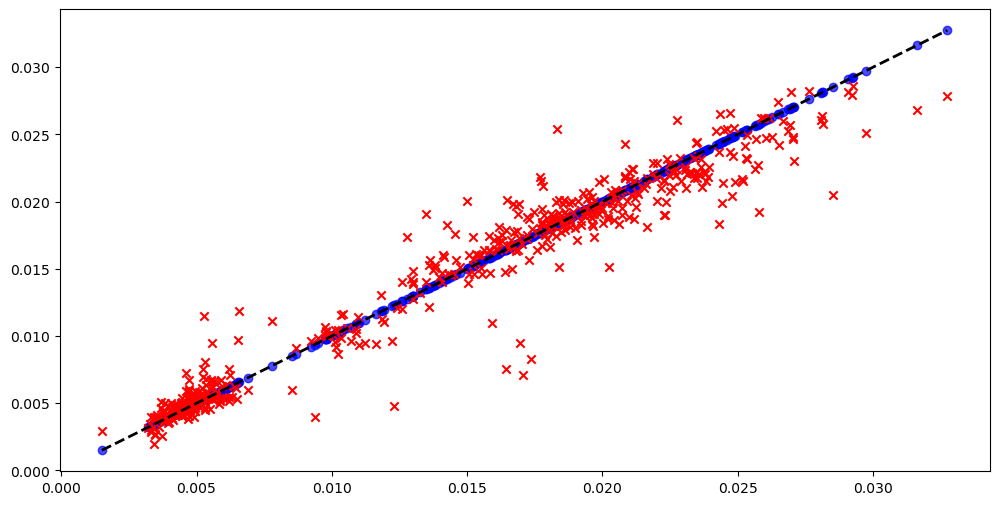

C3 yield (vol%) Validation Metrics:
MAE: 0.001120350201245808
MSE: 3.1632825119339953e-06
RMSE: 0.0017785619224345256
R2: 0.9484866351949794




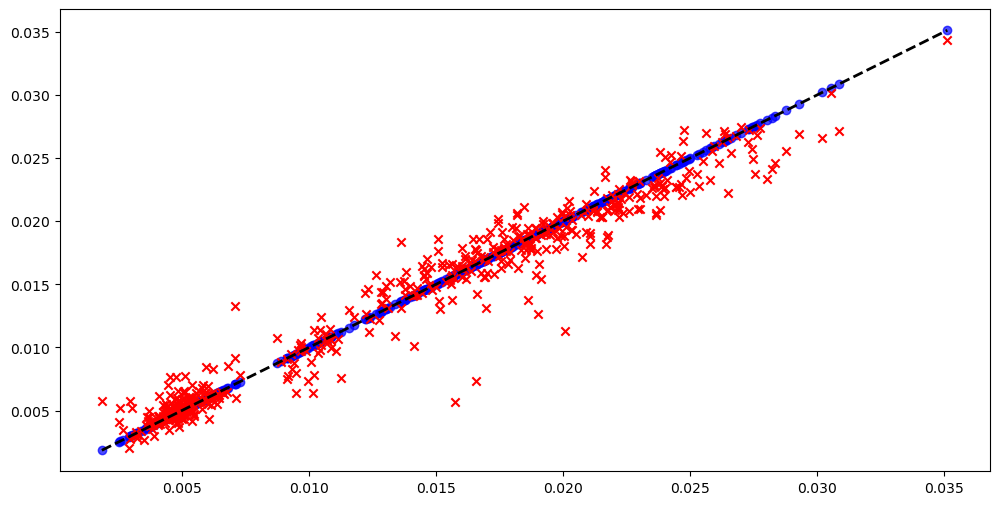

C3 yield (vol%) Test Metrics:
MAE: 0.0010226362678060858
MSE: 2.436458480792051e-06
RMSE: 0.0015609159108651723
R2: 0.9593829858095766


Cross-Validation RMSE for C4 yield (vol%): 2.6568797186924853e-06


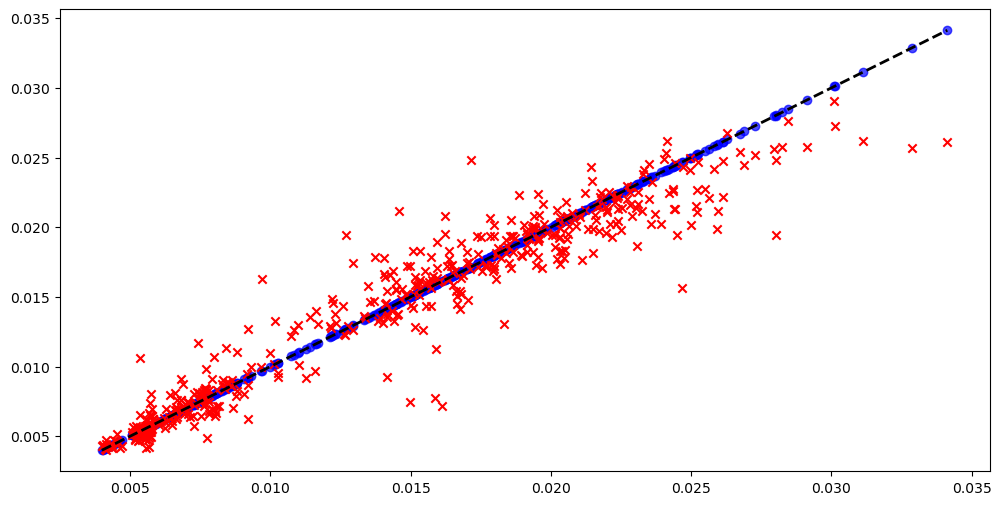

C4 yield (vol%) Validation Metrics:
MAE: 0.0011615076709768427
MSE: 3.4804043599914097e-06
RMSE: 0.00186558418732348
R2: 0.9311095121939846




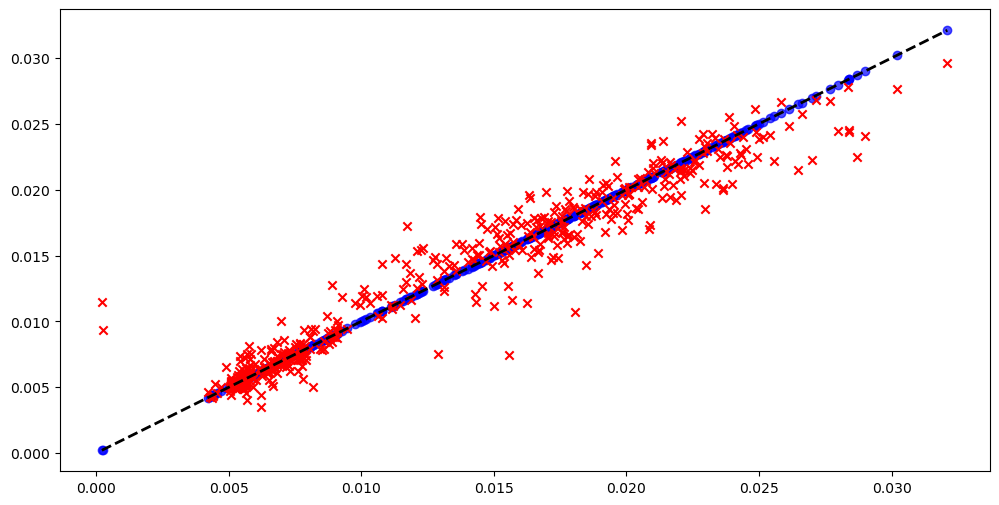

C4 yield (vol%) Test Metrics:
MAE: 0.001056185912506838
MSE: 2.7211715280725746e-06
RMSE: 0.0016495973836280701
R2: 0.9432609698832715




In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# Load the dataset
data = mode2_clean.values
feature_names = mode2filled.columns.tolist()

# Choose the features you want to use as inputs
selected_input_feature_names = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Choose the target features
selected_target_feature_names = ['distillate yield (vol%)','naphtha yield (vol%)','C1 yield (vol%)','C2 yield (vol%)','C3 yield (vol%)','C4 yield (vol%)']
                   
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(mode2filled)

# Initialize a dictionary to store predictions, metrics, and trained models for each target feature
predictions_dict = {}
metrics_dict = {}
models_dict = {}

# Loop through each target feature
for selected_feature_for_regression in selected_target_feature_names:
    # Extract the selected feature for regression
    X = data[:, [mode2filled.columns.get_loc(feature) for feature in selected_input_feature_names]]
    y = data[:, mode2filled.columns.get_loc(selected_feature_for_regression)]

    # Split the data into training, validation, and testing sets (60-20-20 split)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    # Build the CatBoost Regression model
    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=42, silent=True)

    # Train the model using cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation RMSE for {selected_feature_for_regression}: {-scores.mean()}")

    # Train the model
    model.fit(X_train, y_train)

    # Save the trained model with the specified name
    models_dict[f"model_{selected_feature_for_regression.replace(' ', '_')}"] = model

    # Make predictions on validation set
    val_predictions = model.predict(X_val)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression] = val_predictions

    # Filter out values higher than 1 for plotting
    valid_idx = y_val <= 1
    filtered_y_val = y_val[valid_idx]
    filtered_val_predictions = val_predictions[valid_idx]

    # Plot the results and calculate metrics for the validation set
    plt.figure(figsize=(12, 6))
    plt.plot([min(filtered_y_val), max(filtered_y_val)], [min(filtered_y_val), max(filtered_y_val)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(filtered_y_val, filtered_y_val, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(filtered_y_val, filtered_val_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Validation Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the validation set
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_mse = mean_squared_error(y_val, val_predictions)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, val_predictions)

    # Store validation metrics in the dictionary
    metrics_dict[f"Validation_{selected_feature_for_regression}"] = {'MAE': val_mae, 'MSE': val_mse, 'RMSE': val_rmse, 'R2': val_r2}

    # Print validation metrics
    print(f"{selected_feature_for_regression} Validation Metrics:")
    print(f"MAE: {val_mae}")
    print(f"MSE: {val_mse}")
    print(f"RMSE: {val_rmse}")
    print(f"R2: {val_r2}")
    print("\n")

    # Make predictions on test set
    test_predictions = model.predict(X_test)

    # Store predictions in the dictionary
    predictions_dict[selected_feature_for_regression + "_test"] = test_predictions

    # Filter out values higher than 1 for plotting
    valid_idx_test = y_test > 0
    filtered_y_test = y_test[valid_idx_test]
    filtered_test_predictions = test_predictions[valid_idx_test]

    # Plot the results and calculate metrics for the test set
    plt.figure(figsize=(12, 6))
    plt.plot([min(filtered_y_test), max(filtered_y_test)], [min(filtered_y_test), max(filtered_y_test)], color='black', linestyle='--', linewidth=2, label='x=y line')
    plt.scatter(filtered_y_test, filtered_y_test, label='True Values', color='blue', marker='o', alpha=0.7)
    plt.scatter(filtered_y_test, filtered_test_predictions, label='Predicted Values', color='red', marker='x')
    '''plt.legend()
    plt.title(f"True and Predicted Values for {selected_feature_for_regression} (Test Set)")
    plt.xlabel(f'True {selected_feature_for_regression}')
    plt.ylabel(f'Predicted {selected_feature_for_regression}')'''
    plt.show()

    # Calculate metrics for the test set
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_predictions)

    # Store test metrics in the dictionary
    metrics_dict[f"Test_{selected_feature_for_regression}"] = {'MAE': test_mae, 'MSE': test_mse, 'RMSE': test_rmse, 'R2': test_r2}

    # Print test metrics
    print(f"{selected_feature_for_regression} Test Metrics:")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print(f"R2: {test_r2}")
    print("\n")


## SHAP Plots

In [ ]:
import shap

# Extract the 'diesel yield' model from the models dictionary
distillate_model = models_dict['model_distillate_yield_(vol%)']

# Extract the selected features used for training the model
#X_diesel = data[:, [feature_names.index(feature) for feature in selected_input_feature_names]]

# Initialize the SHAP explainer
explainer = shap.Explainer(distillate_model, X_train)

# Calculate SHAP values
shap_values = explainer.shap_values(X_train)

# Plot the SHAP summary plot
shap.summary_plot(shap_values, X_train, feature_names=selected_input_feature_names, show=False)

# Show the plot
plt.title('SHAP Summary Plot for Distillate Yield Model')
plt.show()


In [ ]:
# Convert SHAP values to a DataFrame for analysis
shap_values_df = pd.DataFrame(shap_values)
shap_values_df.columns = ['feed 1 sulfur concentration (ppm)','feed 1 specific density (g/cm3)','feed 1 viscosity index','feed 1 cloud point index','feed 1 to reactor 1 flowrate (BPH)','feed 1 to reactor 2 flowrate (BPH)','feed 1 and 2 sulfur concentration (ppm)','feed 1 and 2 specific density (g/cm3)',
                'feed 1 and 2 cloud point index','feed 2 to reactor 1 flowrate (BPH)','feed 2 to reactor 2 flowrate (BPH)','feed 3 sulfur concentration (ppm)','feed 3 specific density (g/cm3)','feed 3 cloud point index','feed 3 to reactor 1 flowrate (BPH)','feed 3 to reactor 2 flowrate (BPH)'
                ,'total Hydrogen in (KSCFH)','total Hydrogen out (KSCFH)','reactor 1 temperature (°F)','reactor 2 temperature (°F)','Hydrogen Consumption (SCF/BBL)']

# Calculate the mean absolute SHAP value for each feature
mean_abs_shap = shap_values_df.abs().mean().sort_values(ascending=False)
print(mean_abs_shap)

# To visualize
mean_abs_shap.plot(kind='bar')
plt.xlabel('Feature')
plt.ylabel('Mean Absolute SHAP Value')
plt.title('Feature Importance by Mean Absolute SHAP Value')
plt.show()

## LIME Plots

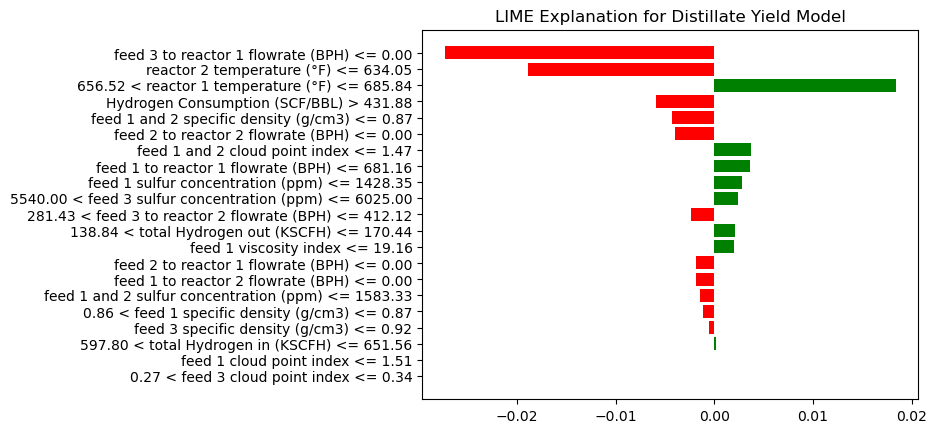

In [38]:
#LIME for instance 1 for the first scenario of optimization
import lime
import lime.lime_tabular

# Extract the 'diesel yield' model from the models dictionary
distillate_model = models_dict['model_distillate_yield_(vol%)']


# Initialize the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train, mode='regression', feature_names=selected_input_feature_names)

# Choose a specific instance for explanation (e.g., the first instance in the test set)
instance = X[150]

# Generate explanations for the instance
explanation = explainer.explain_instance(instance, distillate_model.predict, num_features=len(selected_input_feature_names))

# Plot the LIME explanation
explanation.as_pyplot_figure()
plt.title('LIME Explanation for Distillate Yield Model')
plt.show()


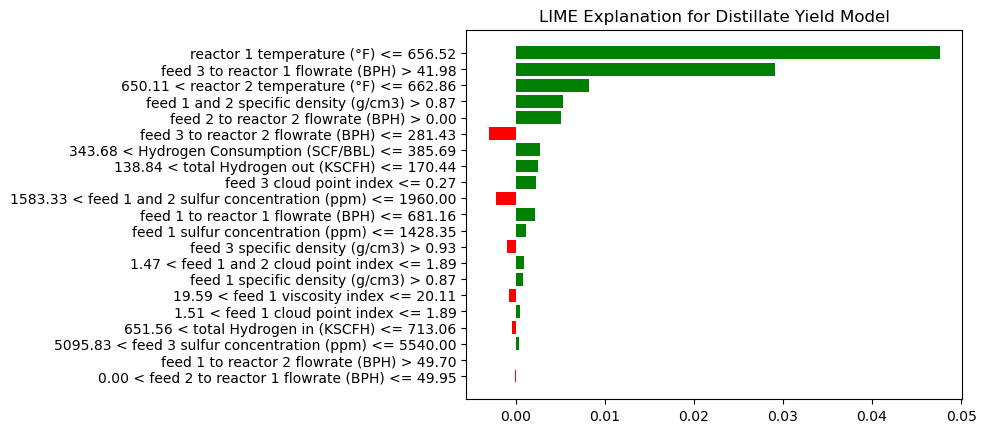

In [240]:
#LIME for instance 2 for the second scenario of optimization
import lime.lime_tabular

# Extract the 'diesel yield' model from the models dictionary
distillate_model = models_dict['model_distillate_yield_(vol%)']


# Initialize the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train, mode='regression', feature_names=selected_input_feature_names)

# Choose a specific instance for explanation (e.g., the first instance in the test set)
instance = X[50]

# Generate explanations for the instance
explanation = explainer.explain_instance(instance, distillate_model.predict, num_features=len(selected_input_feature_names))

# Plot the LIME explanation
explanation.as_pyplot_figure()
plt.title('LIME Explanation for Distillate Yield Model')
plt.show()


# Multi-objective Optimization

In [52]:
distillate_model = models_dict['model_distillate_yield_(vol%)']
naphtha_model = models_dict['model_naphtha_yield_(vol%)']
C1_model = models_dict['model_C1_yield_(vol%)']
C2_model = models_dict['model_C2_yield_(vol%)']
C3_model = models_dict['model_C3_yield_(vol%)']
C4_model = models_dict['model_C4_yield_(vol%)']

In [53]:
import pandas as pd
from pandas import set_option
from pandas import DataFrame

import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import RandomForestRegressor

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import Problem
from pymoo.problems.functional import FunctionalProblem
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.core.termination import Termination
from pymoo.visualization.scatter import Scatter
import warnings
from sklearn.exceptions import ConvergenceWarning


## Scenario 1: Maximizing Distillate Yield under Low-Yield Conditions

In [128]:
class OptimizationProblem(Problem):
    def __init__(self, x_min, x_max, distillate_model, naphtha_model, C1_model, C2_model, C3_model ,C4_model):
        super().__init__(n_var=len(x_min), n_obj=6, n_ieq_constr=0, n_eq_constr=1, xl=x_min, xu=x_max)
        self.model_distillate = distillate_model
        self.model_naphtha = naphtha_model
        self.model_C1 = C1_model
        self.model_C2 = C2_model
        self.model_C3 = C3_model
        self.model_C4 = C4_model

    def _evaluate(self, X, out, *args, **kwargs):
        df = pd.DataFrame(list(X))
        
        # Predict yields using the respective models
        distillate_yield =  self.model_distillate.predict(df)
        naphtha_yield =  self.model_naphtha.predict(df)
        C1_yield = self.model_C1.predict(df)
        C2_yield = self.model_C2.predict(df)
        C3_yield = self.model_C3.predict(df)
        C4_yield = self.model_C4.predict(df)
    
        
        #Constraints
        Constraint1 =  distillate_yield + naphtha_yield + C1_yield + C2_yield + C3_yield+ C4_yield- 1
        

        # Set the objectives
        out['F'] = np.column_stack([-distillate_yield, naphtha_yield, C1_yield, C2_yield, C3_yield, C4_yield ])
        out['H'] = np.column_stack([Constraint1])

In [129]:
distillate_model.predict(X[150])

0.8869043960053073

In [130]:
X[150]

array([1.26000000e+03, 8.64554000e-01, 1.87579270e+01, 1.17374560e+00,
       6.59927300e+02, 0.00000000e+00, 1.40000000e+03, 8.66466667e-01,
       1.03107299e+00, 0.00000000e+00, 0.00000000e+00, 5.64350000e+03,
       8.28000000e-01, 2.79850429e-01, 0.00000000e+00, 3.38439647e+02,
       6.12118854e+02, 1.63965621e+02, 6.83848732e+02, 6.00195034e+02,
       4.48884648e+02])

In [131]:
# Define the range of possible values for each building design parameters
x_min = X.min(axis=0).tolist()
x_max = X.max(axis=0).tolist()
print(x_min, x_max)

[879.0, 0.8507, 12.12700087, 0.50489742, 328.4963715, 0.0, 25.0, 0.845933333, 0.237996336, 0.0, 0.0, 34.0, 0.8013, 0.069574998, 0.0, 0.0, 251.1030965, 20.35591545, 560.694361, 579.4955702, 178.9243661] [3790.0, 0.8793, 23.84860727, 5.085025275, 1079.55893, 477.6448362, 5130.0, 0.8895, 4.695713165, 199.9444997, 74.13734696, 9621.0, 1.0794, 4.448869416, 509.4660358, 555.1772381, 964.3036638, 299.9134892, 752.0934121, 712.5559171, 588.6427091]


In [132]:
# Define the range of possible values for each building design parameters
x_min =[1.26000000e+03, 8.64554000e-01, 1.87579270e+01, 1.17374560e+00,
       6.59927300e+02, 0.00000000e+00, 1.40000000e+03, 8.66466667e-01,
       1.03107299e+00, 0.00000000e+00, 0.00000000e+00, 5.64350000e+03,
       8.28000000e-01, 2.79850429e-01, 0.00000000e+00, 3.38439647e+02,
       6.12118854e+02, 1.63965621e+02, 560.694361, 579.4955702, 178.9243661]
x_max = [1.26000000e+03, 8.64554000e-01, 1.87579270e+01, 1.17374560e+00,
       6.59927300e+02, 0.00000000e+00, 1.40000000e+03, 8.66466667e-01,
       1.03107299e+00, 0.00000000e+00, 0.00000000e+00, 5.64350000e+03,
       8.28000000e-01, 2.79850429e-01, 0.00000000e+00, 3.38439647e+02,
       6.12118854e+02, 1.63965621e+02, 752.0934121, 712.5559171, 588.6427091]
print(x_min, x_max)

[1260.0, 0.864554, 18.757927, 1.1737456, 659.9273, 0.0, 1400.0, 0.866466667, 1.03107299, 0.0, 0.0, 5643.5, 0.828, 0.279850429, 0.0, 338.439647, 612.118854, 163.965621, 560.694361, 579.4955702, 178.9243661] [1260.0, 0.864554, 18.757927, 1.1737456, 659.9273, 0.0, 1400.0, 0.866466667, 1.03107299, 0.0, 0.0, 5643.5, 0.828, 0.279850429, 0.0, 338.439647, 612.118854, 163.965621, 752.0934121, 712.5559171, 588.6427091]


In [133]:
# Initialize the problem
problem = OptimizationProblem(x_min, x_max, distillate_model, naphtha_model, C1_model, C2_model, C3_model ,C4_model)

In [134]:
# Set up the NSGA-II algorithm
algorithm = NSGA2(
    pop_size=5000,
    n_offsprings=5000,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PolynomialMutation(prob=1.0/len(x_min), eta=20),
    eliminate_duplicates=True
)

In [135]:
# Define a convergence termination class
class ConvergenceTermination(Termination):
    def __init__(self, conv_threshold, conv_generations, n_max_gen):
        super().__init__()
        self.conv_threshold = conv_threshold
        self.conv_generations = conv_generations
        self.n_max_gen = n_max_gen
        self.best_fit_values = []
        self.conv_counter = 0
        self.converged_solution_X = None
        self.converged_solution_F = None

    # check for the convergence criterion
    def _do_continue(self, algorithm):
        return self.perc < 1.0
    
    # check the convergence progress
    def _update(self, algorithm):
        best_fit = algorithm.pop.get("F").min()
        self.best_fit_values.append(best_fit)
        
        if algorithm.n_gen >= self.n_max_gen:
            return 1.0

        if len(self.best_fit_values) > self.conv_generations:
            conv_rate = abs(self.best_fit_values[-1] - self.best_fit_values[-self.conv_generations]) / self.conv_generations
            if conv_rate < self.conv_threshold:
                self.conv_counter += 1
                if self.conv_counter >= 5:
                    # store the termination object and use it to print the converged solution and the objective value later
                    self.converged_solution_X = algorithm.pop[np.argmin(algorithm.pop.get("F"))].get("X")
                    self.converged_solution_F = algorithm.pop.get("F")
                    print(f"Algorithm has converged after {algorithm.n_gen} generations.")
                    return 1.0
            else:
                self.conv_counter = 0
        return algorithm.n_gen / self.n_max_gen

In [136]:
# Define the callback function to store the generation number along with the non-dominated solutions found at each generation
def generation_callback(algorithm):
    generation_number = algorithm.n_gen
    non_dominated_solutions = algorithm.pop.get("F")


In [137]:
# Perform the optimization
termination = ConvergenceTermination(conv_threshold=0.1, conv_generations=5, n_max_gen=500)

res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    callback=generation_callback,
    verbose=True,
)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |     5000 |      4 |  0.000000E+00 |  0.0031472254 |             - |             -
     2 |    10000 |      7 |  0.000000E+00 |  0.0009707441 |  0.4182977115 |         ideal
     3 |    15000 |      7 |  0.000000E+00 |  0.0004153721 |  0.3243769806 |         ideal
     4 |    20000 |     14 |  0.000000E+00 |  0.0001991546 |  0.1781478643 |         ideal
     5 |    25000 |     17 |  0.000000E+00 |  0.0000952899 |  0.0204802290 |         ideal
     6 |    30000 |     27 |  0.000000E+00 |  0.0000410382 |  0.0268916357 |         nadir
     7 |    35000 |     34 |  0.000000E+00 |  0.0000149957 |  0.0055673382 |         ideal
     8 |    40000 |     48 |  0.000000E+00 |  2.825862E-06 |  0.0043390702 |         nadir
     9 |    45000 |     64 |  0.000000E+00 |  0.000000E+00 |  0.0607693147 |         ideal
Algorithm has converged after 10 generations.
    10 |    50000 |     99 |  0.000000E+00 |

In [139]:
# Retrieve the termination object after the optimization
convergence = res.algorithm.termination

## Filtering and comparison of optimal conditions from all the solutions found

In [140]:
distances = np.linalg.norm(res.X - X[150], axis=1)

# Find the index of the closest point
closest_point_index = np.argmin(distances)

# Get the closest point
closest_point = res.X[closest_point_index]

# Output the closest point and its index
print(f"Closest point to X[150]: {closest_point}")
print(f"Index of closest point: {closest_point_index}")

Closest point to X[150]: [1.26000000e+03 8.64554000e-01 1.87579270e+01 1.17374560e+00
 6.59927300e+02 0.00000000e+00 1.40000000e+03 8.66466667e-01
 1.03107299e+00 0.00000000e+00 0.00000000e+00 5.64350000e+03
 8.28000000e-01 2.79850429e-01 0.00000000e+00 3.38439647e+02
 6.12118854e+02 1.63965621e+02 6.45308717e+02 6.99744111e+02
 4.41038329e+02]
Index of closest point: 75


In [141]:
# Assuming diesel_model is your trained model and res.X is your input data
predictions = naphtha_model.predict(res.X)

# Find the index of the maximum prediction
max_index = np.argmin(predictions)

# Print the index of the row with the highest prediction
print("Index of row with highest prediction:", max_index)
print("Highest prediction value:", predictions[max_index])

Index of row with highest prediction: 4
Highest prediction value: 0.005989096416844003


In [142]:
import numpy as np

# Assuming res.X is a numpy array
row_index = np.argmin(res.X[:, 20])

print("Index of the row with the lowest value in column 20:", row_index)

Index of the row with the lowest value in column 20: 26


In [143]:
#Comparison of Reacor 1 temperature between current and optimal conditions
print(X[150][18]) #Current operation
print(res.X[75][18]) #Condition 1: Closest optimal point to current condition
print(res.X[7][18]) #Condition 2: Highest Distillate
print(res.X[4][18]) #Condition 3: Highest Naphtha
print(res.X[26][18]) #Condition 4: Lowest Hydrogen consumption

683.8487319
645.3087174616466
618.0279317290533
636.264391208719
613.5829053739311


In [144]:
#Comparison of Reacor 2 temperature between current and optimal conditions
print(X[150][19]) #Current operation
print(res.X[75][19]) #Condition 1: Closest optimal point to current condition
print(res.X[7][19]) #Condition 2: Highest Distillate
print(res.X[4][19]) #Condition 3: Highest Naphtha
print(res.X[26][19]) #Condition 4: Lowest Hydrogen consumption

600.1950335
699.7441106243871
710.7247057256933
701.2367287853633
689.4349120863433


In [145]:
#Comparison of Hydrogen Consumption between current and optimal conditions
print(X[150][20]) #Current operation
print(res.X[75][20]) #Condition 1: Closest optimal point to current condition
print(res.X[7][20]) #Condition 2: Highest Distillate
print(res.X[4][20]) #Condition 3: Highest Naphtha
print(res.X[26][20]) #Condition 4: Lowest Hydrogen consumption

448.8846478
441.03832931479883
476.69678306489146
516.6947741210237
205.2742393019783


In [146]:
#Comparison of distillate yield between current and optimal conditions
print(mode2_clean['distillate yield (vol%)'][150]) #Current operation
print(distillate_model.predict(res.X[75])) #Condition 1: Closest optimal point to current condition
print(distillate_model.predict(res.X[7])) #Condition 2: Highest Distillate
print(distillate_model.predict(res.X[4])) #Condition 3: Highest Naphtha
print(distillate_model.predict(res.X[26])) #Condition 4: Lowest Hydrogen consumption

0.8898711387950665
0.971737732103213
0.9743617001995617
0.9727887037829342
0.9651973259112961


In [147]:
#Comparison of naphtha yield between current and optimal conditions
print(mode2_clean['naphtha yield (vol%)'][150]) #Current operation
print(naphtha_model.predict(res.X[75])) #Condition 1: Closest optimal point to current condition
print(naphtha_model.predict(res.X[7])) #Condition 2: Highest Distillate
print(naphtha_model.predict(res.X[4])) #Condition 3: Highest Naphtha
print(naphtha_model.predict(res.X[26])) #Condition 4: Lowest Hydrogen consumption

0.058406637997982604
0.008855596009448866
0.00674632910402162
0.005989096416844003
0.015467581749575004


In [148]:
#Comparison of C1 yield between current and optimal conditions
print(mode2_clean['C1 yield (vol%)'][150]) #Current operation
print(C1_model.predict(res.X[75])) #Condition 1: Closest optimal point to current condition
print(C1_model.predict(res.X[7])) #Condition 2: Highest Distillate
print(C1_model.predict(res.X[4])) #Condition 3: Highest Naphtha
print(C1_model.predict(res.X[26])) #Condition 4: Lowest Hydrogen consumption

0.00349194079221615
0.002069255987248488
0.0020147573625348167
0.00217390282235831
0.001957864065012555


In [149]:
#Comparison of C2 yield between current and optimal conditions
print(mode2_clean['C2 yield (vol%)'][150]) #Current operation
print(C2_model.predict(res.X[75])) #Condition 1: Closest optimal point to current condition
print(C2_model.predict(res.X[7])) #Condition 2: Highest Distillate
print(C2_model.predict(res.X[4])) #Condition 3: Highest Naphtha
print(C2_model.predict(res.X[26])) #Condition 4: Lowest Hydrogen consumption


0.007100984074113947
0.0032627965116638576
0.00286772075303196
0.0032758055314224994
0.0030246886563205532


In [150]:
#Comparison of C3 yield between current and optimal conditions
print(mode2_clean['C3 yield (vol%)'][150]) #Current operation
print(C3_model.predict(res.X[75])) #Condition 1: Closest optimal point to current condition
print(C3_model.predict(res.X[7])) #Condition 2: Highest Distillate
print(C3_model.predict(res.X[4])) #Condition 3: Highest Naphtha
print(C3_model.predict(res.X[26])) #Condition 4: Lowest Hydrogen consumption

0.021047582772676054
0.006484009466213584
0.006176369732055476
0.00759656313403713
0.006328724815669484


In [151]:
#Comparison of C4 yield between current and optimal conditions
print(mode2_clean['C4 yield (vol%)'][150]) #Current operation
print(C4_model.predict(res.X[75])) #Condition 1: Closest optimal point to current condition
print(C4_model.predict(res.X[7])) #Condition 2: Highest Distillate
print(C4_model.predict(res.X[4])) #Condition 3: Highest Naphtha
print(C4_model.predict(res.X[26])) #Condition 4: Lowest Hydrogen consumption

0.02008171556794453
0.007626085591819618
0.007792164531475905
0.008267242170873731
0.00802054142916119


In [152]:
result_input = pd.DataFrame(list(res.X))
result_input

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,638.287058,707.192752,497.825103
1,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,617.049521,705.396023,470.602483
2,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,626.964114,702.287689,478.935961
3,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,614.848158,659.688856,226.110295
4,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,636.264391,701.236729,516.694774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,616.941892,704.002677,470.776201
95,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,635.409000,704.106049,497.840910
96,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,638.482868,707.192752,497.825103
97,1260.0,0.864554,18.757927,1.173746,659.9273,0.0,1400.0,0.866467,1.031073,0.0,0.0,5643.5,0.828,0.27985,0.0,338.439647,612.118854,163.965621,636.262326,701.236729,516.694774


In [153]:
result_output = pd.DataFrame(list(res.F))
result_output.loc[:,5].min()

0.0075914299155545855

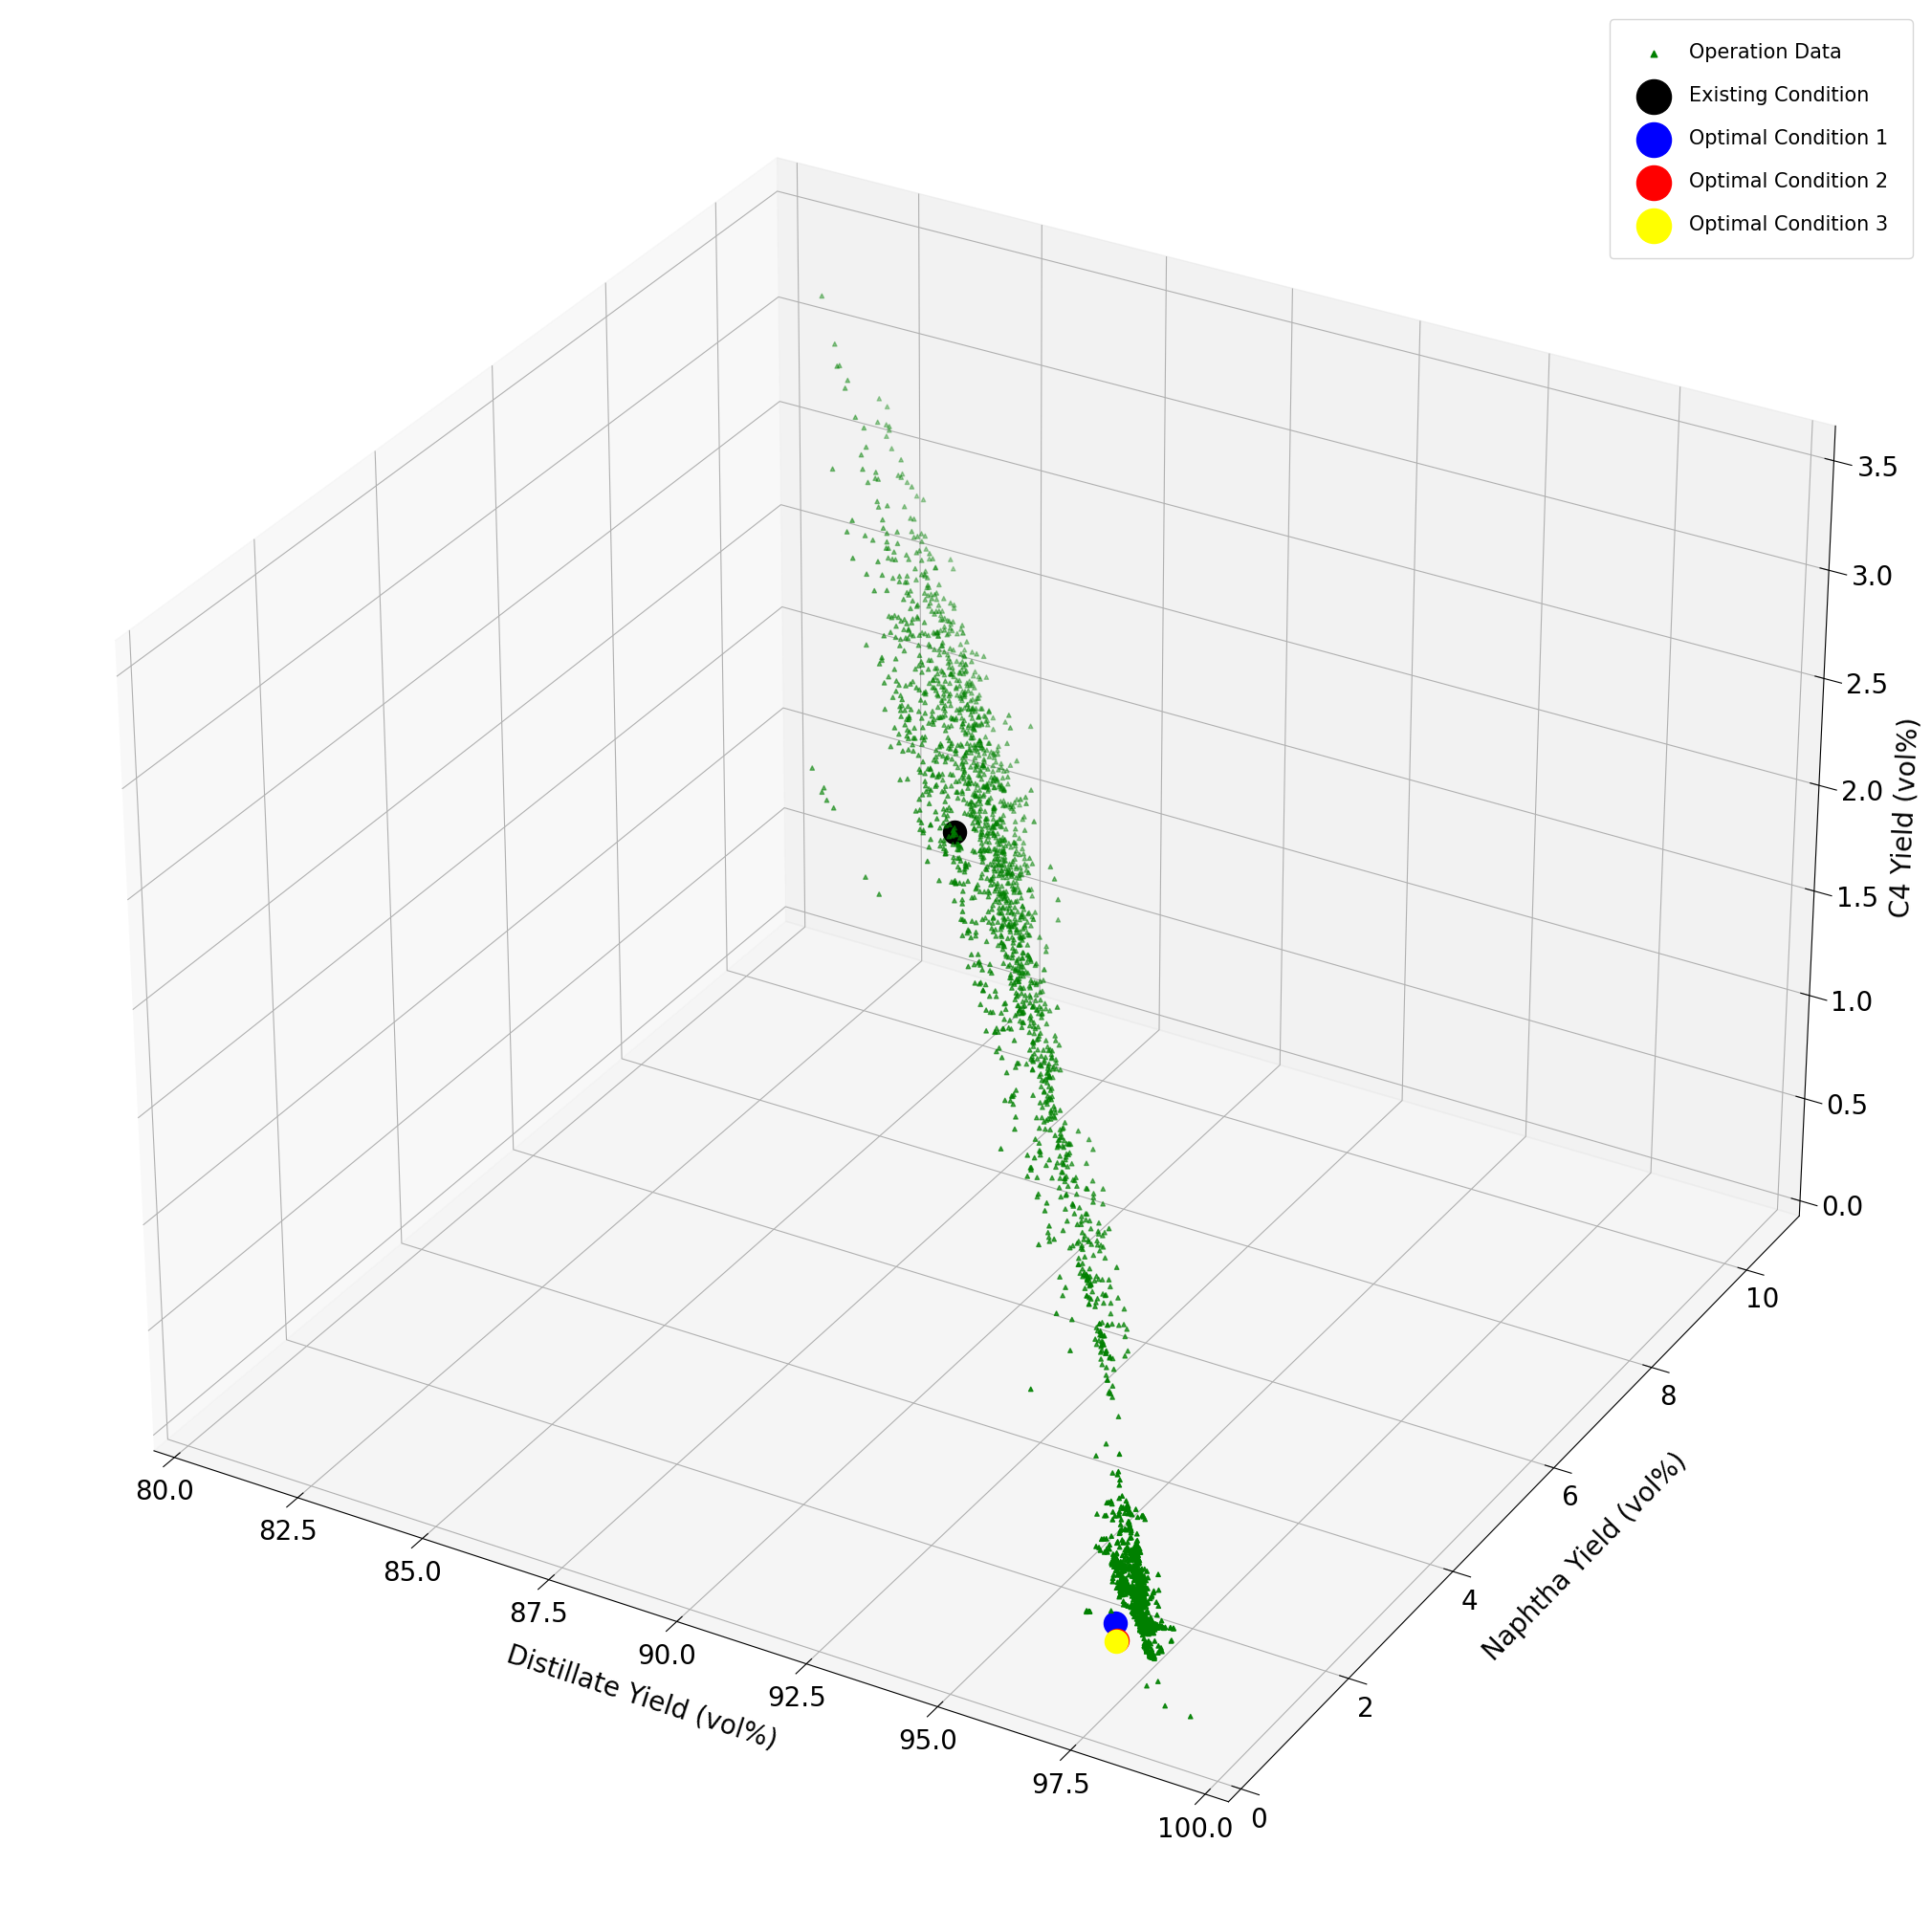

In [156]:
# Extract the coordinates for the optimal points
optimal_points = [
    (-res.F[75, 0], res.F[75, 1], res.F[75, 2]),  # Optimal 1
    (-res.F[7, 0], res.F[7, 1], res.F[7, 2]),    # Optimal 2
    (-res.F[2, 0], res.F[2, 1], res.F[2, 2]),    # Optimal 3
]

# Create a 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract the values for each axis from mode1filled
x1 = 100*mode2_clean['distillate yield (vol%)']
y1 = 100*mode2_clean['naphtha yield (vol%)']
z1 = 100*mode2_clean['C4 yield (vol%)']

x2 = 100*mode2_clean['distillate yield (vol%)'].iloc[150]
y2 = 100*mode2_clean['naphtha yield (vol%)'].iloc[150]
z2 = 100*mode2_clean['C4 yield (vol%)'].iloc[150]

# Define colors and labels for optimal points
optimal_colors = ['blue', 'red', 'yellow']
optimal_labels = ['Optimal Condition 1', 'Optimal Condition 2', 'Optimal Condition 3']

# Plot the 3D scatter plot for operation data
ax.scatter(x1, y1, z1, c='green', marker='^', s=10, label='Operation Data')

# Plot the 3D Pareto front
#ax.scatter(pareto_front[:, 0], -pareto_front[:, 1], -pareto_front[:, 2], s=100, c='red', alpha=0.1, marker='o', label='Pareto Front')

# Plot the existing condition
ax.scatter(x2, y2, z2, c='k', marker='o', s=300, label='Existing Condition')

# Plot the optimal points
for i, (opt_point, color, label) in enumerate(zip(optimal_points, optimal_colors, optimal_labels)):
    ax.scatter(100*opt_point[0], 100*opt_point[1], 100*opt_point[2], c=color, marker='o', s=300, label=label)

# Set labels and title
ax.set_xlabel('Distillate Yield (vol%)', fontsize=20, labelpad=20)
ax.set_ylabel('Naphtha Yield (vol%)', fontsize=20, labelpad=20)
ax.set_zlabel('C4 Yield (vol%)', fontsize=20, labelpad=20)
#ax.set_title('Optimal Conditions of Pareto Front', fontsize=20)

# Set axis limits to start from specific values
ax.set_xlim(left=80)
ax.set_ylim(bottom=0)
ax.set_zlim(bottom=0)

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='z', labelsize=20)
ax.tick_params(axis='z', pad=12)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.5, right=20, top=3, bottom=0.5)

# Add a legend with a larger font size
ax.legend(fontsize=15, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Show the plot
plt.show()


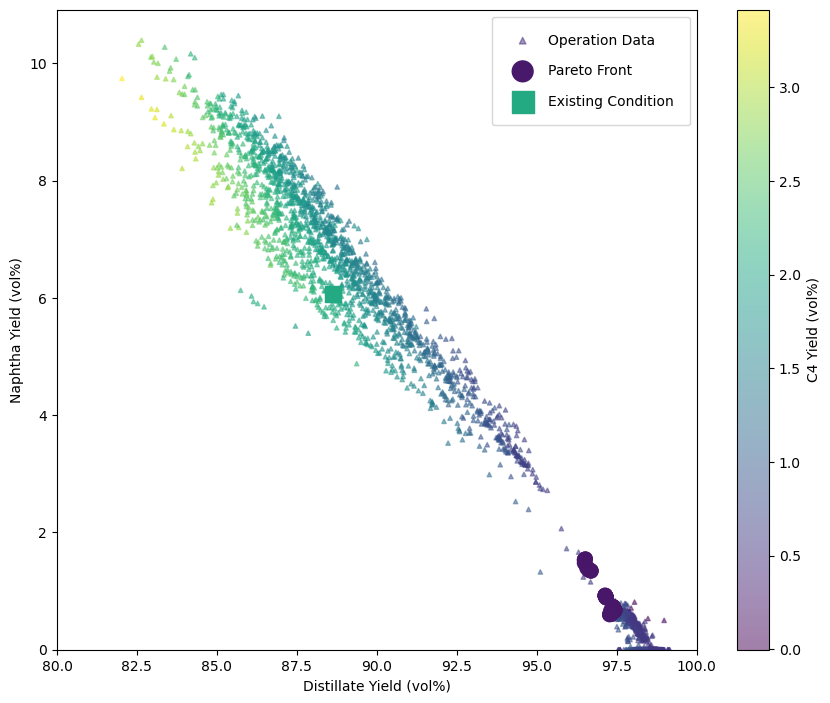

In [158]:
import matplotlib.pyplot as plt

# Assuming pareto_front contains the objective values of non-dominated solutions
# Example: pareto_front is a 2D numpy array with shape (n_samples, 3)
pareto_front = -res.F  # Replace with your actual Pareto front data

# Create a 2D figure
fig, ax = plt.subplots(figsize=(10, 8))

# Extract the values for each axis from mode1filled
x1 = 100*mode2_clean['distillate yield (vol%)']
y1 = 100*mode2_clean['naphtha yield (vol%)']
z1 = 100*mode2_clean['C4 yield (vol%)']

# Extract the values for the specific instance
x2 = 100*mode2_clean['distillate yield (vol%)'].iloc[150]
y2 = 100*mode2_clean['naphtha yield (vol%)'].iloc[150]
z2 = 100*mode2_clean['C4 yield (vol%)'].iloc[150]

# Normalize colors
norm = plt.Normalize(vmin=min(z1.min(), pareto_front[:, 2].min()), vmax=max(z1.max(), pareto_front[:, 2].max()))

# Plot the 2D scatter plot for mode1filled data with color representing C4 yield
sc = ax.scatter(x1, y1, c=z1, cmap='viridis', marker='^', s=10, label='Operation Data', alpha=0.5, norm=norm)

# Plot the 2D Pareto front with different marker and color
pf = ax.scatter(100*pareto_front[:, 0], -100*pareto_front[:, 1], c=-100*pareto_front[:, 2], cmap='viridis', s=100, marker='o', label='Pareto Front', norm=norm)

# Plot the specific instance from mode1filled, keeping the color consistent
ec = ax.scatter([x2], [y2], c=[z2], cmap='viridis', marker='s', s=120, label='Existing Condition', norm=norm)

# Set labels and title
ax.set_xlabel('Distillate Yield (vol%)', fontsize=10)
ax.set_ylabel('Naphtha Yield (vol%)', fontsize=10)
#ax.set_title('Pareto Front', fontsize=10)

# Set axis limits to start from specific values
ax.set_xlim(left=80)
ax.set_ylim(bottom=0)

# Add a color bar to represent the C4 yield values
cbar = plt.colorbar(sc)
cbar.set_label('C4 Yield (vol%)', fontsize=10)

# Add a legend with a larger font size
ax.legend(fontsize=10, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Show the plot
plt.show()


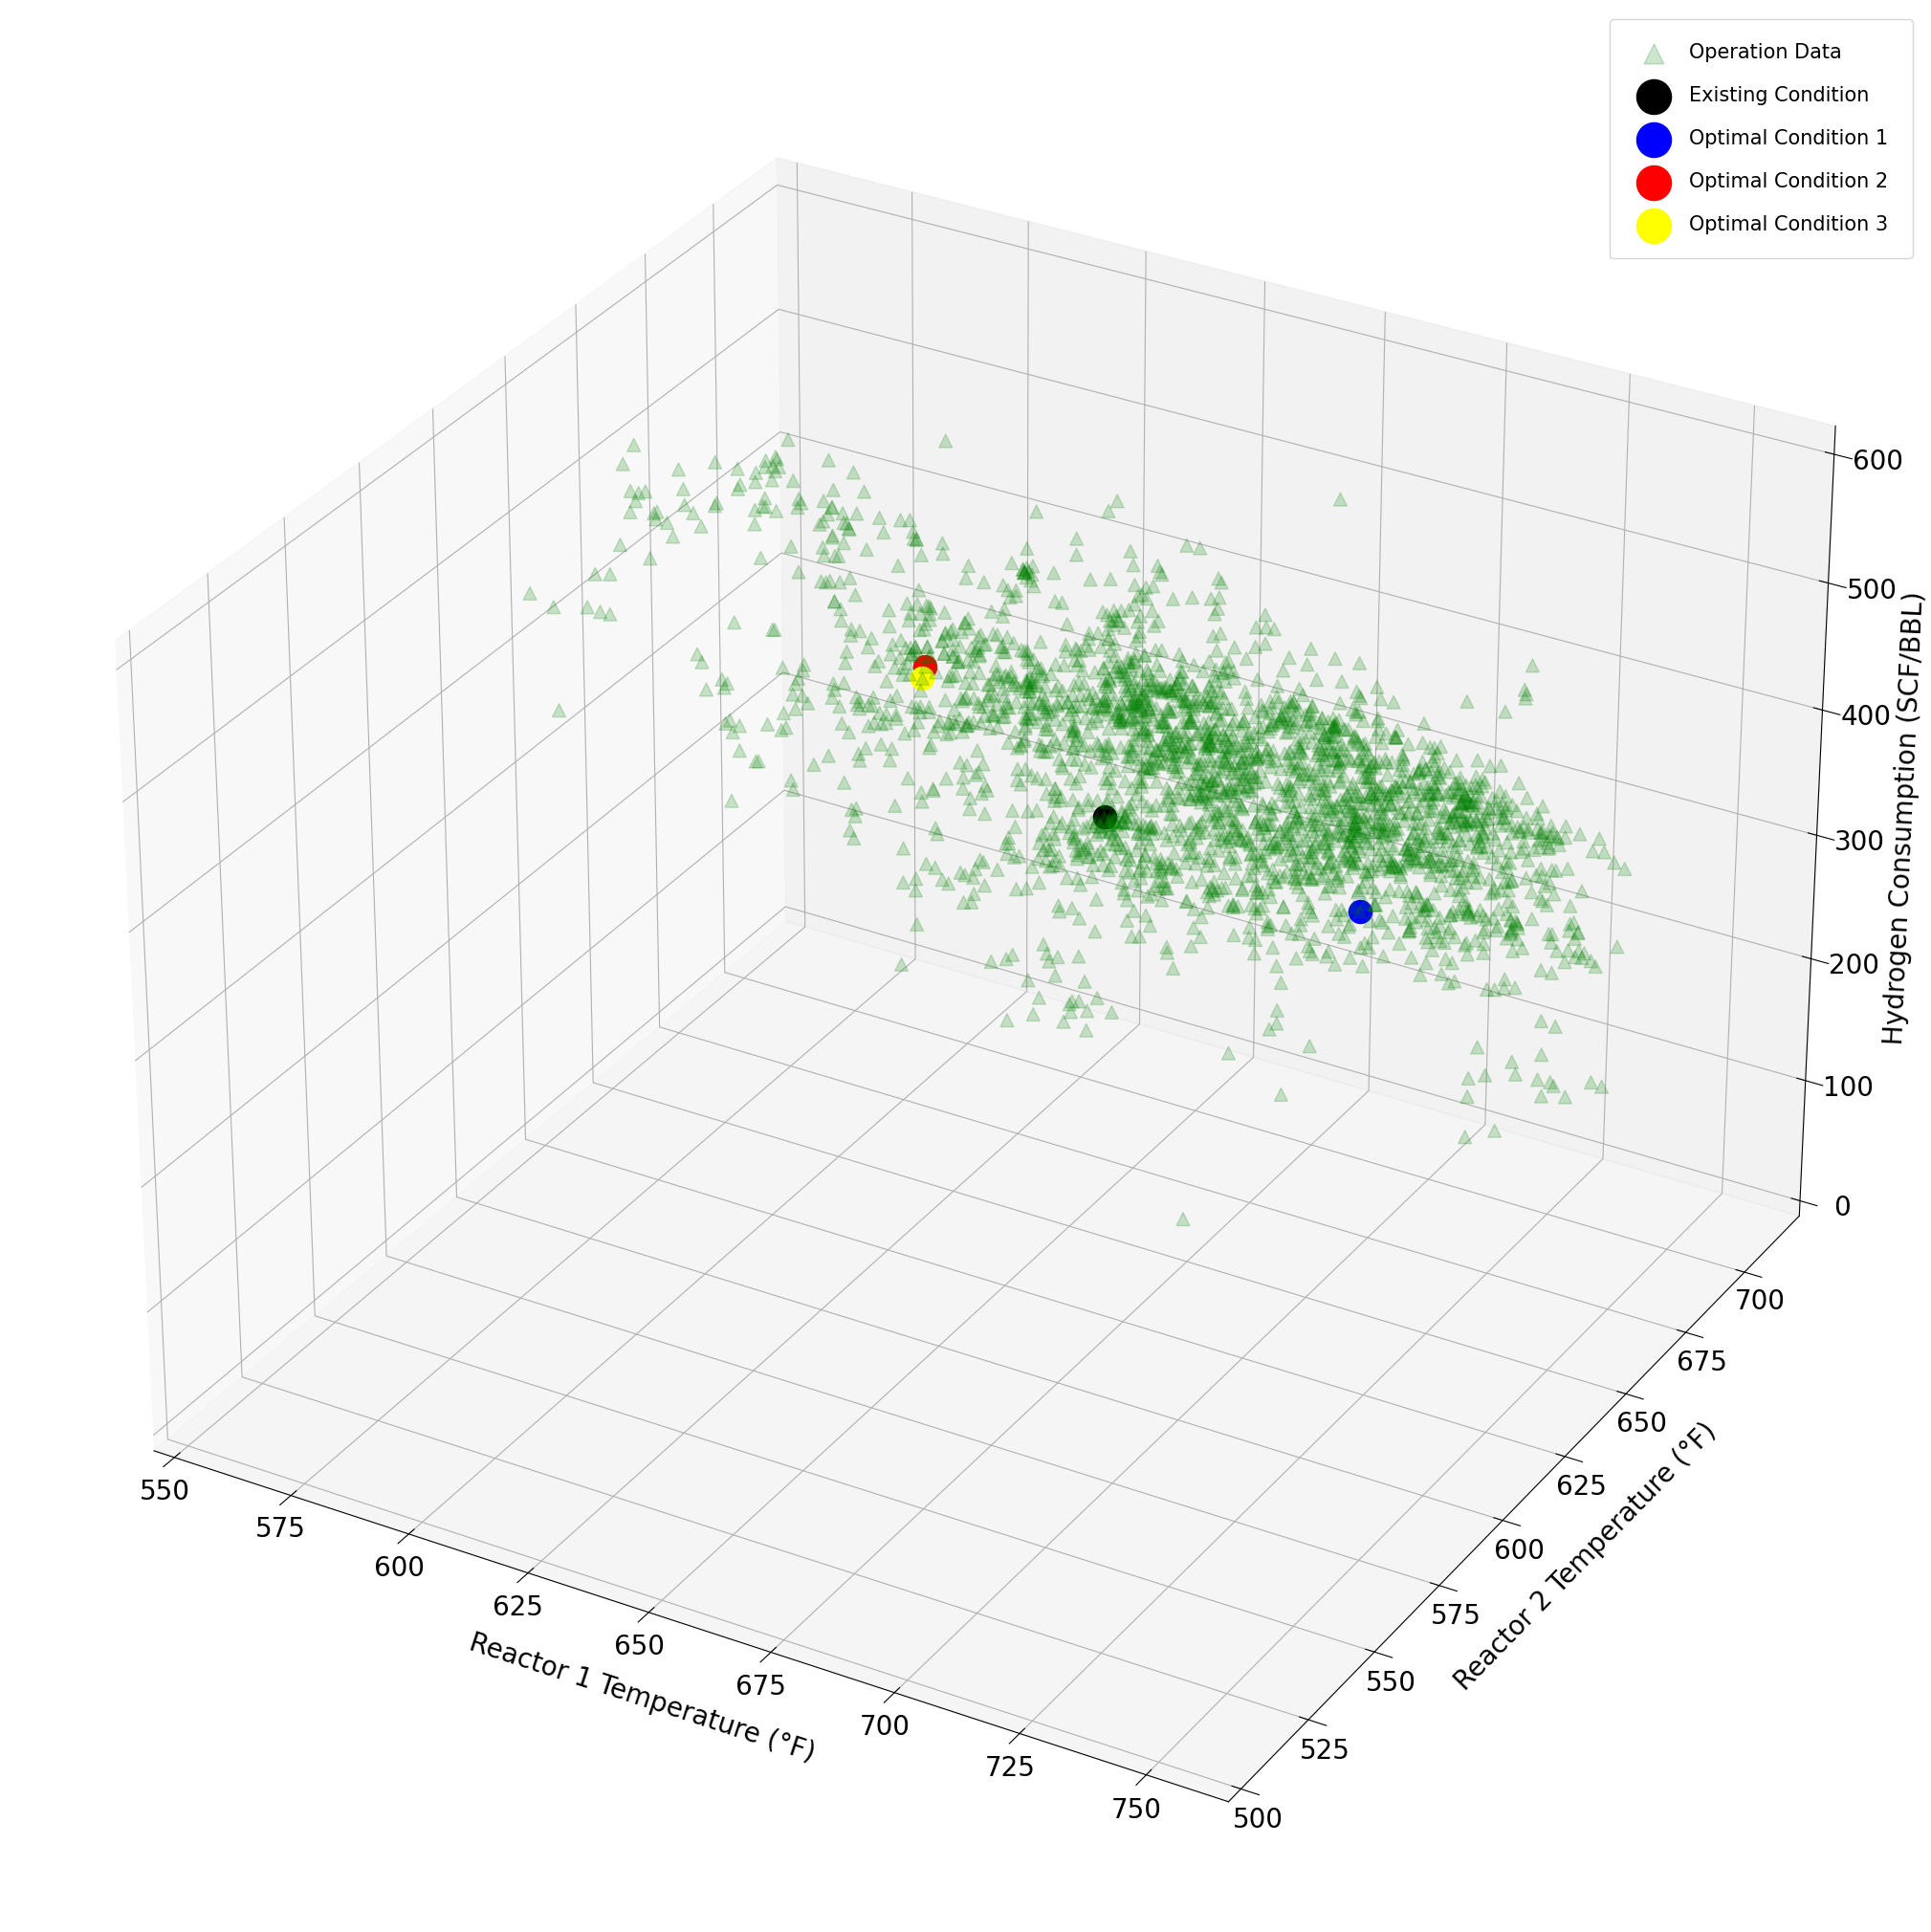

In [159]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming result_input and mode1filled contain the DataFrame with the values
# Create a 3D figure
fig = plt.figure(figsize=(10, 8))  # Adjusted figure size for better visualization
ax = fig.add_subplot(111, projection='3d')

# Extract the values for each axis from result_input
x1 = result_input.iloc[:, 18]
y1 = result_input.iloc[:, 19]
z1 = result_input.iloc[:, 20]

# Extract the values for each axis from mode1filled
x2 = mode2_clean['reactor 1 temperature (°F)']
y2 = mode2_clean['reactor 2 temperature (°F)']
z2 = mode2_clean['Hydrogen Consumption (SCF/BBL)']

# Ensure the data for the specific instance in X is correctly indexed
x3 = X[150][18]
y3 = X[150][19]
z3 = X[150][20]

# Extract optimal points (Replace indices with actual values as needed)
optimal_points = [
    (X[75][18], X[75][19], X[75][20]),  # Optimal Point 1
    (X[7][18], X[7][19], X[7][20]),     # Optimal Point 2
    (X[2][18], X[2][19], X[2][20]),     # Optimal Point 3
]

# Colors and labels for optimal points
optimal_colors = ['blue', 'red', 'yellow']
optimal_labels = ['Optimal Condition 1', 'Optimal Condition 2', 'Optimal Condition 3']

# Plot the 3D scatter plot for mode1filled data
ax.scatter(x2, y2, z2, c='green', marker='^', s=100, alpha=0.2, label='Operation Data')

# Plot the 3D scatter plot for result_input data
#ax.scatter(x1, y1, z1, c='r', marker='o', s=200, label='Optimal Condition')

# Plot the specific instance from X
ax.scatter(x3, y3, z3, c='k', marker='o', s=300, label='Existing Condition')  # Increased size for better visibility

# Plot optimal points
for i, (opt_point, color, label) in enumerate(zip(optimal_points, optimal_colors, optimal_labels)):
    ax.scatter(opt_point[0], opt_point[1], opt_point[2], c=color, marker='o', s=300, label=label)

# Set labels and title
ax.set_xlabel('Reactor 1 Temperature (°F)' , fontsize=20, labelpad=20)
ax.set_ylabel('Reactor 2 Temperature (°F)', fontsize=20, labelpad=20)
ax.set_zlabel('Hydrogen Consumption (SCF/BBL)', fontsize=20, labelpad=20)
#ax.set_title('Optimal Operation Conditions', fontsize=20)


# Set axis limits to start from zero
ax.set_xlim(left=550)
ax.set_ylim(bottom=500)
ax.set_zlim(bottom=0)

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='z', labelsize=20)
ax.tick_params(axis='z', pad=12)

# Add a legend with a larger font size
ax.legend(fontsize=15, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.5, right=20, top=3, bottom=0.5)

# Set initial viewing angle
#ax.view_init(elev=30, azim=135)  # Adjust elevation and azimuth for different point of view


# Show the plot
plt.show()


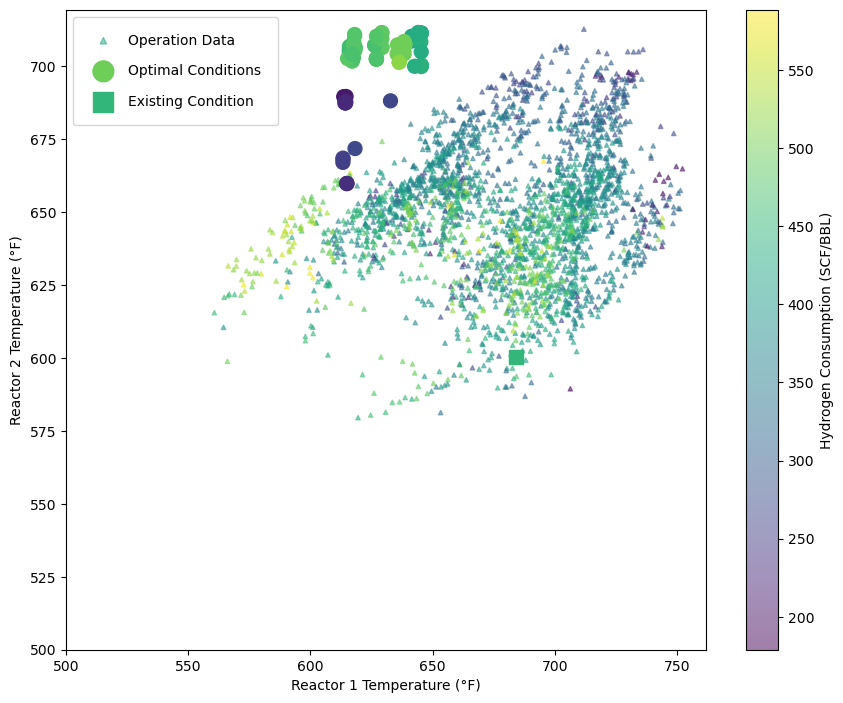

In [85]:
import matplotlib.pyplot as plt

# Assuming result_input and mode1filled contain the DataFrame with the values
# Create a 2D figure
fig, ax = plt.subplots(figsize=(10, 8))  # Adjusted figure size for better visualization

# Extract the values for each axis from result_input
x1 = result_input.iloc[:, 18]
y1 = result_input.iloc[:, 19]
z1 = result_input.iloc[:, 20]

# Extract the values for each axis from mode1filled
x2 = mode2_clean['reactor 1 temperature (°F)']
y2 = mode2_clean['reactor 2 temperature (°F)']
z2 = mode2_clean['Hydrogen Consumption (SCF/BBL)']

# Ensure the data for the specific instance in X is correctly indexed
x3 = X[150][18]
y3 = X[150][19]
z3 = X[150][20]

# Normalize colors
norm = plt.Normalize(vmin=min(z1.min(), z2.min(), z3), vmax=max(z1.max(), z2.max(), z3))

# Plot the scatter plot for mode1filled data with color representing total Hydrogen out
sc = ax.scatter(x2, y2, c=z2, cmap='viridis', marker='^', s=10, label='Operation Data', alpha=0.5, norm=norm)

# Plot the scatter plot for result_input data
ax.scatter(x1, y1, c=z1, cmap='viridis', marker='o', s=100, label='Optimal Conditions', norm=norm)

# Plot the specific instance from X
ax.scatter([x3], [y3], c=[z3], cmap='viridis', marker='s', s=100, label='Existing Condition', norm=norm)  # Increased size

# Set labels and titles
ax.set_xlabel('Reactor 1 Temperature (°F)', fontsize=10)
ax.set_ylabel('Reactor 2 Temperature (°F)', fontsize=10)
#ax.set_title('Optimal Operation Conditions', fontsize=10)

# Set axis limits to start from specific values
ax.set_xlim(left=500)
ax.set_ylim(bottom=500)

# Add a color bar to represent the Hydrogen out values
cbar = plt.colorbar(sc)
cbar.set_label('Hydrogen Consumption (SCF/BBL)', fontsize=10)

# Add a legend with a larger font size
ax.legend(fontsize=10, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Show the plot
plt.show()


## Scenario 2: Maximizing Distillate Yield under High-Yield Conditions

In [86]:
class OptimizationProblem(Problem):
    def __init__(self, x_min, x_max, distillate_model, naphtha_model, C1_model, C2_model, C3_model ,C4_model):
        super().__init__(n_var=len(x_min), n_obj=6, n_ieq_constr=1, n_eq_constr=1, xl=x_min, xu=x_max)
        self.model_distillate = distillate_model
        self.model_naphtha = naphtha_model
        self.model_C1 = C1_model
        self.model_C2 = C2_model
        self.model_C3 = C3_model
        self.model_C4 = C4_model

    def _evaluate(self, X, out, *args, **kwargs):
        df = pd.DataFrame(list(X))
        
        # Predict yields using the respective models
        distillate_yield =  self.model_distillate.predict(df)
        naphtha_yield =  self.model_naphtha.predict(df)
        C1_yield = self.model_C1.predict(df)
        C2_yield = self.model_C2.predict(df)
        C3_yield = self.model_C3.predict(df)
        C4_yield = self.model_C4.predict(df)
    
        
        #Constraints
        Constraint1 =  distillate_yield + naphtha_yield + C1_yield + C2_yield + C3_yield+ C4_yield- 1
        Constraint2 = - naphtha_yield

        # Set the objectives
        out['F'] = np.column_stack([-distillate_yield, naphtha_yield, C1_yield, C2_yield, C3_yield, C4_yield ])
        out['H'] = np.column_stack([Constraint1])
        out['G'] = np.column_stack([Constraint2])

In [87]:
distillate_model.predict(X[50])

0.9856257730798372

In [88]:
X[50]

array([1.36100000e+03, 8.73100000e-01, 1.99666187e+01, 1.58391559e+00,
       6.25015798e+02, 3.85995403e+02, 1.96000000e+03, 8.79400000e-01,
       1.73152063e+00, 2.99617587e+01, 1.85036941e+01, 5.14350000e+03,
       9.27400000e-01, 1.79245304e-01, 3.05020204e+02, 0.00000000e+00,
       6.69408586e+02, 1.45086074e+02, 6.50627806e+02, 6.58709636e+02,
       3.84260893e+02])

In [89]:
# Define the range of possible values for each building design parameters
x_min = X.min(axis=0).tolist()
x_max = X.max(axis=0).tolist()
print(x_min, x_max)

[879.0, 0.8507, 12.12700087, 0.50489742, 328.4963715, 0.0, 25.0, 0.845933333, 0.237996336, 0.0, 0.0, 34.0, 0.8013, 0.069574998, 0.0, 0.0, 251.1030965, 20.35591545, 560.694361, 579.4955702, 178.9243661] [3790.0, 0.8793, 23.84860727, 5.085025275, 1079.55893, 477.6448362, 5130.0, 0.8895, 4.695713165, 199.9444997, 74.13734696, 9621.0, 1.0794, 4.448869416, 509.4660358, 555.1772381, 964.3036638, 299.9134892, 752.0934121, 712.5559171, 588.6427091]


In [90]:
# Define the range of possible values for each building design parameters
x_min =[1.36100000e+03, 8.73100000e-01, 1.99666187e+01, 1.58391559e+00,
       6.25015798e+02, 3.85995403e+02, 1.96000000e+03, 8.79400000e-01,
       1.73152063e+00, 2.99617587e+01, 1.85036941e+01, 5.14350000e+03,
       9.27400000e-01, 1.79245304e-01, 3.05020204e+02, 0.00000000e+00,
       6.69408586e+02, 1.45086074e+02, 560.694361, 579.4955702, 178.9243661]
x_max = [1.36100000e+03, 8.73100000e-01, 1.99666187e+01, 1.58391559e+00,
       6.25015798e+02, 3.85995403e+02, 1.96000000e+03, 8.79400000e-01,
       1.73152063e+00, 2.99617587e+01, 1.85036941e+01, 5.14350000e+03,
       9.27400000e-01, 1.79245304e-01, 3.05020204e+02, 0.00000000e+00,
       6.69408586e+02, 1.45086074e+02, 752.0934121, 712.5559171, 588.6427091]
print(x_min, x_max)

[1361.0, 0.8731, 19.9666187, 1.58391559, 625.015798, 385.995403, 1960.0, 0.8794, 1.73152063, 29.9617587, 18.5036941, 5143.5, 0.9274, 0.179245304, 305.020204, 0.0, 669.408586, 145.086074, 560.694361, 579.4955702, 178.9243661] [1361.0, 0.8731, 19.9666187, 1.58391559, 625.015798, 385.995403, 1960.0, 0.8794, 1.73152063, 29.9617587, 18.5036941, 5143.5, 0.9274, 0.179245304, 305.020204, 0.0, 669.408586, 145.086074, 752.0934121, 712.5559171, 588.6427091]


In [91]:
# Initialize the problem
problem = OptimizationProblem(x_min, x_max, distillate_model, naphtha_model, C1_model, C2_model, C3_model ,C4_model)

In [92]:
# Set up the NSGA-II algorithm
algorithm = NSGA2(
    pop_size=5000,
    n_offsprings=5000,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PolynomialMutation(prob=1.0/len(x_min), eta=20),
    eliminate_duplicates=True
)

In [93]:
# Define a convergence termination class
class ConvergenceTermination(Termination):
    def __init__(self, conv_threshold, conv_generations, n_max_gen):
        super().__init__()
        self.conv_threshold = conv_threshold
        self.conv_generations = conv_generations
        self.n_max_gen = n_max_gen
        self.best_fit_values = []
        self.conv_counter = 0
        self.converged_solution_X = None
        self.converged_solution_F = None

    # check for the convergence criterion
    def _do_continue(self, algorithm):
        return self.perc < 1.0
    
    # check the convergence progress
    def _update(self, algorithm):
        best_fit = algorithm.pop.get("F").min()
        self.best_fit_values.append(best_fit)
        
        if algorithm.n_gen >= self.n_max_gen:
            return 1.0

        if len(self.best_fit_values) > self.conv_generations:
            conv_rate = abs(self.best_fit_values[-1] - self.best_fit_values[-self.conv_generations]) / self.conv_generations
            if conv_rate < self.conv_threshold:
                self.conv_counter += 1
                if self.conv_counter >= 5:
                    # store the termination object and use it to print the converged solution and the objective value later
                    self.converged_solution_X = algorithm.pop[np.argmin(algorithm.pop.get("F"))].get("X")
                    self.converged_solution_F = algorithm.pop.get("F")
                    print(f"Algorithm has converged after {algorithm.n_gen} generations.")
                    return 1.0
            else:
                self.conv_counter = 0
        return algorithm.n_gen / self.n_max_gen

In [94]:
# Define the callback function to store the generation number along with the non-dominated solutions found at each generation
def generation_callback(algorithm):
    generation_number = algorithm.n_gen
    non_dominated_solutions = algorithm.pop.get("F")


In [95]:
# Perform the optimization
termination = ConvergenceTermination(conv_threshold=0.1, conv_generations=5, n_max_gen=500)

res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    callback=generation_callback,
    verbose=True,
)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |     5000 |      5 |  0.000000E+00 |  0.0026869720 |             - |             -
     2 |    10000 |     15 |  0.000000E+00 |  0.0010461215 |  0.6486560931 |         ideal
     3 |    15000 |     12 |  0.000000E+00 |  0.0005474949 |  0.6618606888 |         ideal
     4 |    20000 |     19 |  0.000000E+00 |  0.0002869075 |  0.0214535185 |         ideal
     5 |    25000 |     29 |  0.000000E+00 |  0.0001518180 |  0.0027039228 |         ideal
     6 |    30000 |     30 |  0.000000E+00 |  0.0000753858 |  0.1138204325 |         ideal
     7 |    35000 |     47 |  0.000000E+00 |  0.0000312391 |  0.0126218799 |         ideal
     8 |    40000 |     60 |  0.000000E+00 |  0.0000109211 |  0.0159512036 |         ideal
     9 |    45000 |     82 |  0.000000E+00 |  1.919879E-06 |  0.0237923376 |         nadir
Algorithm has converged after 10 generations.
    10 |    50000 |     56 |  0.000000E+00 |

In [96]:
# Retrieve the termination object after the optimization
convergence = res.algorithm.termination

## Filtering and comparison of optimal conditions from all the solutions found

In [97]:
distances = np.linalg.norm(res.X - X[50], axis=1)

# Find the index of the closest point
closest_point_index = np.argmin(distances)

# Get the closest point
closest_point = res.X[closest_point_index]

# Output the closest point and its index
print(f"Closest point to X[150]: {closest_point}")
print(f"Index of closest point: {closest_point_index}")

Closest point to X[150]: [1.36100000e+03 8.73100000e-01 1.99666187e+01 1.58391559e+00
 6.25015798e+02 3.85995403e+02 1.96000000e+03 8.79400000e-01
 1.73152063e+00 2.99617587e+01 1.85036941e+01 5.14350000e+03
 9.27400000e-01 1.79245304e-01 3.05020204e+02 0.00000000e+00
 6.69408586e+02 1.45086074e+02 6.23932589e+02 6.52536170e+02
 3.45590892e+02]
Index of closest point: 48


In [98]:
predictions = distillate_model.predict(res.X)

# Find the index of the maximum prediction
max_index = np.argmax(predictions)

# Print the index of the row with the highest prediction
print("Index of row with highest prediction:", max_index)
print("Highest prediction value:", predictions[max_index])

Index of row with highest prediction: 9
Highest prediction value: 0.9889643856093905


In [99]:
import numpy as np

# Assuming res.X is a numpy array
row_index = np.argmin(res.X[:, 20])

print("Index of the row with the lowest value in column 20:", row_index)

Index of the row with the lowest value in column 20: 7


In [100]:
#Comparison of Reacor 1 temperature between current and optimal conditions
print(X[50][18]) #Current operation
print(res.X[48][18]) #Condition 1: Closest optimal point to current condition
print(res.X[9][18]) #Condition 2: Highest Distillate
print(res.X[7][18]) #Condition 3: Lowest Hydrogen consumption

650.6278056
623.932589153047
615.5140842550887
616.4920343271709


In [101]:
#Comparison of Reacor 2 temperature between current and optimal conditions
print(X[50][19]) #Current operation
print(res.X[48][19]) #Condition 1: Closest optimal point to current condition
print(res.X[9][19]) #Condition 2: Highest Distillate
print(res.X[7][19]) #Condition 3: Lowest Hydrogen consumption

658.7096358
652.5361699622857
684.1994711136979
683.4071537754753


In [102]:
#Comparison of Hydrogen Consumption between current and optimal conditions
print(X[50][20]) #Current operation
print(res.X[48][20]) #Condition 1: Closest optimal point to current condition
print(res.X[9][20]) #Condition 2: Highest Distillate
print(res.X[7][20]) #Condition 3: Lowest Hydrogen consumption

384.2608928
345.5908923081422
264.5497762627334
184.17015457971192


In [103]:
#Comparison of distillate yield between current and optimal conditions
print(mode2_clean['distillate yield (vol%)'].iloc[50]) #Current operation
print(distillate_model.predict(res.X[48])) #Condition 1: Closest optimal point to current condition
print(distillate_model.predict(res.X[9])) #Condition 2: Highest Distillate
print(distillate_model.predict(res.X[7])) #Condition 3: Lowest Hydrogen consumption

0.9867061425683379
0.9865038676692672
0.9889643856093905
0.9888592768073201


In [104]:
#Comparison of naphtha yield between current and optimal conditions
print(mode2_clean['naphtha yield (vol%)'].iloc[50]) #Current operation
print(naphtha_model.predict(res.X[48])) #Condition 1: Closest optimal point to current condition
print(naphtha_model.predict(res.X[9])) #Condition 2: Highest Distillate
print(naphtha_model.predict(res.X[7])) #Condition 3: Lowest Hydrogen consumption

0.0
0.0012179182076144518
0.00011979313729779117
4.2241684524359224e-05


In [105]:
#Comparison of C1 yield between current and optimal conditions
print(mode2_clean['C1 yield (vol%)'].iloc[50]) #Current operation
print(C1_model.predict(res.X[48])) #Condition 1: Closest optimal point to current condition
print(C1_model.predict(res.X[9])) #Condition 2: Highest Distillate
print(C1_model.predict(res.X[7])) #Condition 3: Lowest Hydrogen consumption

0.0017650200291928746
0.0016556848788898207
0.0015069331670075248
0.0015005313864041284


In [106]:
#Comparison of C2 yield between current and optimal conditions
print(mode2_clean['C2 yield (vol%)'].iloc[50]) #Current operation
print(C2_model.predict(res.X[48])) #Condition 1: Closest optimal point to current condition
print(C2_model.predict(res.X[9])) #Condition 2: Highest Distillate
print(C2_model.predict(res.X[7])) #Condition 3: Lowest Hydrogen consumption


0.0024004890027506253
0.0023051030299907466
0.0018905965954933348
0.0019105701766190062


In [107]:
#Comparison of C3 yield between current and optimal conditions
print(mode2_clean['C3 yield (vol%)'][50]) #Current operation
print(C3_model.predict(res.X[48])) #Condition 1: Closest optimal point to current condition
print(C3_model.predict(res.X[9])) #Condition 2: Highest Distillate
print(C3_model.predict(res.X[7])) #Condition 3: Lowest Hydrogen consumption

0.0050381416923725416
0.00444283305898148
0.0034925592967154223
0.003513169970000665


In [108]:
#Comparison of C4 yield between current and optimal conditions
print(mode2_clean['C4 yield (vol%)'][50]) #Current operation
print(C4_model.predict(res.X[48])) #Condition 1: Closest optimal point to current condition
print(C4_model.predict(res.X[9])) #Condition 2: Highest Distillate
print(C4_model.predict(res.X[7])) #Condition 3: Lowest Hydrogen consumption

0.0044009943015028245
0.00395750195620286
0.00402819406515993
0.004247987278228019


In [109]:
result_input = pd.DataFrame(list(res.X))
result_input

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,686.035094,703.515944,300.118122
1,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,685.864657,703.515944,300.118122
2,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,615.890563,682.740332,450.924389
3,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,619.574880,681.657400,432.717884
4,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,615.737309,653.706592,335.801422
5,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,686.035094,703.515944,312.823101
6,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,616.160410,649.767262,332.928853
7,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,616.492034,683.407154,184.170155
8,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,685.864657,703.516886,312.780962
9,1361.0,0.8731,19.966619,1.583916,625.015798,385.995403,1960.0,0.8794,1.731521,29.961759,18.503694,5143.5,0.9274,0.179245,305.020204,0.0,669.408586,145.086074,615.514084,684.199471,264.549776


In [110]:
result_output = pd.DataFrame(list(res.F))
result_output.loc[:,5].min()

0.003510016979320546

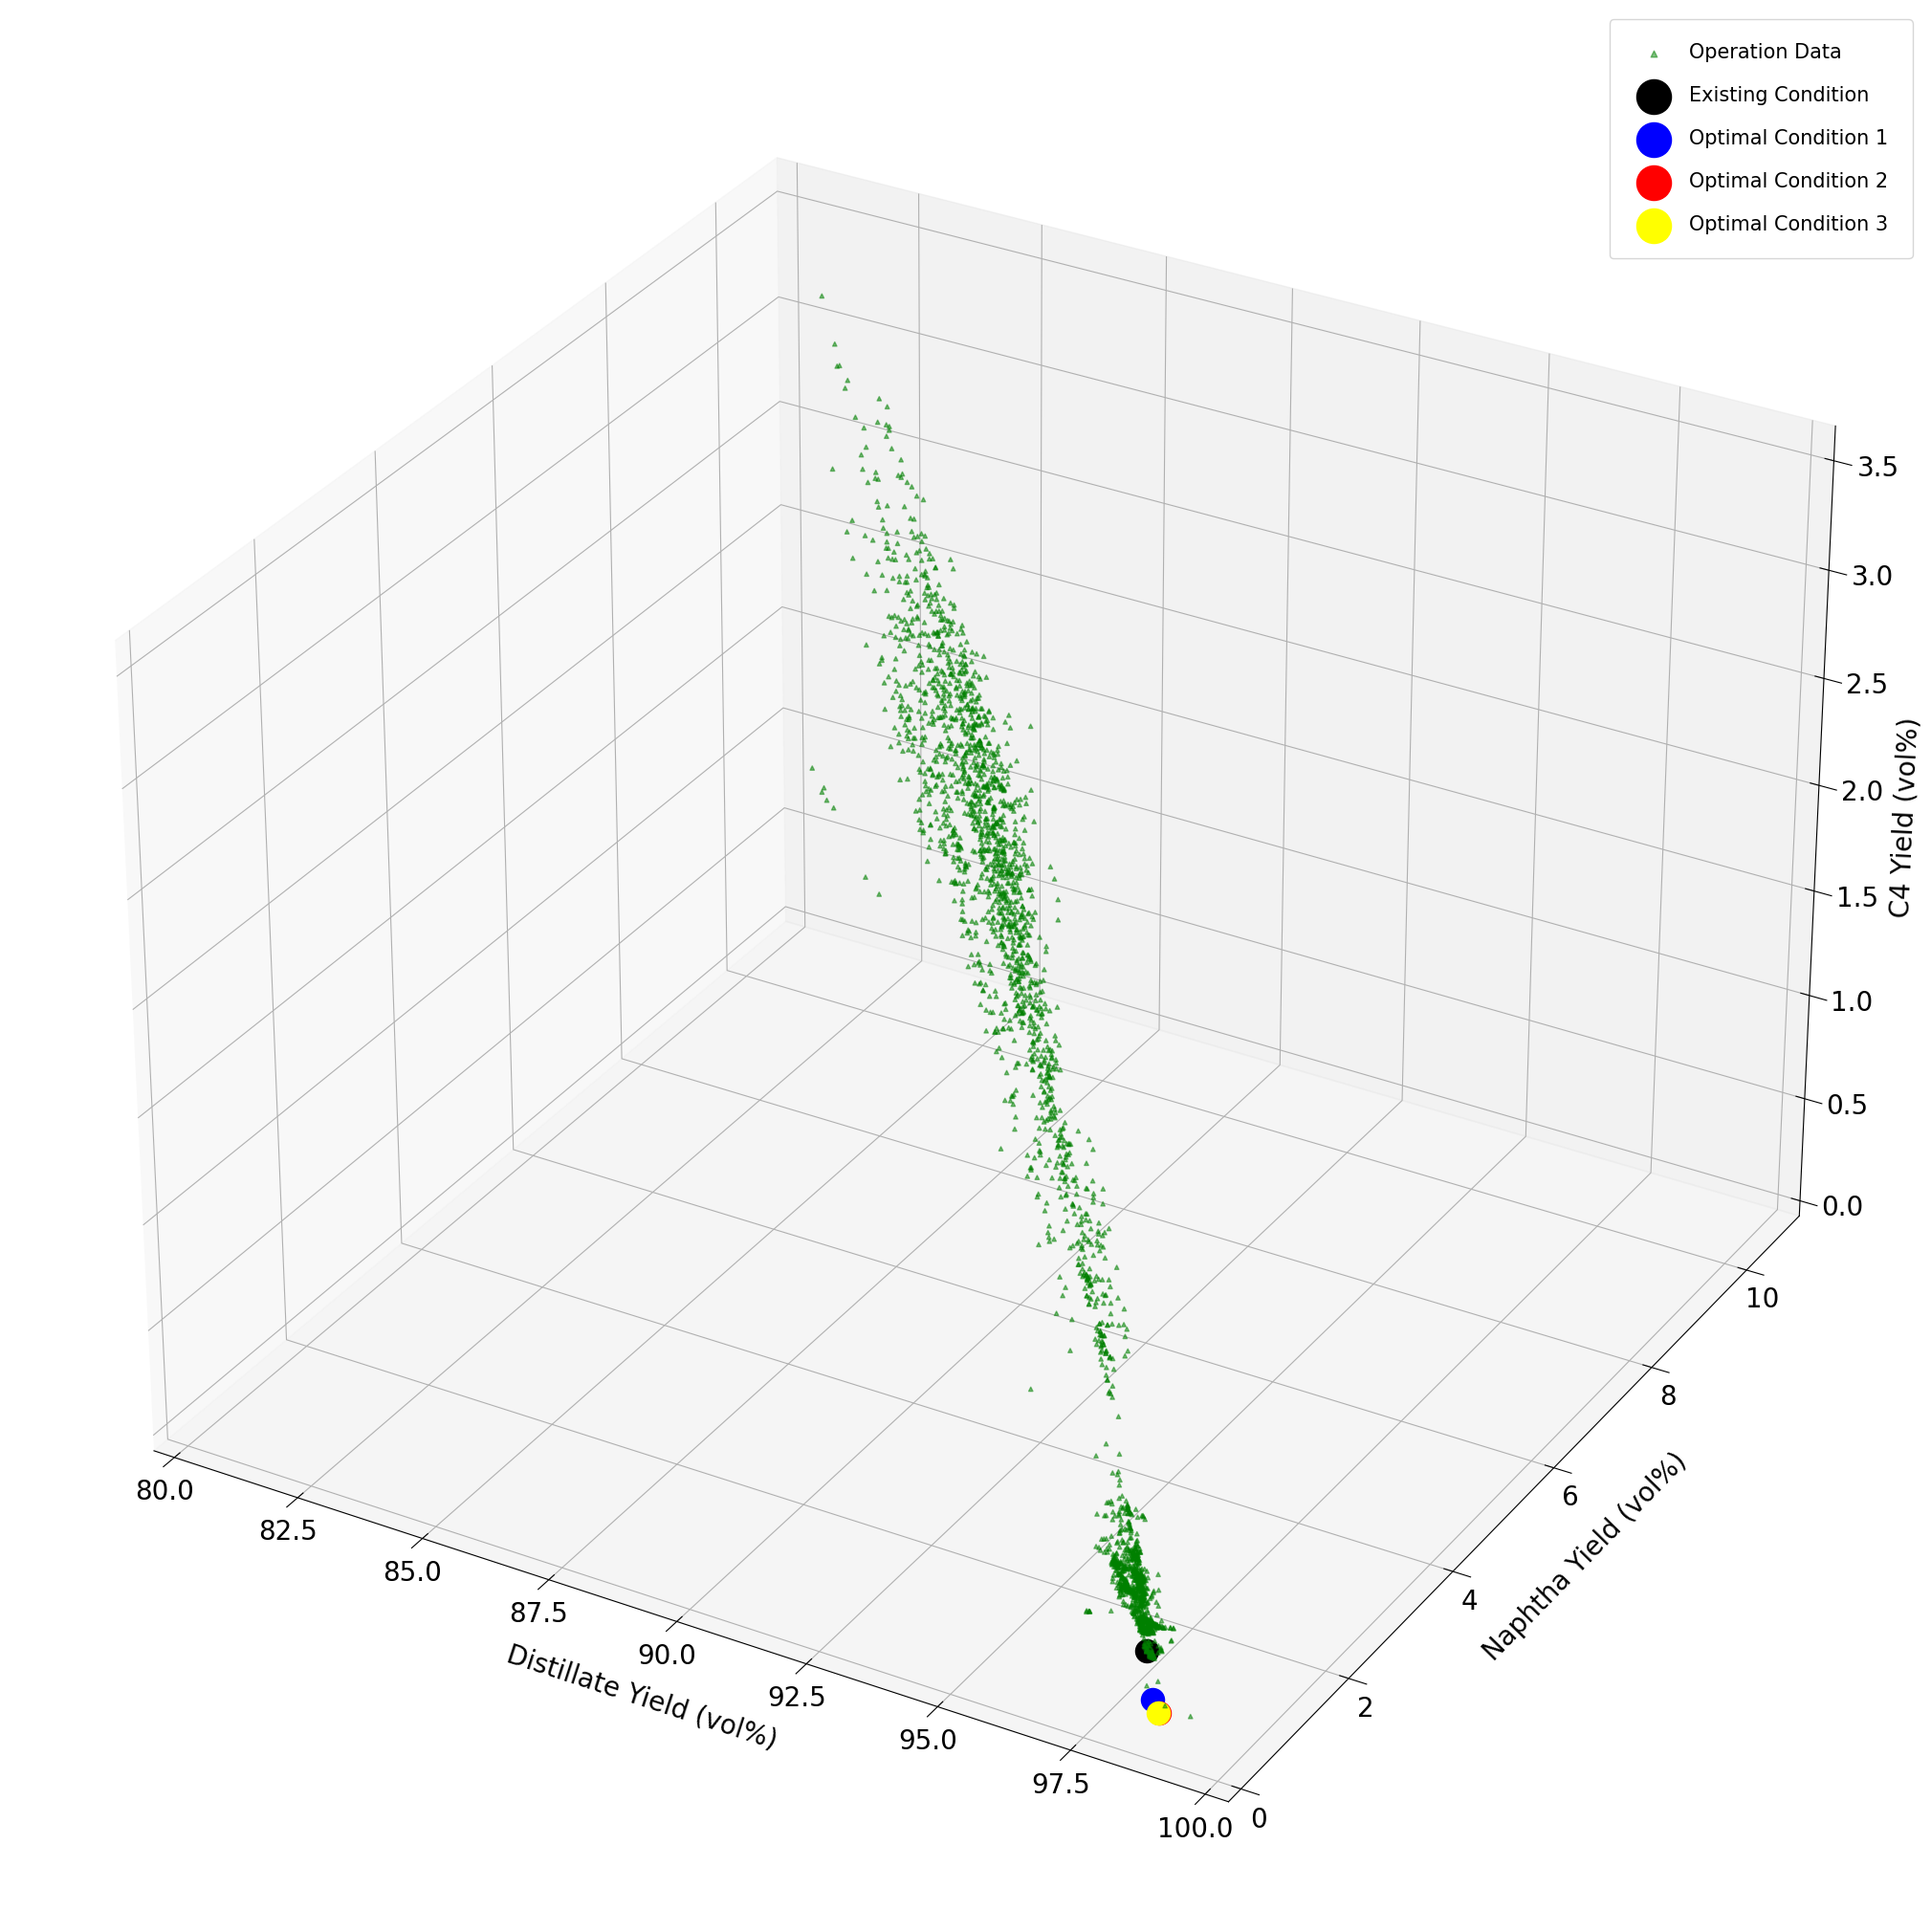

In [127]:
# Extract the coordinates for the optimal points
optimal_points = [
    (-res.F[48, 0], res.F[48, 1], res.F[48, 2]),  # Optimal 1
    (-res.F[9, 0], res.F[9, 1], res.F[9, 2]),    # Optimal 2
    (-res.F[7, 0], res.F[7, 1], res.F[7, 2]),    # Optimal 3
]

# Create a 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract the values for each axis from mode1filled
x1 = 100*mode2_clean['distillate yield (vol%)']
y1 = 100*mode2_clean['naphtha yield (vol%)']
z1 = 100*mode2_clean['C4 yield (vol%)']

x2 = 100*mode2_clean['distillate yield (vol%)'].iloc[50]
y2 = 100*mode2_clean['naphtha yield (vol%)'].iloc[50]
z2 = 100*mode2_clean['C4 yield (vol%)'].iloc[50]

# Define colors and labels for optimal points
optimal_colors = ['blue', 'red', 'yellow']
optimal_labels = ['Optimal Condition 1', 'Optimal Condition 2', 'Optimal Condition 3']

# Plot the 3D scatter plot for operation data
ax.scatter(x1, y1, z1, c='green', marker='^', s=10, alpha=0.5, label='Operation Data')

# Plot the 3D Pareto front
#ax.scatter(pareto_front[:, 0], -pareto_front[:, 1], -pareto_front[:, 2], s=100, c='orange',  alpha=0.5, marker='s', label='Pareto Front')

# Plot the existing condition
ax.scatter(x2, y2, z2, c='k', marker='o', s=300, label='Existing Condition')

# Plot the optimal points
for i, (opt_point, color, label) in enumerate(zip(optimal_points, optimal_colors, optimal_labels)):
    ax.scatter(100*opt_point[0], 100*opt_point[1], 100*opt_point[2], c=color, marker='o', s=300, label=label)

# Set labels and title
ax.set_xlabel('Distillate Yield (vol%)', fontsize=20, labelpad=20)
ax.set_ylabel('Naphtha Yield (vol%)', fontsize=20, labelpad=20)
ax.set_zlabel('C4 Yield (vol%)', fontsize=20, labelpad=20)
#ax.set_title('Optimal Conditions of Pareto Front', fontsize=20)

# Set axis limits to start from specific values
ax.set_xlim(left=80)
ax.set_ylim(bottom=0)
ax.set_zlim(bottom=0)

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='z', labelsize=20)
ax.tick_params(axis='z', pad=12)


# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.5, right=20, top=3, bottom=0.5)

# Add a legend with a larger font size
ax.legend(fontsize=15, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Show the plot
plt.show()


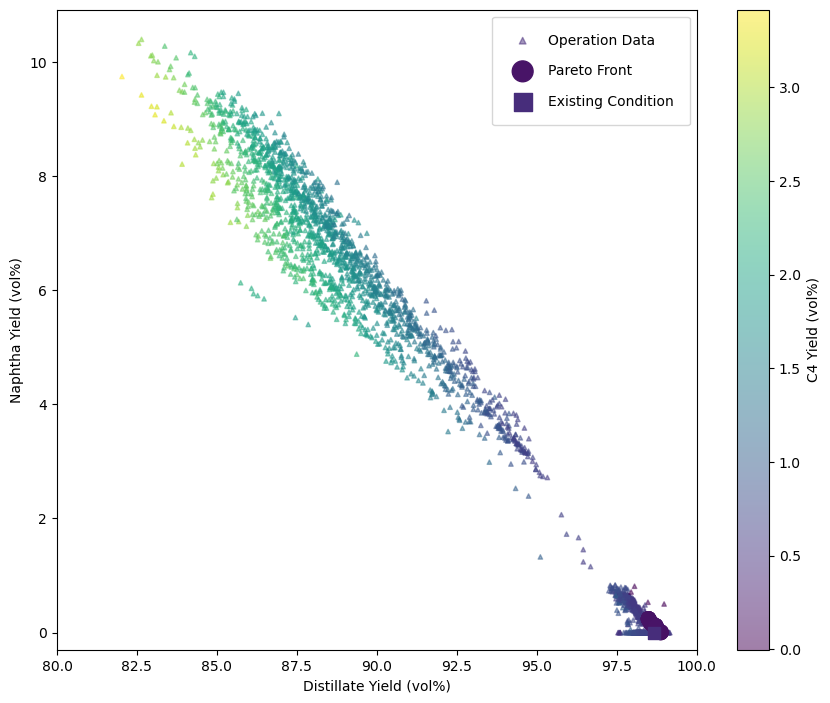

In [124]:
import matplotlib.pyplot as plt

# Assuming pareto_front contains the objective values of non-dominated solutions
# Example: pareto_front is a 2D numpy array with shape (n_samples, 3)
pareto_front = -res.F  # Replace with your actual Pareto front data

# Create a 2D figure
fig, ax = plt.subplots(figsize=(10, 8))

# Extract the values for each axis from mode1filled
x1 = 100*mode2_clean['distillate yield (vol%)']
y1 = 100*mode2_clean['naphtha yield (vol%)']
z1 = 100*mode2_clean['C4 yield (vol%)']

# Extract the values for the specific instance
x2 = 100*mode2_clean['distillate yield (vol%)'].iloc[50]
y2 = 100*mode2_clean['naphtha yield (vol%)'].iloc[50]
z2 = 100*mode2_clean['C4 yield (vol%)'].iloc[50]

# Normalize colors
norm = plt.Normalize(vmin=min(z1.min(), pareto_front[:, 2].min()), vmax=max(z1.max(), pareto_front[:, 2].max()))

# Plot the 2D scatter plot for mode1filled data with color representing C4 yield
sc = ax.scatter(x1, y1, c=z1, cmap='viridis', marker='^', s=10, label='Operation Data', alpha=0.5, norm=norm)

# Plot the 2D Pareto front with different marker and color
pf = ax.scatter(100*pareto_front[:, 0], -100*pareto_front[:, 1], c=-100*pareto_front[:, 2], cmap='viridis', s=100, marker='o', label='Pareto Front', norm=norm)

# Plot the specific instance from mode1filled, keeping the color consistent
ec = ax.scatter([x2], [y2], c=[z2], cmap='viridis', marker='s', s=80, label='Existing Condition', norm=norm)

# Set labels and title
ax.set_xlabel('Distillate Yield (vol%)', fontsize=10)
ax.set_ylabel('Naphtha Yield (vol%)', fontsize=10)
#ax.set_title('Pareto Front', fontsize=10)

# Set axis limits to start from specific values
ax.set_xlim(left=80)
ax.set_ylim(bottom=-0.3)

# Add a color bar to represent the C4 yield values
cbar = plt.colorbar(sc)
cbar.set_label('C4 Yield (vol%)', fontsize=10)

# Add a legend with a larger font size
ax.legend(fontsize=10, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Show the plot
plt.show()


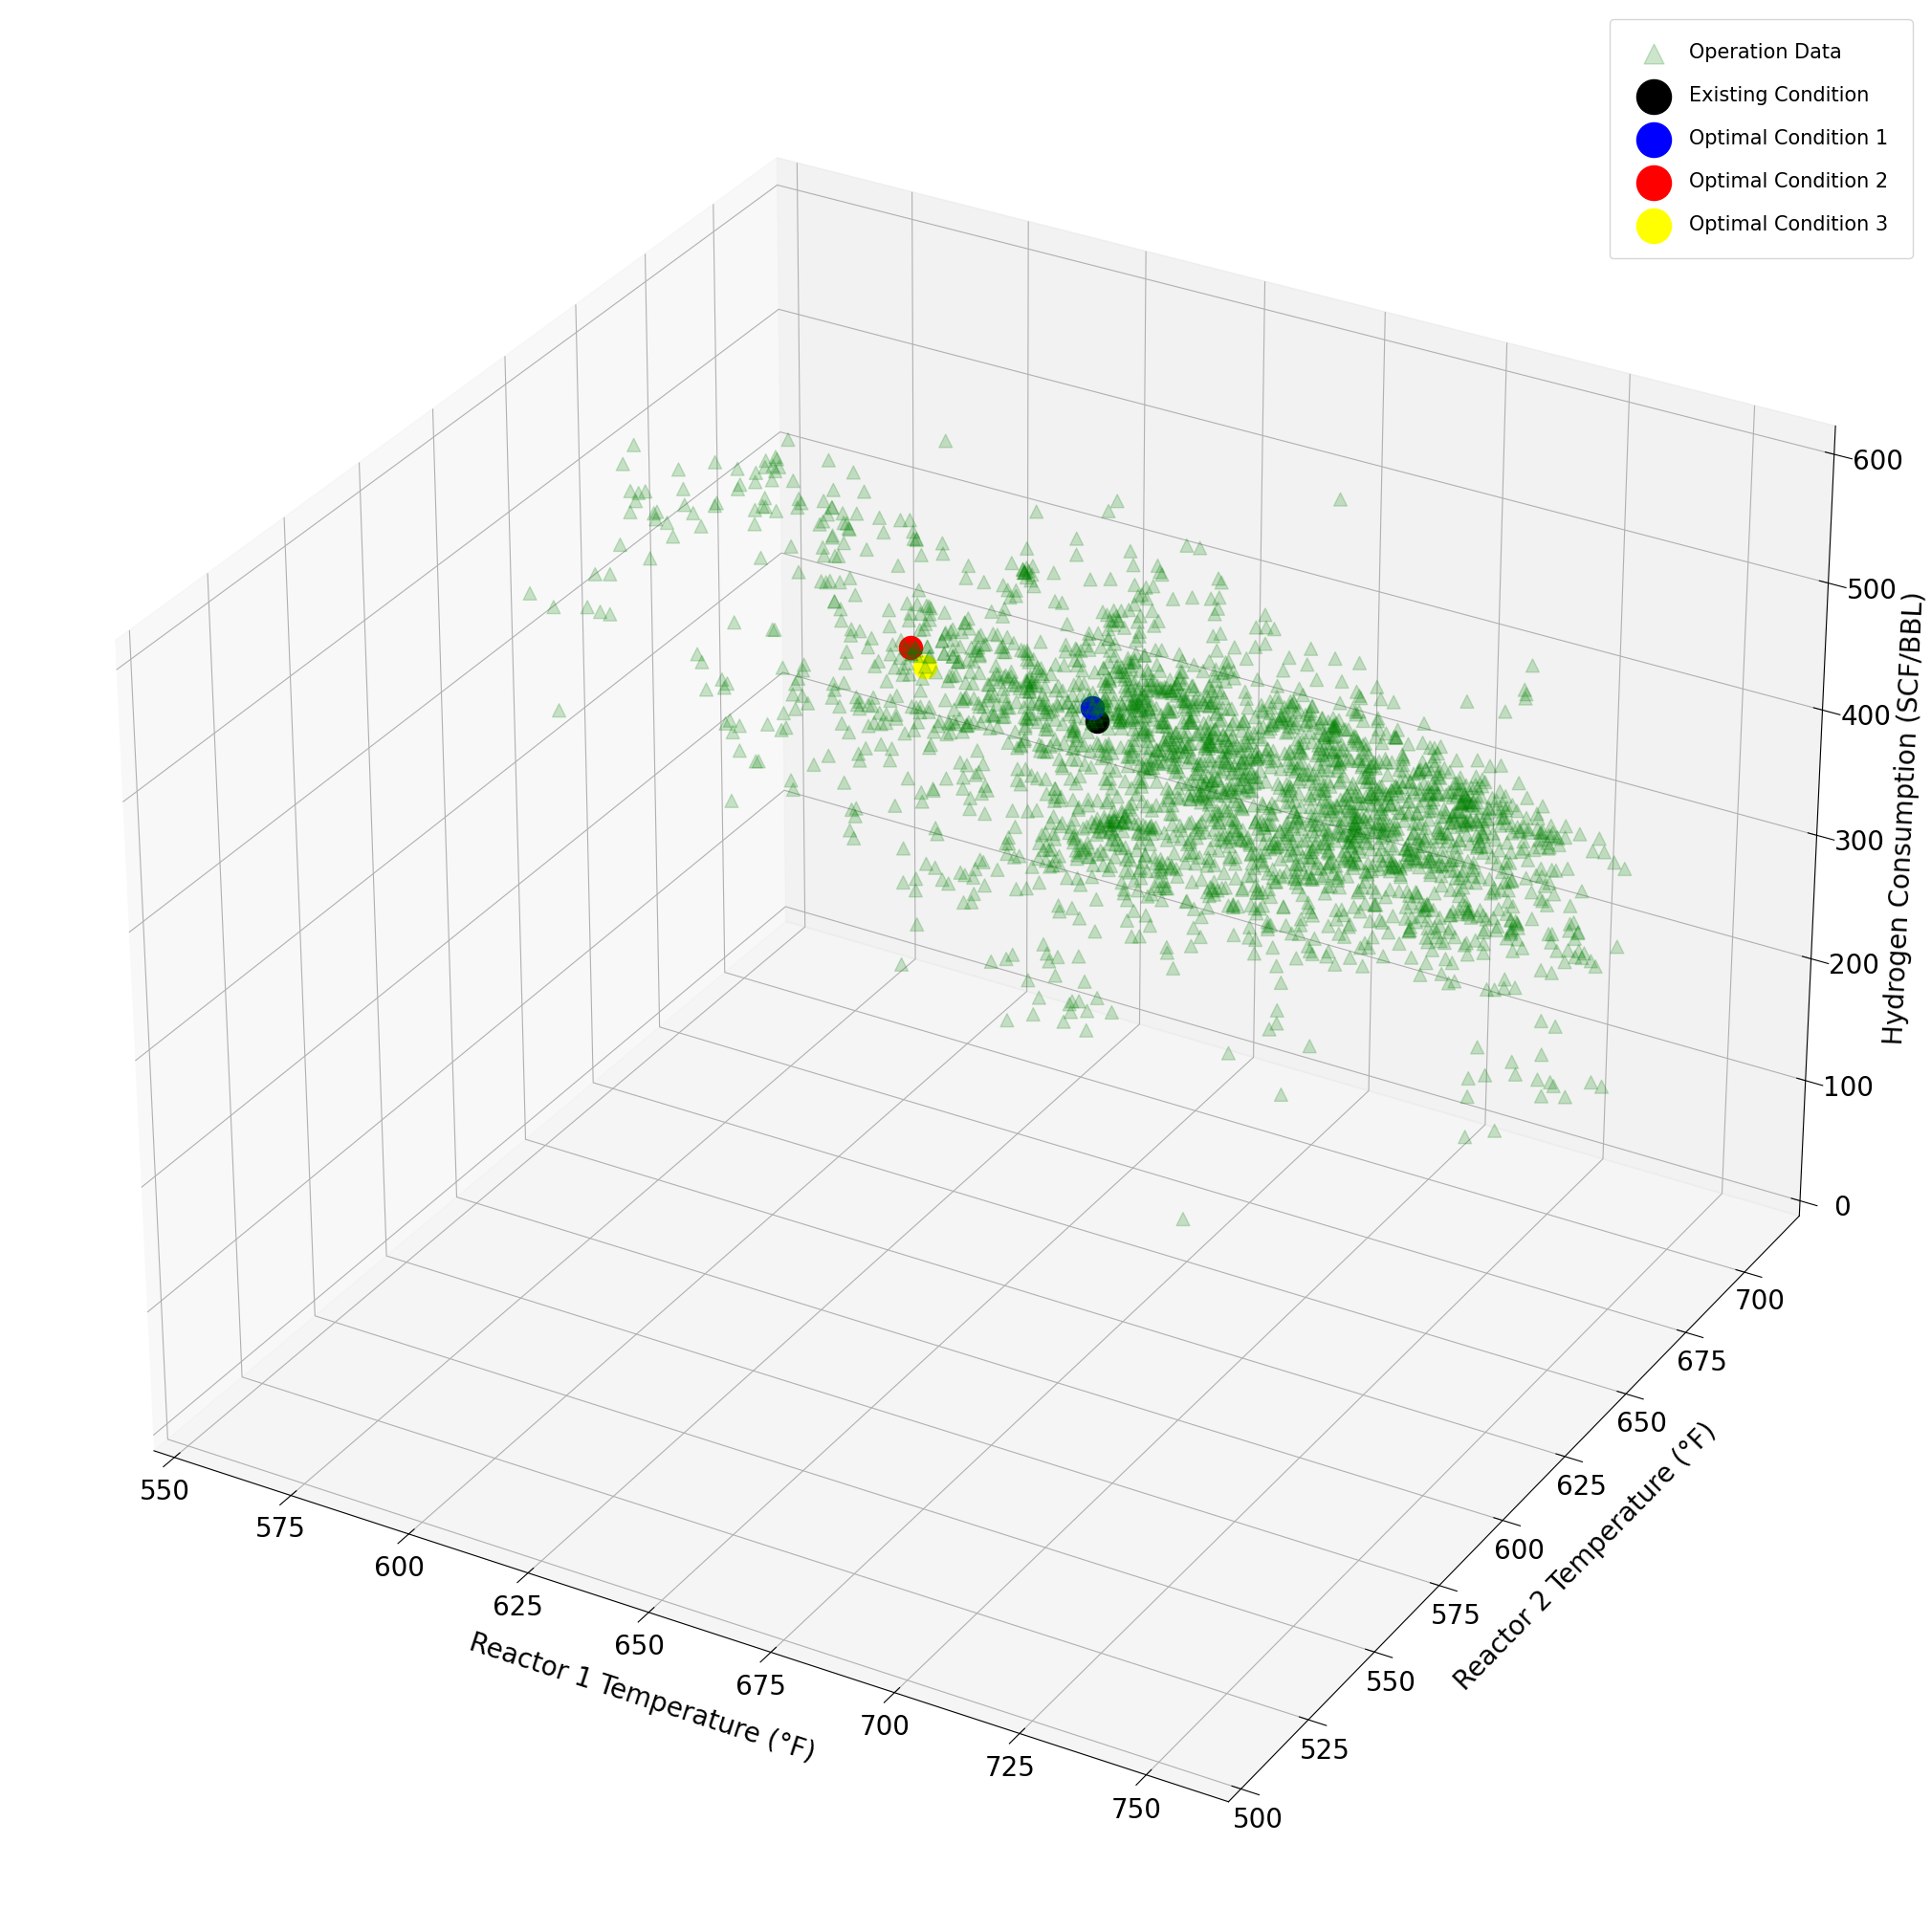

In [116]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming result_input and mode1filled contain the DataFrame with the values
# Create a 3D figure
fig = plt.figure(figsize=(10, 8))  # Adjusted figure size for better visualization
ax = fig.add_subplot(111, projection='3d')

# Extract the values for each axis from result_input
x1 = result_input.iloc[:, 18]
y1 = result_input.iloc[:, 19]
z1 = result_input.iloc[:, 20]

# Extract the values for each axis from mode1filled
x2 = mode2_clean['reactor 1 temperature (°F)']
y2 = mode2_clean['reactor 2 temperature (°F)']
z2 = mode2_clean['Hydrogen Consumption (SCF/BBL)']

# Ensure the data for the specific instance in X is correctly indexed
x3 = X[50][18]
y3 = X[50][19]
z3 = X[50][20]

# Extract optimal points (Replace indices with actual values as needed)
optimal_points = [
    (X[48][18], X[48][19], X[48][20]),  # Optimal Point 1
    (X[9][18], X[9][19], X[9][20]),     # Optimal Point 2
    (X[7][18], X[7][19], X[7][20]),     # Optimal Point 3
]

# Colors and labels for optimal points
optimal_colors = ['blue', 'red', 'yellow']
optimal_labels = ['Optimal Condition 1', 'Optimal Condition 2', 'Optimal Condition 3']

# Plot the 3D scatter plot for mode1filled data
ax.scatter(x2, y2, z2, c='green', marker='^', s=100, alpha=0.2, label='Operation Data')

# Plot the 3D scatter plot for result_input data
#ax.scatter(x1, y1, z1, c='orange', marker='s', s=100, label='Optimal Conditions')

# Plot the specific instance from X
ax.scatter(x3, y3, z3, c='k', marker='o', s=300, label='Existing Condition')  # Increased size for better visibility

# Plot optimal points
for i, (opt_point, color, label) in enumerate(zip(optimal_points, optimal_colors, optimal_labels)):
    ax.scatter(opt_point[0], opt_point[1], opt_point[2], c=color, marker='o', s=300, label=label)

# Set labels and title
ax.set_xlabel('Reactor 1 Temperature (°F)' , fontsize=20, labelpad=20)
ax.set_ylabel('Reactor 2 Temperature (°F)', fontsize=20, labelpad=20)
ax.set_zlabel('Hydrogen Consumption (SCF/BBL)', fontsize=20, labelpad=20)
#ax.set_title('Optimal Operation Conditions', fontsize=20)

# Set axis limits to start from zero
ax.set_xlim(left=550)
ax.set_ylim(bottom=500)
ax.set_zlim(bottom=0)

# Add a legend with a larger font size
ax.legend(fontsize=15, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.5, right=20, top=3, bottom=0.5)

# Make the tick labels bold
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='z', labelsize=20)
ax.tick_params(axis='z', pad=12)

# Set initial viewing angle
#ax.view_init(elev=30, azim=135)  # Adjust elevation and azimuth for different point of view


# Show the plot
plt.show()


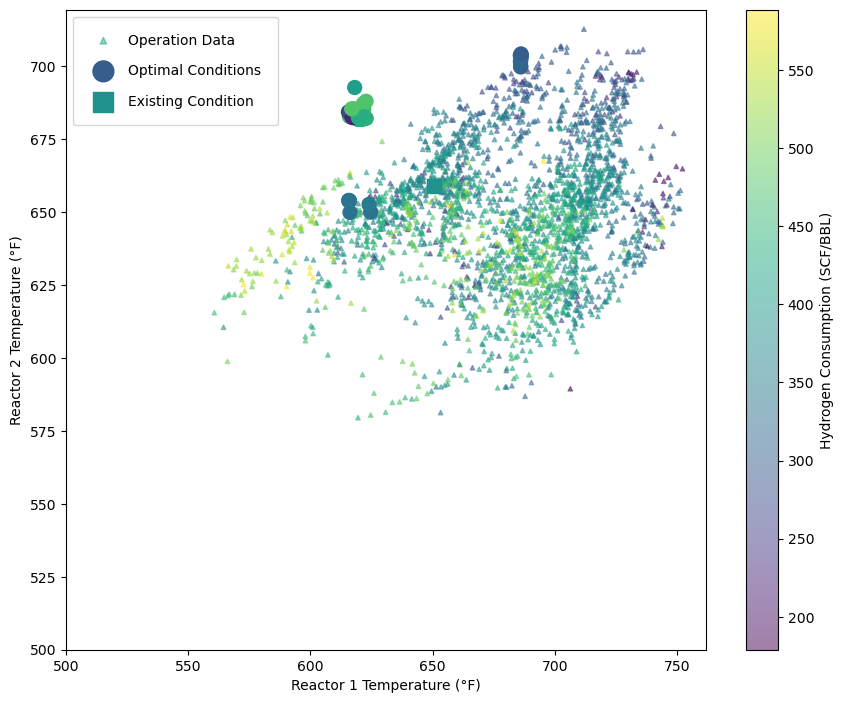

In [114]:
import matplotlib.pyplot as plt

# Assuming result_input and mode1filled contain the DataFrame with the values
# Create a 2D figure
fig, ax = plt.subplots(figsize=(10, 8))  # Adjusted figure size for better visualization

# Extract the values for each axis from result_input
x1 = result_input.iloc[:, 18]
y1 = result_input.iloc[:, 19]
z1 = result_input.iloc[:, 20]

# Extract the values for each axis from mode1filled
x2 = mode2_clean['reactor 1 temperature (°F)']
y2 = mode2_clean['reactor 2 temperature (°F)']
z2 = mode2_clean['Hydrogen Consumption (SCF/BBL)']

# Ensure the data for the specific instance in X is correctly indexed
x3 = X[50][18]
y3 = X[50][19]
z3 = X[50][20]

# Normalize colors
norm = plt.Normalize(vmin=min(z1.min(), z2.min(), z3), vmax=max(z1.max(), z2.max(), z3))

# Plot the scatter plot for mode1filled data with color representing total Hydrogen out
sc = ax.scatter(x2, y2, c=z2, cmap='viridis', marker='^', s=10, label='Operation Data', alpha=0.5, norm=norm)

# Plot the scatter plot for result_input data
ax.scatter(x1, y1, c=z1, cmap='viridis', marker='o', s=100, label='Optimal Conditions', norm=norm)

# Plot the specific instance from X
ax.scatter([x3], [y3], c=[z3], cmap='viridis', marker='s', s=100, label='Existing Condition', norm=norm)  # Increased size

# Set labels and title
ax.set_xlabel('Reactor 1 Temperature (°F)', fontsize=10)
ax.set_ylabel('Reactor 2 Temperature (°F)', fontsize=10)
#ax.set_title('Optimal Operation Conditions', fontsize=10)

# Set axis limits to start from specific values
ax.set_xlim(left=500)
ax.set_ylim(bottom=500)

# Add a color bar to represent the Hydrogen out values
cbar = plt.colorbar(sc)
cbar.set_label('Hydrogen Consumption (SCF/BBL)', fontsize=10)

# Add a legend with a larger font size
ax.legend(fontsize=10, markerscale=1.5, borderpad=1.2, labelspacing=1.2)

# Adjust layout to ensure labels are fully visible
plt.tight_layout()

# Manually adjust margins if needed
plt.gcf().subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Show the plot
plt.show()
